<a href="https://colab.research.google.com/github/CopeliaMinutti94/Katachi-MaNGA-Multimodal/blob/luz%2Fmorfologia-color/notebooks/Katachi_Masa_Morfologia_Color_Analisis_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento: incorporación de morfología y color (g-i) para la predicción de masa estelar

## Paso 1. Carga e inspección inicial del catálogo de morfología y color

### ¿Qué se hace?

En este paso se carga el archivo `color_morp.csv`, que contiene información adicional de las galaxias de la muestra de MaNGA.

La tabla incluye, entre otras variables:

- `MANGAID`: identificador único de cada galaxia en MaNGA.
- `T_11`: clasificación morfológica numérica de la galaxia.
- `g_i`: color fotométrico de la galaxia, calculado a partir de las bandas `g` e `i`.

En esta primera etapa únicamente se carga la tabla y se revisan sus dimensiones, nombres de columnas y primeras filas.

### ¿Por qué se hace?

Antes de utilizar estos datos como información adicional para una red neuronal, es necesario comprobar cómo está estructurado el catálogo y verificar qué variables contiene realmente.

Esto permite detectar desde el inicio posibles problemas como:

- valores faltantes;
- nombres de columnas diferentes a los esperados;
- valores fuera de rango;
- identificadores incorrectos o duplicados.

### ¿Para qué se hace?

El objetivo posterior será evaluar si proporcionar explícitamente a Katachi información sobre la **morfología** y el **color (g-i)** de cada galaxia puede mejorar la predicción de su **masa estelar**.

La comparación se realizará posteriormente contra el modelo original de Katachi, que servirá como referencia o *baseline*.

En este punto todavía no se modifica ni se entrena ninguna red neuronal.

### ¿Cómo se hace?

El archivo `color_morp.csv` se carga como un `DataFrame` de Pandas. Después se inspeccionan:

1. El número de filas y columnas.
2. Los nombres de las variables disponibles.
3. Las primeras galaxias del catálogo.

No se realiza todavía ninguna limpieza, filtrado ni transformación de los datos.

In [1]:
import pandas as pd
from google.colab import files

# Subir el archivo que compartió el Dr.
uploaded = files.upload()

# Leer la tabla
color_morp = pd.read_csv("color_morp.csv")

print("Archivo cargado correctamente")
print("Dimensiones:", color_morp.shape)

print("\nColumnas:")
print(color_morp.columns.tolist())

print("\nPrimeras 5 filas:")
display(color_morp.head())

Saving color_morp.csv to color_morp.csv
Archivo cargado correctamente
Dimensiones: (10126, 4)

Columnas:
['name', 'MANGAID', 'T_11', 'g_i']

Primeras 5 filas:


,name,MANGAID,T_11,g_i
0,manga-10001-12701,1-48157,4,0.404967
1,manga-10001-12702,1-48188,4,0.644865
2,manga-10001-12703,1-55648,4,0.710236
3,manga-10001-12704,1-55616,7,0.766408
4,manga-10001-12705,1-55784,4,0.574194


## Paso 2. Revisión de calidad de las variables de morfología y color

### ¿Qué se hace?

En este paso se realiza una inspección de calidad del catálogo antes de utilizar sus variables en el modelo.

Se revisan específicamente:

- el tipo de dato de cada columna;
- la existencia de valores faltantes;
- posibles `MANGAID` duplicados;
- los valores disponibles de la variable morfológica `T_11`;
- la distribución básica del color `g_i`;
- cuántas galaxias presentan un valor de `g_i > 2`.

### ¿Por qué se hace?

Antes de incorporar nuevas variables a una red neuronal es necesario verificar que los datos sean consistentes.

En particular, se indicó que los valores de color `g_i` mayores a 2 no deben considerarse físicamente válidos para este análisis. Por ello, primero se debe cuantificar cuántos objetos presentan este problema antes de decidir cómo tratarlos.

También es necesario comprobar que el identificador `MANGAID` pueda utilizarse posteriormente para realizar el cruce con las galaxias empleadas por Katachi.

### ¿Para qué se hace?

Esta revisión permitirá definir posteriormente una muestra limpia en la que cada galaxia tenga:

- un identificador MaNGA válido;
- una clasificación morfológica utilizable;
- un valor de color `g_i` válido.

Esto es necesario antes de construir el conjunto de datos que se utilizará para probar si la morfología y el color pueden mejorar la predicción de masa estelar.

### ¿Cómo se hace?

Se utilizan funciones de Pandas para:

1. revisar los tipos de datos;
2. contar valores faltantes;
3. detectar identificadores duplicados;
4. obtener los valores y frecuencias de `T_11`;
5. calcular estadísticas descriptivas de `g_i`;
6. contar específicamente los casos donde `g_i > 2`.

En este paso únicamente se diagnostican los datos.  
Todavía no se elimina ni modifica ninguna galaxia.

In [2]:
# ============================================================
# PASO 2 — REVISIÓN DE CALIDAD DEL CATÁLOGO
# ============================================================

print("=== TIPOS DE DATOS ===")
print(color_morp.dtypes)


print("\n=== VALORES FALTANTES ===")
print(color_morp.isna().sum())


print("\n=== MANGAID DUPLICADOS ===")
print("Número de MANGAID duplicados:",
      color_morp["MANGAID"].duplicated().sum())


print("\n=== VALORES DE T_11 ===")
print("Valores únicos:")
print(sorted(color_morp["T_11"].dropna().unique()))

print("\nNúmero de galaxias por T_11:")
print(color_morp["T_11"].value_counts(dropna=False).sort_index())


print("\n=== ESTADÍSTICAS DE g_i ===")
print(color_morp["g_i"].describe())


print("\n=== REVISIÓN DEL LÍMITE g_i > 2 ===")
print("Galaxias con g_i > 2:",
      (color_morp["g_i"] > 2).sum())

print("Galaxias con g_i <= 2:",
      (color_morp["g_i"] <= 2).sum())

print("Galaxias sin g_i:",
      color_morp["g_i"].isna().sum())

=== TIPOS DE DATOS ===
name        object
MANGAID     object
T_11         int64
g_i        float64
dtype: object

=== VALORES FALTANTES ===
name          0
MANGAID       0
T_11          0
g_i        1309
dtype: int64

=== MANGAID DUPLICADOS ===
Número de MANGAID duplicados: 0

=== VALORES DE T_11 ===
Valores únicos:
[np.int64(-5), np.int64(-2), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

Número de galaxias por T_11:
T_11
-5     1809
-2     1317
 0      615
 1     1085
 2     1051
 3     1126
 4     1034
 5     1026
 6      462
 7      352
 8       79
 9       84
 10      19
 11      67
Name: count, dtype: int64

=== ESTADÍSTICAS DE g_i ===
count    8817.000000
mean        5.394989
std        89.517869
min        -0.908513
25%         0.577530
50%         0.833678
75%         0.989281
max      2099.753250
Name: g_i, dtype: float64

=== REVISIÓN DEL LÍMITE g_i > 2 ===
Galaxi

## Paso 3. Definición de los grupos morfológicos y validación del color

### ¿Qué se hace?

En este paso se crean variables auxiliares a partir de la información original del catálogo.

Para la morfología se utilizará la división propuesta para este experimento:

- **Tempranas:** valores de `T_11` entre -5 y 0.
- **Tardías:** valores de `T_11` entre 1 y 10.
- Los objetos con `T_11 = 11` se conservarán en el catálogo, pero no se asignarán a ninguno de los dos grupos en esta primera prueba.

Para el color `g_i`, se marcarán como válidos únicamente los valores disponibles que cumplan `g_i <= 2`, siguiendo la indicación proporcionada para esta muestra.

### ¿Por qué se hace?

La clasificación morfológica original contiene varios tipos de galaxias. Para realizar una primera prueba controlada, se simplifica esta información a dos grandes grupos: tempranas y tardías.

Asimismo, la inspección inicial mostró valores extremos de `g_i` que llegan hasta valores muy superiores a 2, además de valores faltantes. Estos datos no deben incorporarse directamente al modelo sin identificarlos previamente.

### ¿Para qué se hace?

El objetivo es preparar variables consistentes que posteriormente puedan cruzarse con las galaxias utilizadas por Katachi.

Esto permitirá conocer cuántas galaxias de los conjuntos Train y Test de Katachi disponen simultáneamente de:

1. una clasificación morfológica temprana o tardía;
2. un color `g_i` válido.

Todavía no se elimina ninguna galaxia ni se modifica la arquitectura de la red neuronal.

### ¿Cómo se hace?

Se crearán dos nuevas columnas:

- `grupo_morfologico`: con las etiquetas `Temprana`, `Tardia` o `No_clasificada`.
- `gi_valido`: variable booleana que será `True` cuando exista un valor de `g_i` y este sea menor o igual a 2.

Las columnas originales `T_11` y `g_i` se conservarán sin modificaciones.

In [3]:
# ============================================================
# PASO 3 — CREAR GRUPOS MORFOLÓGICOS Y BANDERA DE COLOR VÁLIDO
# ============================================================

import numpy as np

# Trabajamos sobre una copia para conservar intacto el catálogo original
color_morp_preparado = color_morp.copy()


# ------------------------------------------------------------
# 1. Crear grupo morfológico
# ------------------------------------------------------------

color_morp_preparado["grupo_morfologico"] = np.select(
    [
        color_morp_preparado["T_11"].between(-5, 0),
        color_morp_preparado["T_11"].between(1, 10)
    ],
    [
        "Temprana",
        "Tardia"
    ],
    default="No_clasificada"
)


# ------------------------------------------------------------
# 2. Crear indicador de color g-i válido
# ------------------------------------------------------------

color_morp_preparado["gi_valido"] = (
    color_morp_preparado["g_i"].notna()
    & (color_morp_preparado["g_i"] <= 2)
)


# ------------------------------------------------------------
# 3. Revisar resultados
# ------------------------------------------------------------

print("=== GRUPOS MORFOLÓGICOS ===")
print(color_morp_preparado["grupo_morfologico"].value_counts())


print("\n=== COLOR g-i ===")
print(color_morp_preparado["gi_valido"].value_counts())


print("\n=== COMBINACIÓN MORFOLOGÍA + COLOR ===")

condicion_completa = (
    color_morp_preparado["grupo_morfologico"].isin(["Temprana", "Tardia"])
    & color_morp_preparado["gi_valido"]
)

print(
    "Galaxias con morfología temprana/tardía Y g-i válido:",
    condicion_completa.sum()
)

print(
    "Galaxias que no cumplen ambas condiciones:",
    (~condicion_completa).sum()
)


print("\nPrimeras filas:")
display(
    color_morp_preparado[
        ["MANGAID", "T_11", "grupo_morfologico", "g_i", "gi_valido"]
    ].head(10)
)

=== GRUPOS MORFOLÓGICOS ===
grupo_morfologico
Tardia            6318
Temprana          3741
No_clasificada      67
Name: count, dtype: int64

=== COLOR g-i ===
gi_valido
True     8653
False    1473
Name: count, dtype: int64

=== COMBINACIÓN MORFOLOGÍA + COLOR ===
Galaxias con morfología temprana/tardía Y g-i válido: 8607
Galaxias que no cumplen ambas condiciones: 1519

Primeras filas:


,MANGAID,T_11,grupo_morfologico,g_i,gi_valido
0,1-48157,4,Tardia,0.404967,True
1,1-48188,4,Tardia,0.644865,True
2,1-55648,4,Tardia,0.710236,True
3,1-55616,7,Tardia,0.766408,True
4,1-55784,4,Tardia,0.574194,True
5,1-55567,4,Tardia,0.792386,True
6,1-48201,-2,Temprana,1.076391,True
7,1-48111,-2,Temprana,0.861452,True
8,1-48136,-5,Temprana,0.536094,True
9,1-55612,3,Tardia,0.583124,True


## Paso 4. Recuperación de la muestra utilizada por Katachi

### ¿Qué se hace?

En este paso se carga el catálogo `scalars.cat` del repositorio original de Katachi.

Este catálogo contiene información sobre las galaxias consideradas por el proyecto, incluyendo la variable `split`, que permite identificar cuáles objetos fueron utilizados en los conjuntos:

- `Train`: entrenamiento.
- `Test`: prueba.
- `None`: objetos que no fueron asignados a ninguno de los dos conjuntos.

Se seleccionarán únicamente las galaxias pertenecientes a `Train` o `Test`.

### ¿Por qué se hace?

El catálogo de morfología y color contiene 10,126 galaxias, pero Katachi no utiliza todas ellas.

Para realizar un experimento comparable con el modelo original, es necesario trabajar exactamente con la muestra utilizada por Katachi y conservar la división original entre entrenamiento y prueba.

Modificar esta división podría producir una comparación injusta con el modelo de referencia.

### ¿Para qué se hace?

El objetivo es recuperar los identificadores `MANGAID` de las 9,904 galaxias utilizadas por Katachi y su correspondiente asignación a `Train` o `Test`.

Posteriormente, estos identificadores se utilizarán para cruzar la muestra de Katachi con el catálogo de morfología y color.

### ¿Cómo se hace?

1. Se obtiene el repositorio de Katachi.
2. Se instala la librería `hickle`, utilizada para leer `scalars.cat`.
3. Se carga el catálogo como un DataFrame de Pandas.
4. Se revisa la columna `split`.
5. Se seleccionan únicamente los objetos con `split = Train` o `split = Test`.

En este paso todavía no se realiza el cruce con `color_morp.csv`.

In [5]:
import os

print(os.listdir("/content"))

['.config', 'color_morp.csv', 'sample_data']


In [6]:
!git clone https://github.com/juanpabloalfonzo/Katachi.git

Cloning into 'Katachi'...
fatal: could not read Username for 'https://github.com': No such device or address
fatal: expected flush after ref listing


In [7]:
import os

print(os.listdir("/content/Katachi"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/Katachi'

In [8]:
!git clone https://github.com/juanpabloalfonzo/Katachi.git

Cloning into 'Katachi'...
fatal: could not read Username for 'https://github.com': No such device or address
fatal: expected flush after ref listing


In [10]:
!wget -q https://github.com/juanpabloalfonzo/Katachi/archive/refs/heads/main.zip -O /content/katachi.zip
!unzip -q /content/katachi.zip -d /content
!mv /content/Katachi-main /content/Katachi

In [11]:
import os
print(os.listdir("/content"))

['.config', 'katachi.zip', 'Katachi', 'color_morp.csv', 'sample_data']


In [9]:
import os
print(os.listdir("/content"))

['.config', 'color_morp.csv', 'sample_data']


In [12]:
import os

ruta_catalogos = "/content/Katachi/Catalogues"

print("Contenido actual de Catalogues:")
for archivo in os.listdir(ruta_catalogos):
    print(archivo)

Contenido actual de Catalogues:
place_holder.txt


### Paso 4A. Identificación del procedimiento oficial para descargar los archivos grandes de Katachi

#### ¿Qué se hace?

El repositorio recién clonado no contiene directamente el archivo `scalars.cat`. En la carpeta `Catalogues` únicamente aparece `place_holder.txt`.

Sin embargo, el repositorio de Katachi incluye el notebook `get_large_files.ipynb`, destinado a obtener los archivos de gran tamaño que no se descargan con un `git clone` normal.

#### ¿Por qué se hace?

`scalars.cat` es necesario para recuperar la muestra original de galaxias utilizada por Katachi y su división Train/Test.

Antes de descargar archivos externos, se revisará el procedimiento proporcionado por los propios autores del repositorio, evitando asumir rutas o enlaces.

#### ¿Para qué se hace?

El objetivo es obtener `scalars.cat` de la misma fuente utilizada por Katachi y continuar posteriormente con el cruce entre:

- las galaxias utilizadas por Katachi;
- la morfología;
- el color `g-i`.

#### ¿Cómo se hace?

Se leerán las celdas de código de `get_large_files.ipynb` para identificar qué comando utilizan los autores para descargar los archivos grandes.

En esta etapa todavía no se realiza ninguna descarga.

In [14]:
import json

ruta_notebook = "/content/Katachi/get_large_files.ipynb"

with open(ruta_notebook, "r", encoding="utf-8") as f:
    nb = json.load(f)

print("=== CELDAS DE CÓDIGO DE get_large_files.ipynb ===\n")

for i, celda in enumerate(nb["cells"]):
    if celda["cell_type"] == "code":
        codigo = "".join(celda["source"])
        print(f"\n--- CELDA {i} ---")
        print(codigo)

=== CELDAS DE CÓDIGO DE get_large_files.ipynb ===


--- CELDA 1 ---
import os 
import wget

--- CELDA 2 ---
work_dir = 'PUT DIRECTORY OF KATACHI FOLDER HERE'
work_dir1 = work_dir+'\Catalogues'

def download_with_wget(url, destination_directory, filename):
    try:
        full_path = f"{destination_directory}/{filename}"
        wget.download(url, out=full_path)
        print(f"Downloaded file saved as: {full_path}")
    except Exception as e:
        print(f"An error occurred: {e}")


#Downloading full data catalogues generated for this work 
manga_scalars = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/scalars.cat',work_dir1, 'scalars')
manga_images = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/images.cat',work_dir1, 'images')
manga_shap_maps_mass = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/shap_mass.cat',work_dir1, 'shap_mass')
manga_shap

### Paso 4B. Descarga del catálogo `scalars.cat` de Katachi

#### ¿Qué se hace?

Se descarga el archivo `scalars.cat`, que contiene el catálogo principal utilizado por Katachi.

El archivo se obtiene desde la dirección indicada por los propios autores en el notebook `get_large_files.ipynb` incluido en el repositorio oficial.

#### ¿Por qué se hace?

El archivo `scalars.cat` no está incluido directamente cuando se clona el repositorio de GitHub debido a su tamaño.

Sin este catálogo no es posible recuperar de manera completa la muestra utilizada por Katachi ni identificar correctamente la división original entre `Train` y `Test`.

#### ¿Para qué se hace?

Este catálogo permitirá identificar las 9,904 galaxias utilizadas por Katachi y posteriormente cruzarlas mediante `MANGAID` con el archivo de morfología y color proporcionado para el nuevo experimento.

#### ¿Cómo se hace?

Se descarga directamente el archivo `scalars.cat` desde el servidor utilizado por los autores de Katachi y se guarda dentro de:

`/content/Katachi/Catalogues/scalars.cat`

En este paso solamente se descarga y verifica el archivo. Todavía no se realiza ningún cruce de datos.

In [15]:
# ============================================================
# PASO 4B — DESCARGAR scalars.cat
# ============================================================

import os

url_scalars = (
    "https://www.astr.tohoku.ac.jp/"
    "~juanpabloalfonzo/Katachi_MaNGA_Catalogues/scalars.cat"
)

ruta_scalars = "/content/Katachi/Catalogues/scalars.cat"

# Descargar solamente si todavía no existe
if not os.path.exists(ruta_scalars):
    !wget -q "$url_scalars" -O "$ruta_scalars"
    print("scalars.cat descargado.")
else:
    print("scalars.cat ya existe.")

# Verificación
print("\n¿Existe el archivo?:", os.path.exists(ruta_scalars))

if os.path.exists(ruta_scalars):
    tam_mb = os.path.getsize(ruta_scalars) / (1024**2)
    print(f"Tamaño: {tam_mb:.2f} MB")
    print("Ruta:", ruta_scalars)

scalars.cat descargado.

¿Existe el archivo?: True
Tamaño: 153.52 MB
Ruta: /content/Katachi/Catalogues/scalars.cat


### Paso 4C. Carga de `scalars.cat` y recuperación de la muestra original de Katachi

#### ¿Qué se hace?

Se carga el catálogo `scalars.cat` descargado desde la fuente indicada por los autores de Katachi.

Después se utiliza la columna `split` para identificar qué galaxias pertenecen a los conjuntos originales:

- `Train`: galaxias utilizadas para entrenamiento.
- `Test`: galaxias utilizadas para evaluación.
- `None`: objetos presentes en el catálogo pero no asignados a ninguno de estos dos conjuntos.

#### ¿Por qué se hace?

El nuevo experimento debe partir de la misma muestra y conservar la división Train/Test utilizada originalmente por Katachi.

Esto es necesario para que posteriormente la comparación entre el modelo original y el modelo con información adicional de morfología y color sea consistente.

#### ¿Para qué se hace?

El objetivo es obtener una tabla con los `MANGAID` de las galaxias efectivamente utilizadas por Katachi y su correspondiente `split`.

Esta tabla servirá en el siguiente paso para realizar el cruce con el catálogo `color_morp.csv`.

#### ¿Cómo se hace?

1. Se carga `scalars.cat` mediante la librería `hickle`.
2. Se inspecciona la distribución de la columna `split`.
3. Se seleccionan únicamente los objetos con `split = Train` o `split = Test`.
4. Se conservan `MANGAID` y `split`.
5. Se comprueba que no existan identificadores faltantes o duplicados.

In [17]:
!pip install -q hickle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 8.7 MB/s eta 0:00:00


In [18]:
# ============================================================
# PASO 4C — CARGAR scalars.cat Y RECUPERAR TRAIN / TEST
# ============================================================

import hickle
import pandas as pd

ruta_scalars = "/content/Katachi/Catalogues/scalars.cat"

# ------------------------------------------------------------
# 1. Cargar catálogo
# ------------------------------------------------------------

scalars = hickle.load(ruta_scalars)

print("scalars.cat cargado correctamente")
print("Dimensiones completas:", scalars.shape)


# ------------------------------------------------------------
# 2. Revisar la división original
# ------------------------------------------------------------

print("\n=== DISTRIBUCIÓN DE split ===")
print(scalars["split"].value_counts(dropna=False))


# ------------------------------------------------------------
# 3. Recuperar únicamente las galaxias usadas por Katachi
# ------------------------------------------------------------

katachi_muestra = (
    scalars[
        scalars["split"].isin(["Train", "Test"])
    ][["mangaid", "split"]]
    .rename(columns={"mangaid": "MANGAID"})
    .copy()
)

katachi_muestra["MANGAID"] = (
    katachi_muestra["MANGAID"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 4. Validaciones
# ------------------------------------------------------------

print("\n=== MUESTRA UTILIZADA POR KATACHI ===")

print("Total:", len(katachi_muestra))

print("\nDistribución Train/Test:")
print(katachi_muestra["split"].value_counts())

print("\nMANGAID faltantes:",
      katachi_muestra["MANGAID"].isna().sum())

print("MANGAID duplicados:",
      katachi_muestra["MANGAID"].duplicated().sum())

print("\nPrimeras filas:")
display(katachi_muestra.head())

scalars.cat cargado correctamente
Dimensiones completas: (10081, 30)

=== DISTRIBUCIÓN DE split ===
split
Train    8914
Test      990
None      177
Name: count, dtype: int64

=== MUESTRA UTILIZADA POR KATACHI ===
Total: 9904

Distribución Train/Test:
split
Train    8914
Test      990
Name: count, dtype: int64

MANGAID faltantes: 0
MANGAID duplicados: 0

Primeras filas:


,MANGAID,split
0,1-1009,Train
1,1-10166,Train
2,1-10177,Train
3,1-10263,Train
4,1-1033,Train


## Paso 5. Cruce de la muestra de Katachi con el catálogo de morfología y color

### ¿Qué se hace?

Se unen dos tablas utilizando `MANGAID` como identificador común:

1. La muestra original utilizada por Katachi:
   - 8,914 galaxias de Train.
   - 990 galaxias de Test.
   - 9,904 galaxias en total.

2. El catálogo `color_morp.csv`, que contiene:
   - `T_11`: clasificación morfológica.
   - `g_i`: color fotométrico.
   - `grupo_morfologico`: clasificación simplificada en temprana o tardía.
   - `gi_valido`: indicador de si el valor de color puede utilizarse.

### ¿Por qué se hace?

El catálogo de morfología y color contiene más galaxias que las utilizadas por Katachi.

Para realizar un experimento comparable con el modelo original, es necesario saber cuáles de las galaxias de Train y Test de Katachi tienen también información de morfología y color.

### ¿Para qué se hace?

El objetivo es determinar el tamaño real de la muestra disponible para probar posteriormente si agregar morfología y color `g-i` mejora la predicción de masa estelar.

También se quiere conocer por separado cuántas galaxias válidas quedan en Train y cuántas en Test.

### ¿Cómo se hace?

Se realiza un `merge` utilizando `MANGAID`.

Se conservan inicialmente las 9,904 galaxias de Katachi, aunque alguna no tenga correspondencia o no tenga datos adicionales válidos.

Después se cuantifica:

1. cuántas aparecen en `color_morp.csv`;
2. cuántas tienen morfología temprana o tardía;
3. cuántas tienen `g_i` válido;
4. cuántas cumplen ambas condiciones;
5. cómo se distribuyen entre Train y Test.

En este paso todavía no se elimina ninguna galaxia ni se modifica la red neuronal.

In [20]:
# ============================================================
# PASO 5 — CRUCE KATACHI + MORFOLOGÍA + COLOR
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Normalizar MANGAID en ambas tablas
# ------------------------------------------------------------

color_morp_preparado["MANGAID"] = (
    color_morp_preparado["MANGAID"]
    .astype(str)
    .str.strip()
)

katachi_muestra["MANGAID"] = (
    katachi_muestra["MANGAID"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 2. Cruzar las 9904 galaxias de Katachi con color_morp
# ------------------------------------------------------------

katachi_morf_color = katachi_muestra.merge(
    color_morp_preparado[
        [
            "MANGAID",
            "T_11",
            "g_i",
            "grupo_morfologico",
            "gi_valido"
        ]
    ],
    on="MANGAID",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 3. Identificar si la galaxia fue encontrada en color_morp
# ------------------------------------------------------------

katachi_morf_color["en_color_morp"] = (
    katachi_morf_color["T_11"].notna()
)


# ------------------------------------------------------------
# 4. Identificar si la morfología puede usarse
# ------------------------------------------------------------

katachi_morf_color["morfologia_valida"] = (
    katachi_morf_color["grupo_morfologico"]
    .isin(["Temprana", "Tardia"])
)


# ------------------------------------------------------------
# 5. Identificar si tiene ambas variables válidas
# ------------------------------------------------------------

katachi_morf_color["datos_extra_validos"] = (
    katachi_morf_color["morfologia_valida"]
    & katachi_morf_color["gi_valido"].fillna(False)
)


# ------------------------------------------------------------
# 6. Resumen general
# ------------------------------------------------------------

print("=== CRUCE GENERAL ===")

print(
    "Galaxias originales de Katachi:",
    len(katachi_morf_color)
)

print(
    "Encontradas en color_morp.csv:",
    katachi_morf_color["en_color_morp"].sum()
)

print(
    "No encontradas en color_morp.csv:",
    (~katachi_morf_color["en_color_morp"]).sum()
)


print("\n=== DISPONIBILIDAD DE VARIABLES ===")

print(
    "Con morfología temprana/tardía válida:",
    katachi_morf_color["morfologia_valida"].sum()
)

print(
    "Con g-i válido:",
    katachi_morf_color["gi_valido"].fillna(False).sum()
)

print(
    "Con morfología válida Y g-i válido:",
    katachi_morf_color["datos_extra_validos"].sum()
)


# ------------------------------------------------------------
# 7. Resumen por Train y Test
# ------------------------------------------------------------

print("\n=== POR SPLIT ===")

resumen_split = (
    katachi_morf_color
    .groupby("split")
    .agg(
        total=("MANGAID", "size"),
        encontradas=("en_color_morp", "sum"),
        morfologia_valida=("morfologia_valida", "sum"),
        gi_valido=("gi_valido", "sum"),
        ambas_validas=("datos_extra_validos", "sum")
    )
)

display(resumen_split)


# ------------------------------------------------------------
# 8. Distribución morfológica
# ------------------------------------------------------------

print("\n=== GRUPOS MORFOLÓGICOS EN KATACHI ===")

print(
    katachi_morf_color["grupo_morfologico"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 9. Primeras filas
# ------------------------------------------------------------

print("\n=== PRIMERAS FILAS DEL CRUCE ===")

display(
    katachi_morf_color[
        [
            "MANGAID",
            "split",
            "T_11",
            "grupo_morfologico",
            "g_i",
            "gi_valido",
            "datos_extra_validos"
        ]
    ].head(10)
)

=== CRUCE GENERAL ===
Galaxias originales de Katachi: 9904
Encontradas en color_morp.csv: 9897
No encontradas en color_morp.csv: 7

=== DISPONIBILIDAD DE VARIABLES ===
Con morfología temprana/tardía válida: 9832
Con g-i válido: 8494
Con morfología válida Y g-i válido: 8449

=== POR SPLIT ===


/tmp/ipykernel_3923/4153892182.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & katachi_morf_color["gi_valido"].fillna(False)
/tmp/ipykernel_3923/4153892182.py:104: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  katachi_morf_color["gi_valido"].fillna(False).sum()


,total,encontradas,morfologia_valida,gi_valido,ambas_validas
split,,,,,
Test,990,989,983,835,832
Train,8914,8908,8849,7659,7617



=== GRUPOS MORFOLÓGICOS EN KATACHI ===
grupo_morfologico
Tardia            6222
Temprana          3610
No_clasificada      65
NaN                  7
Name: count, dtype: int64

=== PRIMERAS FILAS DEL CRUCE ===


,MANGAID,split,T_11,grupo_morfologico,g_i,gi_valido,datos_extra_validos
0,1-1009,Train,2.0,Tardia,0.720922,True,True
1,1-10166,Train,3.0,Tardia,0.704102,True,True
2,1-10177,Train,2.0,Tardia,0.969820,True,True
3,1-10263,Train,6.0,Tardia,0.462298,True,True
4,1-1033,Train,6.0,Tardia,0.643697,True,True
5,1-1037,Train,5.0,Tardia,0.412423,True,True
6,1-10375,Train,0.0,Temprana,0.410159,True,True
7,1-1038,Train,2.0,Tardia,0.960702,True,True
8,1-10425,Train,-5.0,Temprana,0.876415,True,True
9,1-10550,Train,-5.0,Temprana,0.997942,True,True


## Paso 3A. Validación técnica y física preliminar del color `g-i`

### ¿Qué se hace?

Antes de utilizar el color `g-i` como variable de entrada para la red neuronal, se revisa que su almacenamiento y sus valores sean consistentes.

La validación se realiza en dos niveles:

1. **Validación técnica:** comprobar que `g_i` sea una variable numérica y que no contenga valores infinitos o representaciones incorrectas.
2. **Validación física preliminar:** inspeccionar su rango, valores faltantes y valores extremos.

### ¿Por qué se hace?

Que una columna pueda ser leída por Pandas no significa que todos sus valores sean físicamente utilizables.

En este catálogo, `g_i` está almacenado como número de punto flotante (`float64`), pero la inspección inicial mostró valores extremos muy altos.

Además, se indicó explícitamente que para este análisis los valores de `g_i > 2` no deben considerarse válidos.

### ¿Para qué se hace?

El objetivo es evitar que valores faltantes o físicamente no válidos sean utilizados posteriormente como entradas de la red neuronal.

También se busca documentar de forma reproducible qué criterio se utilizó para decidir qué valores de color pueden formar parte del experimento.

### ¿Cómo se hace?

Se comprueba:

- el tipo de dato de `g_i`;
- la existencia de valores infinitos;
- el número de valores faltantes;
- el valor mínimo y máximo;
- percentiles de la distribución;
- número de objetos con `g_i > 2`;
- número de objetos con valores negativos;
- distribución visual mediante un histograma.

En esta etapa no se modifican los valores originales.

=== VALIDACIÓN TÉCNICA ===
Tipo de dato: float64
¿Es columna numérica?: True
Valores faltantes: 1309
Valores infinitos: 0

=== RANGO DE LOS DATOS ===
Mínimo: -0.9085127999197552
Máximo: 2099.7532500074794

Percentiles:
count    8817.000000
mean        5.394989
std        89.517869
min        -0.908513
1%          0.134403
5%          0.318475
25%         0.577530
50%         0.833678
75%         0.989281
95%         1.149161
99%        49.317454
max      2099.753250
Name: g_i, dtype: float64

=== REVISIÓN SEGÚN EL CRITERIO DEL EXPERIMENTO ===
g_i <= 2: 8653
g_i > 2: 164
g_i negativos: 32
g_i faltantes: 1309

=== EJEMPLOS DE VALORES EXTREMOS ===

10 valores más altos:


,MANGAID,T_11,g_i
5896,50-7,-5,2099.75325
5890,50-2,-5,2099.75276
5894,50-8,-5,2099.73904
8474,46-51,0,2099.73316
7200,40-2,3,2099.72973
9445,43-130,5,2099.72434
717,59-4,3,2099.72091
7063,43-22,9,2099.71454
5895,50-6,-2,2099.71356
8557,46-287,-2,2099.68024



10 valores más bajos:


,MANGAID,T_11,g_i
121,1-383825,5,-0.908513
6819,1-118457,11,-0.818517
6295,1-584598,5,-0.441059
3079,1-79,10,-0.313110
240,1-36585,5,-0.302737
6207,1-92057,1,-0.247827
3887,1-37084,3,-0.202825
7294,1-604172,5,-0.147251
3406,1-120019,6,-0.144887
2074,1-325250,11,-0.135682


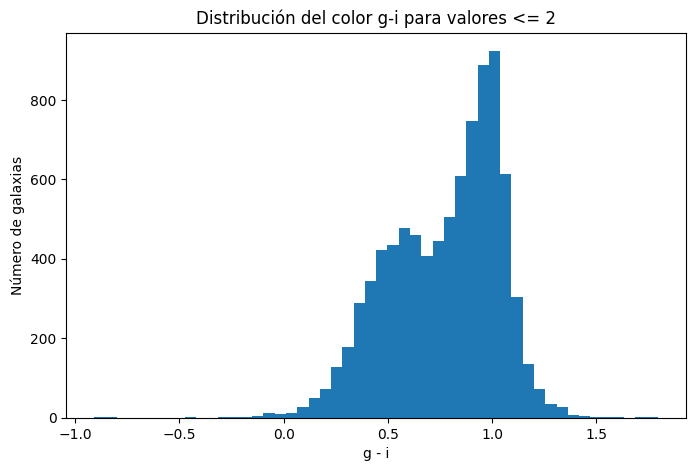

In [21]:
# ============================================================
# PASO 3A — VALIDACIÓN DEL COLOR g-i
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gi = color_morp["g_i"]

print("=== VALIDACIÓN TÉCNICA ===")

print("Tipo de dato:", gi.dtype)
print("¿Es columna numérica?:", pd.api.types.is_numeric_dtype(gi))

print("Valores faltantes:", gi.isna().sum())

print(
    "Valores infinitos:",
    np.isinf(gi.dropna()).sum()
)


print("\n=== RANGO DE LOS DATOS ===")

print("Mínimo:", gi.min())
print("Máximo:", gi.max())

print("\nPercentiles:")
print(
    gi.describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)


print("\n=== REVISIÓN SEGÚN EL CRITERIO DEL EXPERIMENTO ===")

print("g_i <= 2:",
      (gi <= 2).sum())

print("g_i > 2:",
      (gi > 2).sum())

print("g_i negativos:",
      (gi < 0).sum())

print("g_i faltantes:",
      gi.isna().sum())


print("\n=== EJEMPLOS DE VALORES EXTREMOS ===")

print("\n10 valores más altos:")
display(
    color_morp[
        ["MANGAID", "T_11", "g_i"]
    ]
    .sort_values("g_i", ascending=False)
    .head(10)
)

print("\n10 valores más bajos:")
display(
    color_morp[
        ["MANGAID", "T_11", "g_i"]
    ]
    .sort_values("g_i", ascending=True)
    .head(10)
)


# ------------------------------------------------------------
# Histograma usando únicamente el rango que el doctor considera válido
# ------------------------------------------------------------

gi_visual = gi[
    gi.notna()
    & (gi <= 2)
]

plt.figure(figsize=(8, 5))
plt.hist(gi_visual, bins=50)
plt.xlabel("g - i")
plt.ylabel("Número de galaxias")
plt.title("Distribución del color g-i para valores <= 2")
plt.show()

### Conclusión de la validación de `g_i`

La variable `g_i` está almacenada correctamente como una variable numérica (`float64`) y no presenta valores infinitos.

Sin embargo, se identificaron tres situaciones relevantes:

- 1,309 galaxias no tienen un valor disponible de `g_i`.
- 164 galaxias presentan `g_i > 2`, valores que no se consideran válidos para este experimento.
- 32 galaxias presentan valores negativos de `g_i`. Estos valores no se eliminarán en esta etapa, ya que un color negativo no implica por sí mismo un valor incorrecto y no se indicó un límite inferior para la variable.

Los valores extremadamente altos de `g_i` producen una fuerte distorsión de las estadísticas globales. Por ejemplo, la media de la muestra completa es 5.39, mientras que la mediana es 0.83.

Al visualizar únicamente los valores `g_i <= 2`, la mayor parte de la distribución se concentra aproximadamente en el intervalo esperado para la muestra, sin los valores extremos.

Por lo tanto, para este experimento se conservará el valor original de `g_i`, pero se utilizará una bandera de calidad para identificar como utilizables únicamente los valores disponibles con `g_i <= 2`.

La definición fotométrica exacta y la procedencia de la medida `g_i` deberán documentarse a partir de la fuente original del catálogo antes de describir formalmente esta variable en la metodología.

## 6. Diagnóstico de calidad y posible sesgo de selección de `g-i`

### ¿Qué se hace?

Se clasifican las galaxias de acuerdo con la disponibilidad y validez de su color `g-i`, separándolas en tres grupos:

- `valido`: galaxias con un valor disponible de `g-i` y con $g_i \leq 2$.
- `NaN`: galaxias para las que no existe un valor disponible de `g-i`.
- `mayor_2`: galaxias con $g_i > 2$.

Los valores negativos de `g-i` se conservarán, ya que no se consideran inválidos por sí mismos.

### ¿Por qué?

Antes de definir la muestra final para entrenar los modelos, es necesario comprobar si las galaxias que serán excluidas por no tener un `g-i` válido presentan características sistemáticamente diferentes de las galaxias que sí serán utilizadas.

Eliminar objetos sin revisar su distribución podría introducir un **sesgo de selección**.

### ¿Para qué?

Este análisis permitirá determinar si la selección basada en la calidad de `g-i` modifica de manera importante la composición de la muestra original.

Posteriormente se compararán las galaxias con `g-i` válido e inválido en variables como:

- morfología,
- masa estelar,
- redshift,
- pertenencia al conjunto Train o Test.

De esta manera se podrá evaluar si la muestra utilizada en los experimentos sigue siendo representativa de la muestra original de Katachi.

### ¿Cómo?

Para este primer experimento se utilizará el siguiente criterio de validez:

$$
g_i \neq \mathrm{NaN}
\quad \text{y} \quad
g_i \leq 2
$$

Por lo tanto:

$$
g_i = \mathrm{NaN}
\quad \Longrightarrow \quad
\text{se excluye}
$$

$$
g_i > 2
\quad \Longrightarrow \quad
\text{se excluye}
$$

$$
g_i < 0
\quad \Longrightarrow \quad
\text{se conserva}
$$

En esta etapa no se eliminarán todavía las galaxias. Primero se creará una variable de diagnóstico que permita identificar y comparar los diferentes grupos.

In [22]:
# Copia de trabajo para no modificar la tabla original
df_diag = color_morp_preparado.copy()

# Crear una variable que indique el estado de g_i
df_diag["estado_gi"] = "valido"

# Marcar valores faltantes
df_diag.loc[df_diag["g_i"].isna(), "estado_gi"] = "NaN"

# Marcar valores mayores que 2
df_diag.loc[df_diag["g_i"] > 2, "estado_gi"] = "mayor_2"

# Revisar cuántas galaxias hay en cada grupo
conteo_estado_gi = df_diag["estado_gi"].value_counts(dropna=False)

print(conteo_estado_gi)
print("\nTotal:", len(df_diag))

estado_gi
valido     8653
NaN        1309
mayor_2     164
Name: count, dtype: int64

Total: 10126


### 6.1 Comparación de la validez de `g-i` según morfología

#### ¿Qué se hace?

Se compara la proporción de galaxias con `g-i` válido, faltante o mayor que 2 entre los distintos grupos morfológicos.

#### ¿Por qué?

El número absoluto de galaxias tempranas y tardías no es el mismo. Por eso no basta con comparar conteos; necesitamos comparar porcentajes dentro de cada grupo.

#### ¿Para qué?

Para comprobar si el filtrado de `g-i` elimina desproporcionadamente algún tipo morfológico y, por tanto, puede introducir un sesgo de selección.

#### ¿Cómo?

Se utilizará la variable `grupo_morfologico`, donde:

- `temprana`: galaxias con $-5 \leq T_{11} \leq 0$
- `tardia`: galaxias con $1 \leq T_{11} \leq 10$
- `no_clasificada`: galaxias con $T_{11} = 11$

Se calcularán tanto los conteos como los porcentajes de `estado_gi` dentro de cada grupo morfológico.

In [23]:
# Conteos por morfología y estado de g_i
tabla_conteos = pd.crosstab(
    df_diag["grupo_morfologico"],
    df_diag["estado_gi"]
)

print("Conteos:")
display(tabla_conteos)

# Porcentajes dentro de cada grupo morfológico
tabla_porcentajes = pd.crosstab(
    df_diag["grupo_morfologico"],
    df_diag["estado_gi"],
    normalize="index"
) * 100

print("\nPorcentajes dentro de cada grupo morfológico:")
display(tabla_porcentajes.round(2))

Conteos:


estado_gi,NaN,mayor_2,valido
grupo_morfologico,,,
No_clasificada,17,4,46
Tardia,808,127,5383
Temprana,484,33,3224



Porcentajes dentro de cada grupo morfológico:


estado_gi,NaN,mayor_2,valido
grupo_morfologico,,,
No_clasificada,25.37,5.97,68.66
Tardia,12.79,2.01,85.20
Temprana,12.94,0.88,86.18


No se observa un sesgo morfológico fuerte entre galaxias tempranas y tardías debido al filtro de validez de g-i. La fracción de objetos con color válido es muy similar en ambos grupos.

### 6.2 Comparación de la validez de `g-i` según masa estelar

#### ¿Qué se hace?

Se compara la distribución de masa estelar entre galaxias con `g-i` válido y galaxias con `g-i` faltante o mayor que 2.

#### ¿Por qué?

Si la falta de un color válido ocurre preferentemente en galaxias de baja o alta masa, el filtrado podría modificar la distribución de masas de la muestra utilizada para entrenamiento y evaluación.

#### ¿Para qué?

Para identificar un posible sesgo de selección relacionado con la propiedad física que queremos predecir.

#### ¿Cómo?

Se cruzará la clasificación `estado_gi` con la masa estelar de referencia de Katachi/pyPipe3D y se compararán estadísticas y distribuciones entre los distintos grupos.

In [24]:
print(df_diag.columns.tolist())

['name', 'MANGAID', 'T_11', 'g_i', 'grupo_morfologico', 'gi_valido', 'estado_gi']


In [25]:
# Mostrar los DataFrames que existen actualmente en la sesión
# y buscar columnas relacionadas con masa

import pandas as pd

for nombre, objeto in list(globals().items()):
    if isinstance(objeto, pd.DataFrame):
        columnas = objeto.columns.tolist()
        columnas_masa = [
            col for col in columnas
            if "mass" in str(col).lower() or "mstar" in str(col).lower()
        ]

        print(f"\nDataFrame: {nombre}")
        print(f"Dimensiones: {objeto.shape}")

        if columnas_masa:
            print("Columnas relacionadas con masa:", columnas_masa)


DataFrame: color_morp
Dimensiones: (10126, 4)

DataFrame: color_morp_preparado
Dimensiones: (10126, 6)

DataFrame: scalars
Dimensiones: (10081, 30)
Columnas relacionadas con masa: ['log_mstar', 'pred_mstar']

DataFrame: katachi_muestra
Dimensiones: (9904, 2)

DataFrame: katachi_morf_color
Dimensiones: (9904, 9)

DataFrame: resumen_split
Dimensiones: (2, 5)

DataFrame: df_diag
Dimensiones: (10126, 7)

DataFrame: tabla_conteos
Dimensiones: (3, 3)

DataFrame: tabla_porcentajes
Dimensiones: (3, 3)


In [26]:
print(scalars.columns.tolist())

['mangaid', 'log_mstar', 'log_sfr', 'redshift', 'redshift_gz', 'sersic_n', 't50_Pipe3D', 't50_model', 'd4000', 'Av', 'Z', 'spirals', 'bars', 'irregular_features', 'edge_on', 'bulge', 'RA_Pipe3D', 'DEC_Pipe3D', 'RA_gz', 'DEC_gz', 'smooth', 'merger_gz', 'p_merger', 'over_density', 'z_completeness', 'split', 'pred_mstar', 'pred_sfr', 'pred_d4000', 'sfh']


### 6.2 Incorporación de masa estelar, redshift y split de Katachi

#### ¿Qué se hace?

Se cruzará la tabla de diagnóstico de `g-i` con el catálogo `scalars` de Katachi para incorporar:

- la masa estelar de referencia `log_mstar`,
- el `redshift`,
- y el conjunto original `split` de Katachi.

#### ¿Por qué?

La tabla `color_morp.csv` contiene morfología y color, pero no incluye las propiedades físicas necesarias para estudiar si la validez de `g-i` depende de masa, redshift o del conjunto Train/Test.

#### ¿Para qué?

Esto permitirá evaluar si excluir galaxias con `g-i` faltante o mayor que 2 introduce un sesgo de selección relacionado con:

- masa estelar,
- distancia/redshift,
- o la partición original de Katachi.

#### ¿Cómo?

El cruce se realizará mediante el identificador único de MaNGA:

- `MANGAID` en la tabla de morfología/color,
- `mangaid` en `scalars`.

Se conservarán únicamente las columnas necesarias para el diagnóstico y se verificará que el cruce no genere galaxias duplicadas.

In [27]:
# Seleccionar únicamente las columnas necesarias de Katachi
katachi_diag = scalars[
    ["mangaid", "log_mstar", "redshift", "split"]
].copy()

# Renombrar el identificador para que coincida con df_diag
katachi_diag = katachi_diag.rename(columns={"mangaid": "MANGAID"})

# Cruzar con la tabla de diagnóstico
df_diag_katachi = df_diag.merge(
    katachi_diag,
    on="MANGAID",
    how="left",
    validate="one_to_one"
)

# Revisar resultado
print("Dimensiones de df_diag_katachi:", df_diag_katachi.shape)

print("\nGalaxias con masa disponible:")
print(df_diag_katachi["log_mstar"].notna().value_counts())

print("\nGalaxias con split disponible:")
print(df_diag_katachi["split"].value_counts(dropna=False))

Dimensiones de df_diag_katachi: (10126, 10)

Galaxias con masa disponible:
log_mstar
True     10074
False       52
Name: count, dtype: int64

Galaxias con split disponible:
split
Train    8908
Test      989
None      177
NaN        52
Name: count, dtype: int64


### 6.3 Comparación de `g-i` válido e inválido según masa estelar

#### ¿Qué se hace?

Se comparará la distribución de masa estelar `log_mstar` entre galaxias con:

- `g-i` válido,
- `g-i` faltante (`NaN`),
- `g-i > 2`.

#### ¿Por qué?

Si las galaxias sin un valor válido de `g-i` se concentran preferentemente en ciertos rangos de masa, el filtrado podría modificar la distribución de la variable objetivo.

#### ¿Para qué?

Para comprobar si la selección de galaxias con `g-i` válido introduce un posible **sesgo de selección dependiente de masa estelar**.

#### ¿Cómo?

Se calcularán estadísticas descriptivas de `log_mstar` para cada categoría de `estado_gi` y se compararán sus distribuciones.

La masa utilizada es la masa estelar de referencia de Katachi/pyPipe3D:

$$
\log_{10}\left(\frac{M_*}{M_\odot}\right)
$$

In [28]:
# Mantener únicamente galaxias que tienen masa estelar disponible
masa_diag = df_diag_katachi[
    df_diag_katachi["log_mstar"].notna()
].copy()

# Estadísticas de masa por estado de g_i
resumen_masa = (
    masa_diag
    .groupby("estado_gi")["log_mstar"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

print("Resumen de masa estelar por estado de g_i:")
display(resumen_masa)

Resumen de masa estelar por estado de g_i:


,count,mean,median,std,min,max
estado_gi,,,,,,
NaN,1290,10.693,10.829,0.772,5.920,17.725
mayor_2,148,10.715,10.891,0.669,9.203,11.980
valido,8636,10.601,10.632,0.663,8.683,16.594


### 6.4 Visualización de la distribución de masa según validez de `g-i`

#### ¿Qué se hace?

Se comparan gráficamente las distribuciones de masa estelar de las galaxias con `g-i` válido, faltante y mayor que 2.

#### ¿Por qué?

Las estadísticas resumidas sugieren que las galaxias con `g-i` inválido podrían estar desplazadas hacia masas mayores. Sin embargo, existen valores extremos en `log_mstar` que pueden afectar la media y dificultar la interpretación.

#### ¿Para qué?

Para determinar si la diferencia observada corresponde a un desplazamiento real de la distribución o está dominada por unos pocos valores extremos.

#### ¿Cómo?

Se utilizarán histogramas normalizados y se restringirá la visualización a un rango razonable de masa estelar, manteniendo aparte los valores extremos para su inspección posterior.

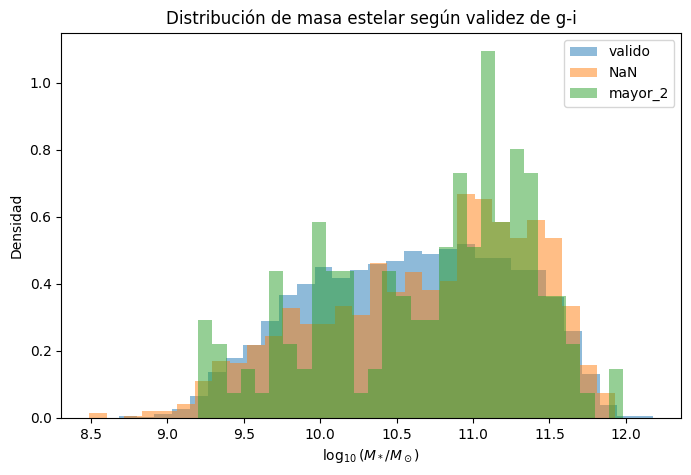

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for estado in ["valido", "NaN", "mayor_2"]:
    datos = masa_diag.loc[
        (masa_diag["estado_gi"] == estado) &
        (masa_diag["log_mstar"] >= 8) &
        (masa_diag["log_mstar"] <= 13),
        "log_mstar"
    ]

    plt.hist(
        datos,
        bins=30,
        density=True,
        alpha=0.5,
        label=estado
    )

plt.xlabel(r"$\log_{10}(M_*/M_\odot)$")
plt.ylabel("Densidad")
plt.title("Distribución de masa estelar según validez de g-i")
plt.legend()
plt.show()

### 6.5 Comparación robusta mediante percentiles de masa

#### ¿Qué se hace?

Se calculan los percentiles 25, 50 y 75 de la masa estelar para cada categoría de `estado_gi`.

#### ¿Por qué?

La masa estelar contiene algunos valores extremos que pueden afectar estadísticas como la media.

#### ¿Para qué?

Para comparar de forma más robusta la posición y dispersión central de las distribuciones de masa entre galaxias con `g-i` válido e inválido.

#### ¿Cómo?

Se calcularán:

$$
Q_{25}
$$

$$
Q_{50} = \mathrm{mediana}
$$

$$
Q_{75}
$$

para cada grupo de `estado_gi`.

In [30]:
# Percentiles robustos de masa por estado de g_i

percentiles_masa = (
    masa_diag
    .groupby("estado_gi")["log_mstar"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
    .rename(columns={
        0.25: "Q25",
        0.50: "Mediana",
        0.75: "Q75"
    })
    .round(3)
)

display(percentiles_masa)

,Q25,Mediana,Q75
estado_gi,,,
NaN,10.189,10.829,11.253
mayor_2,10.149,10.891,11.238
valido,10.080,10.632,11.133


Se siguió el criterio indicado por el asesor para definir g-i válido. Posteriormente se verificó que la exclusión de valores faltantes y mayores que 2 introduce una ligera preferencia hacia la pérdida de galaxias de mayor masa, por lo que este posible sesgo de selección se documenta en la interpretación de los resultados

### 6.6 Comparación de `g-i` válido e inválido según redshift

#### ¿Qué se hace?

Se compara la distribución de `redshift` entre galaxias con:

- `g-i` válido,
- `g-i` faltante (`NaN`),
- `g-i > 2`.

#### ¿Por qué?

La calidad fotométrica puede depender de qué tan distante aparece una galaxia. Si los valores inválidos de `g-i` se concentran en ciertos redshifts, el filtrado podría modificar la distribución de la muestra.

#### ¿Para qué?

Para identificar un posible sesgo de selección relacionado con redshift antes de definir la muestra final del experimento.

#### ¿Cómo?

Se calcularán estadísticas descriptivas y percentiles de `redshift` para cada categoría de `estado_gi`.

In [31]:
# Mantener solo galaxias con redshift disponible
z_diag = df_diag_katachi[
    df_diag_katachi["redshift"].notna()
].copy()

# Estadísticas descriptivas de redshift por estado de g_i
resumen_z = (
    z_diag
    .groupby("estado_gi")["redshift"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)

print("Resumen de redshift por estado de g_i:")
display(resumen_z)

# Percentiles robustos
percentiles_z = (
    z_diag
    .groupby("estado_gi")["redshift"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
    .rename(columns={
        0.25: "Q25",
        0.50: "Mediana",
        0.75: "Q75"
    })
    .round(4)
)

print("\nPercentiles de redshift:")
display(percentiles_z)

Resumen de redshift por estado de g_i:


,count,mean,median,std,min,max
estado_gi,,,,,,
NaN,1276,0.0464,0.0382,0.0279,0.0002,0.1496
mayor_2,140,0.0461,0.0373,0.0294,0.0152,0.1347
valido,8574,0.0454,0.0373,0.0279,0.0103,0.1497



Percentiles de redshift:


,Q25,Mediana,Q75
estado_gi,,,
NaN,0.0254,0.0382,0.0607
mayor_2,0.0253,0.0373,0.0559
valido,0.0260,0.0373,0.0539


La exclusión de galaxias con g_i faltante o mayor que 2 no produce un desplazamiento importante en la distribución de redshift.

### 6.7 Comparación de la validez de `g-i` según el split original de Katachi

#### ¿Qué se hace?

Se compara la proporción de galaxias con `g-i` válido, faltante o mayor que 2 dentro de los conjuntos originales `Train` y `Test` de Katachi.

#### ¿Por qué?

El filtrado por calidad de `g-i` podría afectar de manera diferente a Train y Test.

#### ¿Para qué?

Para comprobar que el criterio de selección no altera de forma desproporcionada uno de los dos conjuntos y que se puede conservar el split original de Katachi sin introducir un desequilibrio importante.

#### ¿Cómo?

Se calcularán conteos y porcentajes de `estado_gi` dentro de cada valor de `split`.

In [32]:
# Mantener solo objetos pertenecientes a Train o Test
split_diag = df_diag_katachi[
    df_diag_katachi["split"].isin(["Train", "Test"])
].copy()

# Conteos
tabla_split_conteos = pd.crosstab(
    split_diag["split"],
    split_diag["estado_gi"]
)

print("Conteos por split:")
display(tabla_split_conteos)

# Porcentajes dentro de cada split
tabla_split_porcentajes = pd.crosstab(
    split_diag["split"],
    split_diag["estado_gi"],
    normalize="index"
) * 100

print("\nPorcentajes dentro de cada split:")
display(tabla_split_porcentajes.round(2))

Conteos por split:


estado_gi,NaN,mayor_2,valido
split,,,
Test,139,15,835
Train,1124,125,7659



Porcentajes dentro de cada split:


estado_gi,NaN,mayor_2,valido
split,,,
Test,14.05,1.52,84.43
Train,12.62,1.40,85.98


El filtrado por calidad de g-i no afecta de forma importante y desproporcionada a Train o Test. Por tanto, podemos conservar el split original de Katachi y filtrar dentro de cada conjunto.

El filtro de g-i introduce una ligera selección hacia perder galaxias de mayor masa, pero no muestra un sesgo fuerte por morfología temprana/tardía, redshift o spli

### 6.8 Conclusiones del diagnóstico de calidad de `g-i`

El análisis de calidad de `g-i` permitió evaluar si la exclusión de galaxias con valores faltantes o mayores que 2 puede introducir un sesgo de selección en la muestra.

#### Morfología

La fracción de galaxias con `g-i` válido es muy similar entre los dos grupos morfológicos principales:

- Tempranas: 86.18%
- Tardías: 85.20%

Por lo tanto, no se observa un sesgo morfológico fuerte entre galaxias tempranas y tardías debido al criterio de validez de `g-i`.

#### Masa estelar

Las galaxias con `g-i` faltante o mayor que 2 presentan masas estelares ligeramente mayores, en promedio, que las galaxias con `g-i` válido.

Las medianas encontradas fueron:

$$
\mathrm{Mediana}_{\mathrm{valido}} = 10.632
$$

$$
\mathrm{Mediana}_{\mathrm{NaN}} = 10.829
$$

$$
\mathrm{Mediana}_{g_i>2} = 10.891
$$

Esto indica que la exclusión de galaxias sin `g-i` válido no es completamente aleatoria respecto a la masa estelar y puede introducir una ligera selección hacia la pérdida de galaxias más masivas.

#### Redshift

Las distribuciones de redshift son muy similares entre los tres grupos.

Las medianas fueron:

$$
z_{\mathrm{valido}} = 0.0373
$$

$$
z_{\mathrm{NaN}} = 0.0382
$$

$$
z_{g_i>2} = 0.0373
$$

Por lo tanto, no se observa un desplazamiento importante de la distribución de redshift debido al filtro de `g-i`.

#### Split original de Katachi

La proporción de galaxias con `g-i` válido es similar en Train y Test:

- Train: 85.98%
- Test: 84.43%

Esto indica que el filtrado por calidad de `g-i` no afecta de manera desproporcionada a uno de los dos conjuntos.

### Conclusión general

El criterio de selección definido para `g-i`:

$$
g_i \neq \mathrm{NaN}
\quad \text{y} \quad
g_i \leq 2
$$

no produce un sesgo fuerte respecto a morfología, redshift o split original de Katachi.

Sin embargo, sí se observa una ligera tendencia a excluir galaxias de mayor masa estelar. Esta diferencia se documentará como una posible limitación de selección de la muestra.

Por lo tanto, se considera adecuado continuar con la construcción de la muestra común para los experimentos, conservando el split original de Katachi y aplicando los filtros dentro de Train y Test por separado.

## 7. Construcción de la muestra común del experimento

### ¿Qué se hace?

Se construirá la muestra común que será utilizada para comparar los distintos modelos de ablación.

Una galaxia será incluida únicamente si cumple simultáneamente con los siguientes criterios:

- pertenece al conjunto original `Train` o `Test` de Katachi;
- tiene una clasificación morfológica válida;
- tiene un valor válido de `g_i`;
- tiene disponible la masa estelar de referencia `log_mstar`.

### ¿Por qué?

Los modelos que se compararán deben evaluarse sobre las mismas galaxias.

Si cada modelo utiliza una muestra diferente, una diferencia en el error podría deberse a cambios en la composición de la muestra y no necesariamente a la información adicional proporcionada al modelo.

### ¿Para qué?

Para construir una base común y controlada para los experimentos:

- imagen;
- imagen + morfología;
- imagen + `g_i`;
- imagen + morfología + `g_i`.

Además, se conservará el split original de Katachi para evitar fuga de información entre entrenamiento y prueba.

### ¿Cómo?

Se aplicarán los siguientes criterios:

Morfología válida:

$$
-5 \leq T_{11} \leq 10
$$

Por lo tanto:

$$
T_{11}=11
\quad \Longrightarrow \quad
\text{se excluye}
$$

Color válido:

$$
g_i \neq \mathrm{NaN}
\quad \text{y} \quad
g_i \leq 2
$$

También se requerirá:

$$
\log_{10}\left(\frac{M_*}{M_\odot}\right)
\neq \mathrm{NaN}
$$

y que la galaxia pertenezca originalmente a:

$$
\mathrm{split} \in \{\mathrm{Train},\mathrm{Test}\}
$$

No se realizará una nueva partición aleatoria de Train y Test.

In [33]:
# Construir la muestra común

muestra_comun = df_diag_katachi[
    # Split original de Katachi
    df_diag_katachi["split"].isin(["Train", "Test"])

    # Morfología válida: T_11 entre -5 y 10
    & df_diag_katachi["T_11"].between(-5, 10, inclusive="both")

    # g-i válido
    & (df_diag_katachi["estado_gi"] == "valido")

    # Masa estelar disponible
    & df_diag_katachi["log_mstar"].notna()
].copy()

print("Dimensiones de la muestra común:")
print(muestra_comun.shape)

print("\nDistribución por split:")
print(muestra_comun["split"].value_counts())

print("\nDistribución por morfología:")
print(muestra_comun["grupo_morfologico"].value_counts())

print("\nValores faltantes:")
print(
    muestra_comun[
        ["MANGAID", "T_11", "g_i", "log_mstar", "redshift", "split"]
    ].isna().sum()
)

Dimensiones de la muestra común:
(8449, 10)

Distribución por split:
split
Train    7617
Test      832
Name: count, dtype: int64

Distribución por morfología:
grupo_morfologico
Tardia      5323
Temprana    3126
Name: count, dtype: int64

Valores faltantes:
MANGAID      0
T_11         0
g_i          0
log_mstar    0
redshift     1
split        0
dtype: int64


### 7.1 Verificación final de integridad de la muestra común

#### ¿Qué se hace?

Se comprobará que cada galaxia aparezca una sola vez en la muestra y que ningún objeto pertenezca simultáneamente a los conjuntos `Train` y `Test`.

#### ¿Por qué?

La existencia de galaxias duplicadas o presentes en ambos conjuntos produciría fuga de información y podría invalidar la evaluación del modelo.

#### ¿Para qué?

Para garantizar que la muestra común conserve correctamente la partición original de Katachi antes de utilizarla en los experimentos.

#### ¿Cómo?

Se verificará:

- que `MANGAID` sea único;
- que no existan filas duplicadas;
- que cada `MANGAID` tenga un único valor de `split`.

El único valor faltante identificado hasta ahora corresponde a `redshift`. Como esta variable se utiliza únicamente para diagnóstico y no será una entrada ni la etiqueta del modelo en el primer experimento, esta galaxia no será excluida de la muestra común.

In [34]:
# ============================================================
# Verificación final de integridad de la muestra común
# ============================================================

# 1. Revisar MANGAID duplicados
duplicados_id = muestra_comun["MANGAID"].duplicated().sum()

# 2. Revisar filas completamente duplicadas
duplicados_filas = muestra_comun.duplicated().sum()

# 3. Verificar que cada galaxia tenga un solo split
splits_por_galaxia = muestra_comun.groupby("MANGAID")["split"].nunique()
galaxias_en_multiples_splits = (splits_por_galaxia > 1).sum()

print("MANGAID duplicados:", duplicados_id)
print("Filas completamente duplicadas:", duplicados_filas)
print("Galaxias presentes en más de un split:", galaxias_en_multiples_splits)

print("\nTotal muestra común:", len(muestra_comun))
print("\nSplit:")
print(muestra_comun["split"].value_counts())

MANGAID duplicados: 0
Filas completamente duplicadas: 0
Galaxias presentes en más de un split: 0

Total muestra común: 8449

Split:
split
Train    7617
Test      832
Name: count, dtype: int64


### 7.2 Conclusión de la construcción de la muestra común

La muestra común para los experimentos quedó conformada por:

- **8,449 galaxias en total**
- **7,617 galaxias en Train**
- **832 galaxias en Test**

Se verificó que:

- no existen `MANGAID` duplicados;
- no existen filas completamente duplicadas;
- ninguna galaxia aparece simultáneamente en Train y Test;
- todas las galaxias incluidas tienen morfología válida;
- todas tienen un valor válido de `g_i`;
- todas tienen disponible la masa estelar de referencia `log_mstar`.

Por lo tanto, la muestra común queda validada para los experimentos de ablación.

Se conservará el split original de Katachi y no se realizará una nueva partición aleatoria entre Train y Test, con el fin de evitar fuga de información.

Las **832 galaxias de Test permanecerán reservadas** para la evaluación final.

El siguiente paso será construir un conjunto de **Validation exclusivamente a partir de las 7,617 galaxias de Train**.

## 8. Creación del conjunto de Validation a partir de Train

### ¿Qué se hace?

Se dividirá únicamente el conjunto original `Train` de Katachi en dos subconjuntos:

- `Train_internal`: utilizado para ajustar los parámetros del modelo.
- `Validation`: utilizado para evaluar el modelo durante el desarrollo y seleccionar decisiones de entrenamiento.

El conjunto `Test` original permanecerá completamente reservado para la evaluación final.

### ¿Por qué?

El conjunto Test no debe utilizarse para tomar decisiones sobre hiperparámetros, número de épocas, learning rate, arquitectura o selección de modelos.

Si se consulta repetidamente Test durante el desarrollo, se corre el riesgo de adaptar indirectamente el modelo a ese conjunto y obtener una estimación demasiado optimista de su desempeño.

### ¿Para qué?

La creación de Validation permitirá comparar los modelos y ajustar el procedimiento de entrenamiento sin utilizar las 832 galaxias reservadas para la evaluación final.

### ¿Cómo?

Se utilizará únicamente el conjunto original `Train`, formado por 7,617 galaxias.

Se realizará una división:

$$
85\% \rightarrow \mathrm{Train\_internal}
$$

$$
15\% \rightarrow \mathrm{Validation}
$$

La división será estratificada por grupo morfológico para mantener aproximadamente la misma proporción de galaxias tempranas y tardías en ambos subconjuntos.

El conjunto original `Test` no será modificado.

In [35]:
from sklearn.model_selection import train_test_split

# ============================================================
# Separar Train y Test originales de Katachi
# ============================================================

train_original = muestra_comun[
    muestra_comun["split"] == "Train"
].copy()

test_final = muestra_comun[
    muestra_comun["split"] == "Test"
].copy()

print("Train original:", len(train_original))
print("Test final reservado:", len(test_final))

# ============================================================
# Crear Train interno y Validation
# Estratificación por morfología
# ============================================================

train_internal, validation = train_test_split(
    train_original,
    test_size=0.15,
    random_state=42,
    stratify=train_original["grupo_morfologico"]
)

print("\nTrain interno:", len(train_internal))
print("Validation:", len(validation))
print("Test final:", len(test_final))

Train original: 7617
Test final reservado: 832

Train interno: 6474
Validation: 1143
Test final: 832


### 8.1 Verificación de la estratificación por morfología

#### ¿Qué se hace?

Se comparará la proporción de galaxias tempranas y tardías en:

- `Train_internal`
- `Validation`
- `Test`

#### ¿Por qué?

La división entre Train y Validation se realizó de forma estratificada por morfología.

Es necesario comprobar que esta estrategia mantuvo proporciones similares entre los subconjuntos y que no se generó un desbalance artificial.

#### ¿Para qué?

Para asegurar que las diferencias posteriores entre Train y Validation no se deban a una composición morfológica distinta.

#### ¿Cómo?

Se calcularán los conteos y porcentajes de `grupo_morfologico` en cada subconjunto.

In [36]:
def resumen_morfologia(df, nombre):
    conteos = df["grupo_morfologico"].value_counts()
    porcentajes = df["grupo_morfologico"].value_counts(normalize=True) * 100

    print(f"\n{nombre}")
    print("-" * len(nombre))

    resumen = pd.DataFrame({
        "conteo": conteos,
        "porcentaje": porcentajes.round(2)
    })

    display(resumen)


resumen_morfologia(train_internal, "Train interno")
resumen_morfologia(validation, "Validation")
resumen_morfologia(test_final, "Test final")


Train interno
-------------


,conteo,porcentaje
grupo_morfologico,,
Tardia,4062,62.74
Temprana,2412,37.26



Validation
----------


,conteo,porcentaje
grupo_morfologico,,
Tardia,717,62.73
Temprana,426,37.27



Test final
----------


,conteo,porcentaje
grupo_morfologico,,
Tardia,544,65.38
Temprana,288,34.62


### 8.2 Conclusión de la estratificación morfológica

La división entre `Train_internal` y `Validation` conservó prácticamente la misma proporción de galaxias tempranas y tardías.

- `Train_internal`:
  - Tardías: 62.74%
  - Tempranas: 37.26%

- `Validation`:
  - Tardías: 62.73%
  - Tempranas: 37.27%

Esto confirma que la estratificación por `grupo_morfologico` funcionó correctamente.

El conjunto `Test` presenta una proporción ligeramente distinta:

- Tardías: 65.38%
- Tempranas: 34.62%

Sin embargo, esta diferencia no será corregida artificialmente, ya que el conjunto `Test` se conservará sin modificaciones para mantener la partición original de Katachi después de aplicar los filtros de calidad.

### 8.3 Comparación de masa estelar y `g-i` entre Train y Validation

#### ¿Qué se hace?

Se comparan las distribuciones de:

- masa estelar de referencia `log_mstar`,
- color `g_i`,

entre `Train_internal` y `Validation`.

#### ¿Por qué?

La estratificación se realizó únicamente por morfología. Por lo tanto, no garantiza que masa estelar y color tengan distribuciones similares entre ambos subconjuntos.

#### ¿Para qué?

Para comprobar que la división Train/Validation no generó diferencias importantes en las variables principales del experimento.

#### ¿Cómo?

Se calcularán estadísticas descriptivas y percentiles robustos de `log_mstar` y `g_i` para `Train_internal` y `Validation`.

In [37]:
# ============================================================
# Comparación de masa estelar y g_i entre Train y Validation
# ============================================================

def resumen_variable(train_df, val_df, columna):
    resumen = pd.DataFrame({
        "Train_mean": [train_df[columna].mean()],
        "Validation_mean": [val_df[columna].mean()],
        "Train_median": [train_df[columna].median()],
        "Validation_median": [val_df[columna].median()],
        "Train_std": [train_df[columna].std()],
        "Validation_std": [val_df[columna].std()],
        "Train_Q25": [train_df[columna].quantile(0.25)],
        "Validation_Q25": [val_df[columna].quantile(0.25)],
        "Train_Q75": [train_df[columna].quantile(0.75)],
        "Validation_Q75": [val_df[columna].quantile(0.75)]
    }).round(4)

    print(f"\nResumen de {columna}:")
    display(resumen)


resumen_variable(train_internal, validation, "log_mstar")
resumen_variable(train_internal, validation, "g_i")


Resumen de log_mstar:


,Train_mean,Validation_mean,Train_median,Validation_median,Train_std,Validation_std,Train_Q25,Validation_Q25,Train_Q75,Validation_Q75
0,10.5882,10.593,10.6178,10.5975,0.6628,0.6419,10.0665,10.0801,11.1153,11.1196



Resumen de g_i:


,Train_mean,Validation_mean,Train_median,Validation_median,Train_std,Validation_std,Train_Q25,Validation_Q25,Train_Q75,Validation_Q75
0,0.7724,0.7727,0.8256,0.8245,0.2609,0.2697,0.5716,0.5685,0.9813,0.9842


### 8.4 Conclusión de la división Train / Validation / Test

La división de la muestra común produjo los siguientes subconjuntos:

- `Train_internal`: 6,474 galaxias
- `Validation`: 1,143 galaxias
- `Test`: 832 galaxias

La partición entre `Train_internal` y `Validation` se realizó de forma estratificada por morfología.

Se verificó que ambos subconjuntos presentan distribuciones prácticamente equivalentes de:

- morfología,
- masa estelar `log_mstar`,
- color `g_i`.

Para masa estelar:

$$
\mathrm{Mediana}_{Train} = 10.6178
$$

$$
\mathrm{Mediana}_{Validation} = 10.5975
$$

Para color:

$$
\mathrm{Mediana}_{Train}(g_i) = 0.8256
$$

$$
\mathrm{Mediana}_{Validation}(g_i) = 0.8245
$$

Las medias, dispersiones y cuartiles también son muy similares entre ambos subconjuntos.

Por lo tanto, la partición se considera adecuada para el desarrollo de los modelos.

El conjunto `Test`, formado por 832 galaxias, permanecerá reservado y no se utilizará para tomar decisiones sobre arquitectura, hiperparámetros o selección del modelo.

## 9. Revisión de la arquitectura de Katachi para masa estelar

### ¿Qué se hace?

Se revisará la implementación original de Katachi para identificar la arquitectura utilizada en la predicción de masa estelar.

En particular, se buscará:

- el archivo o clase donde se define la red de masa;
- la arquitectura ResNet50 utilizada;
- el checkpoint correspondiente al modelo de masa;
- la dimensión de las características extraídas por la red antes de la capa final de regresión;
- el punto más adecuado para incorporar posteriormente información adicional de morfología y `g_i`.

### ¿Por qué?

Antes de modificar el modelo es necesario entender exactamente cómo está construida la red original.

Agregar nuevas variables sin conocer el flujo interno de la arquitectura podría llevar a modificar una parte incorrecta del modelo o impedir una comparación justa con Katachi.

### ¿Para qué?

Esta revisión permitirá diseñar una extensión multimodal controlada, manteniendo como base el modelo original de Katachi y añadiendo las nuevas variables únicamente en el punto de fusión apropiado.

El objetivo es que los experimentos posteriores comparen de forma consistente:

- imagen;
- imagen + morfología;
- imagen + `g_i`;
- imagen + morfología + `g_i`.

### ¿Cómo?

Primero se inspeccionarán los archivos Python del repositorio de Katachi para localizar dónde se define y utiliza el modelo de masa estelar.

En esta etapa no se modificará ni entrenará ninguna red. Solo se documentará la arquitectura original antes de realizar cambios.

In [38]:
import os

for root, dirs, files in os.walk("/content/Katachi"):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

In [39]:
import os

for root, dirs, files in os.walk("/content/Katachi"):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

In [40]:
import os

for root, dirs, files in os.walk("/content/Katachi"):
    nivel = root.replace("/content/Katachi", "").count(os.sep)
    indent = "  " * nivel

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:20]:
        print(f"{indent}  {file}")

Katachi/
  manga_SHAP_radial_plots.ipynb
  manga_SHAP_2d_property_plots.ipynb
  Plotting_Notebook.ipynb
  data_exploration.ipynb
  dn4000 to t50.ipynb
  MaNGA_DR17_Regr.ipynb
  README.md
  get_large_files.ipynb
  Plotting_Notebook_update.ipynb
  VACs/
    GEMA_2.0.2.fits
    manga-morphology-dl-DR17.fits
    MaNGA_gz-v2_0_1.fits
  dataloaders/
    place_holder.txt
  Catalogues/
    scalars.cat
    place_holder.txt
  Data Creation Notebooks/
    Data_Gathering.ipynb
    XAI_Methods.ipynb
  models/
    place_holder.txt


### 9.1 Localización de la arquitectura de masa en el notebook original

#### ¿Qué se hace?

Se inspeccionará el notebook `MaNGA_DR17_Regr.ipynb`, que parece contener la implementación principal de los modelos de regresión de Katachi.

#### ¿Por qué?

El repositorio no contiene scripts `.py` con la definición de la arquitectura y la carpeta `models/` no incluye código fuente, por lo que la implementación probablemente se encuentra directamente dentro del notebook.

#### ¿Para qué?

Para localizar:

- la creación de la ResNet50;
- la modificación de la capa final;
- el modelo utilizado para predecir masa estelar;
- la forma en que se cargan los pesos preentrenados;
- la dimensión de las características antes de la regresión final.

#### ¿Cómo?

Se leerá el contenido del notebook y se buscarán palabras clave relacionadas con la arquitectura y la masa estelar, sin modificar todavía ningún modelo.

In [41]:
import json

ruta_notebook = "/content/Katachi/MaNGA_DR17_Regr.ipynb"

with open(ruta_notebook, "r", encoding="utf-8") as f:
    nb = json.load(f)

palabras_clave = [
    "resnet",
    "mstar",
    "mass",
    "model",
    "torchvision",
    "fc"
]

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        codigo = "".join(cell["source"])

        if any(palabra.lower() in codigo.lower() for palabra in palabras_clave):
            print("=" * 80)
            print(f"CELDA {i}")
            print("=" * 80)
            print(codigo[:4000])
            print()

CELDA 2
import numpy as np
import pandas as pd
import os, time, shutil, hickle
from tqdm import tqdm
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.8)
sns.set_style('white')
import hickle

import torch
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models

import sklearn
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score
from sklearn.model_selection import train_test_split
from PIL import Image as image_PIL
from PIL import Image, ImageOps
import PIL
from PIL import ImageShow
from astropy.io import fits

from zoobot.pytorch.estimators import define_model as ZoobotModel

CELDA 7
# manga_cat = hickle.load(work_dir+'manga_training_labels_d4000.cat')
d

In [43]:
import torch
import torch.nn as nn
from torchvision import models

In [44]:
model_mass = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)

model_mass.fc = nn.Linear(2048, 1)

print(model_mass.fc)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 235MB/s]


Linear(in_features=2048, out_features=1, bias=True)


In [45]:
import os

ruta_modelos = "/content/Katachi/models"

print(os.listdir(ruta_modelos))

['place_holder.txt']


### 9.2 Localización del checkpoint preentrenado de masa

#### ¿Qué se hace?

Se revisará el notebook `get_large_files.ipynb` del repositorio original de Katachi para identificar la fuente de descarga de los pesos preentrenados del modelo de masa estelar.

#### ¿Por qué?

La carpeta `models/` del repositorio contiene únicamente un archivo placeholder, por lo que los checkpoints no se distribuyen directamente mediante GitHub.

#### ¿Para qué?

Para descargar exactamente el checkpoint utilizado por Katachi para la predicción de masa estelar, evitando utilizar pesos incorrectos o reconstrucciones no equivalentes.

#### ¿Cómo?

Se inspeccionará el contenido del notebook `get_large_files.ipynb` y se buscarán referencias a archivos `.pytorch`, `Mass`, `Manga_(DR17)_ResNet50_Mass` o rutas relacionadas con la carpeta `models/`.

In [46]:
import json

ruta_large_files = "/content/Katachi/get_large_files.ipynb"

with open(ruta_large_files, "r", encoding="utf-8") as f:
    nb_large = json.load(f)

palabras = [
    ".pytorch",
    "Mass",
    "mass",
    "model",
    "Manga_(DR17)_ResNet50_Mass"
]

for i, cell in enumerate(nb_large["cells"]):
    contenido = "".join(cell.get("source", []))

    if any(p.lower() in contenido.lower() for p in palabras):
        print("=" * 80)
        print(f"CELDA {i}")
        print("=" * 80)
        print(contenido)
        print()

CELDA 2
work_dir = 'PUT DIRECTORY OF KATACHI FOLDER HERE'
work_dir1 = work_dir+'\Catalogues'

def download_with_wget(url, destination_directory, filename):
    try:
        full_path = f"{destination_directory}/{filename}"
        wget.download(url, out=full_path)
        print(f"Downloaded file saved as: {full_path}")
    except Exception as e:
        print(f"An error occurred: {e}")


#Downloading full data catalogues generated for this work 
manga_scalars = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/scalars.cat',work_dir1, 'scalars')
manga_images = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/images.cat',work_dir1, 'images')
manga_shap_maps_mass = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/shap_mass.cat',work_dir1, 'shap_mass')
manga_shap_maps_sfr = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalo

### 9.3 Descarga y verificación del checkpoint de masa distribuido por Katachi

#### ¿Qué se hace?

Se descargará el checkpoint de masa estelar que aparece explícitamente en el notebook oficial `get_large_files.ipynb` de Katachi:

`Mass_ResNet50_log_t50_chain_90_10.pytorch`

#### ¿Por qué?

Durante la revisión del repositorio se encontró una inconsistencia entre notebooks:

- `MaNGA_DR17_Regr.ipynb` hace referencia a `Manga_(DR17)_ResNet50_Mass.pytorch`.
- `get_large_files.ipynb` distribuye `Mass_ResNet50_log_t50_chain_90_10.pytorch`.

Por lo tanto, no se asumirá que ambos checkpoints son equivalentes.

#### ¿Para qué?

Para trabajar inicialmente con un checkpoint cuya fuente de descarga está documentada directamente por el repositorio original de Katachi y comprobar posteriormente que su arquitectura y predicciones corresponden al modelo de masa esperado.

#### ¿Cómo?

Se descargará el archivo desde la URL indicada en `get_large_files.ipynb` y se almacenará en la carpeta `models/` del repositorio local.

In [47]:
import os
import urllib.request

ruta_modelos = "/content/Katachi/models"
os.makedirs(ruta_modelos, exist_ok=True)

url_mass = (
    "https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/models/"
    "Mass_ResNet50_log_t50_chain_90_10.pytorch"
)

ruta_mass = os.path.join(
    ruta_modelos,
    "Mass_ResNet50_log_t50_chain_90_10.pytorch"
)

urllib.request.urlretrieve(url_mass, ruta_mass)

print("Checkpoint guardado en:")
print(ruta_mass)

print("\nTamaño:")
print(round(os.path.getsize(ruta_mass) / (1024**2), 2), "MB")

Checkpoint guardado en:
/content/Katachi/models/Mass_ResNet50_log_t50_chain_90_10.pytorch

Tamaño:
90.0 MB


### 9.4 Inspección de la estructura del checkpoint de masa

#### ¿Qué se hace?

Se inspeccionará el contenido del checkpoint `Mass_ResNet50_log_t50_chain_90_10.pytorch` antes de cargarlo en la red.

#### ¿Por qué?

Los modelos de Katachi fueron entrenados utilizando `DataParallel` en varias GPU. Cuando un modelo se guarda de esta manera, los nombres de sus parámetros pueden incluir el prefijo `module.`.

Además, antes de reutilizar el checkpoint es necesario comprobar que corresponde a una ResNet50 con una única salida para masa estelar.

#### ¿Para qué?

Para asegurar que el checkpoint es compatible con la arquitectura que estamos reconstruyendo y evitar errores al cargar pesos incorrectos o incompatibles.

#### ¿Cómo?

Se cargará únicamente el `state_dict` en memoria y se inspeccionarán:

- el tipo de objeto guardado;
- las primeras claves de los parámetros;
- las claves correspondientes a la capa final `fc`;
- las dimensiones de sus pesos y sesgo.

En esta etapa todavía no se realizarán predicciones.

In [48]:
import torch

checkpoint = torch.load(
    "/content/Katachi/models/Mass_ResNet50_log_t50_chain_90_10.pytorch",
    map_location="cpu"
)

print("Tipo de objeto:")
print(type(checkpoint))

# Si directamente es un state_dict
if isinstance(checkpoint, dict):
    claves = list(checkpoint.keys())

    print("\nNúmero total de claves:")
    print(len(claves))

    print("\nPrimeras 10 claves:")
    for clave in claves[:10]:
        print(clave)

    print("\nClaves relacionadas con la capa final fc:")
    for clave in claves:
        if "fc." in clave:
            print(clave, checkpoint[clave].shape)

Tipo de objeto:
<class 'collections.OrderedDict'>

Número total de claves:
320

Primeras 10 claves:
module.conv1.weight
module.bn1.weight
module.bn1.bias
module.bn1.running_mean
module.bn1.running_var
module.bn1.num_batches_tracked
module.layer1.0.conv1.weight
module.layer1.0.bn1.weight
module.layer1.0.bn1.bias
module.layer1.0.bn1.running_mean

Claves relacionadas con la capa final fc:
module.fc.weight torch.Size([1, 2048])
module.fc.bias torch.Size([1])


### 9.5 Carga correcta del checkpoint de masa de Katachi

#### ¿Qué se hace?

Se reconstruye la arquitectura base de `ResNet50`, se redefine su capa final para regresión escalar y se cargan los pesos del checkpoint de masa de Katachi.

#### ¿Por qué?

El checkpoint descargado corresponde a un `state_dict` guardado con `DataParallel`, por lo que sus claves contienen el prefijo `module.`. Para reutilizarlo en una sesión normal de Colab, es necesario eliminar ese prefijo antes de cargar los pesos.

#### ¿Para qué?

Para recuperar correctamente el modelo de masa ya entrenado por los autores y usarlo como punto de partida del experimento base y del posterior fine-tuning con nuevas variables auxiliares.

#### ¿Cómo?

1. Se crea una instancia de `ResNet50`.
2. Se sustituye la capa final `fc` por una capa lineal con salida unitaria.
3. Se limpia el `state_dict` eliminando el prefijo `module.`.
4. Se cargan los pesos en la red.
5. Se deja el modelo en modo evaluación para verificar que todo quedó listo.

En esta etapa todavía no se incorporan ni morfología ni color `g-i`; únicamente se recupera el modelo base de masa de Katachi.

In [49]:
# ============================================================
# PASO 9.5 — CARGAR CORRECTAMENTE EL CHECKPOINT DE MASA
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
from collections import OrderedDict

ruta_checkpoint = "/content/Katachi/models/Mass_ResNet50_log_t50_chain_90_10.pytorch"

# ------------------------------------------------------------
# 1. Cargar checkpoint en CPU
# ------------------------------------------------------------

checkpoint = torch.load(ruta_checkpoint, map_location="cpu")

print("Tipo de checkpoint:", type(checkpoint))
print("Número de parámetros guardados:", len(checkpoint))

# ------------------------------------------------------------
# 2. Quitar el prefijo 'module.' de DataParallel
# ------------------------------------------------------------

state_dict_limpio = OrderedDict()

for clave, valor in checkpoint.items():
    nueva_clave = clave.replace("module.", "")
    state_dict_limpio[nueva_clave] = valor

print("\nPrimeras 10 claves limpias:")
for i, clave in enumerate(state_dict_limpio.keys()):
    if i >= 10:
        break
    print(clave)

# ------------------------------------------------------------
# 3. Reconstruir la arquitectura ResNet50
# ------------------------------------------------------------

model_mass = models.resnet50(weights=None)
model_mass.fc = nn.Linear(2048, 1)

print("\nArquitectura de la capa final:")
print(model_mass.fc)

# ------------------------------------------------------------
# 4. Cargar pesos
# ------------------------------------------------------------

resultado = model_mass.load_state_dict(state_dict_limpio, strict=True)

print("\nCheckpoint cargado correctamente.")
print("Resultado de load_state_dict:", resultado)

# ------------------------------------------------------------
# 5. Modo evaluación
# ------------------------------------------------------------

model_mass.eval()

print("\nModelo listo en modo evaluación.")
print("¿Modelo en eval()?:", not model_mass.training)

# ------------------------------------------------------------
# 6. Verificación de la capa final
# ------------------------------------------------------------

print("\nForma de la capa final cargada:")
print("fc.weight:", model_mass.fc.weight.shape)
print("fc.bias  :", model_mass.fc.bias.shape)

Tipo de checkpoint: <class 'collections.OrderedDict'>
Número de parámetros guardados: 320

Primeras 10 claves limpias:
conv1.weight
bn1.weight
bn1.bias
bn1.running_mean
bn1.running_var
bn1.num_batches_tracked
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.bn1.running_mean

Arquitectura de la capa final:
Linear(in_features=2048, out_features=1, bias=True)

Checkpoint cargado correctamente.
Resultado de load_state_dict: <All keys matched successfully>

Modelo listo en modo evaluación.
¿Modelo en eval()?: True

Forma de la capa final cargada:
fc.weight: torch.Size([1, 2048])
fc.bias  : torch.Size([1])


### 9.6 Verificación funcional del modelo de masa

#### ¿Qué se hace?

Se realizará una prueba simple con una entrada artificial que tenga la misma forma que una imagen utilizada por Katachi.

#### ¿Por qué?

Aunque el checkpoint se haya cargado correctamente, conviene verificar que el modelo puede realizar una propagación hacia adelante (`forward pass`) sin errores.

#### ¿Para qué?

Para confirmar que:

- la red acepta imágenes RGB;
- la resolución esperada es compatible con el modelo;
- la salida corresponde a un único valor por galaxia.

#### ¿Cómo?

Se generará un tensor artificial con la forma:

$$
(B, C, H, W) = (1, 3, 256, 256)
$$

donde:

- $B=1$ es el número de galaxias del lote;
- $C=3$ corresponde a los tres canales RGB;
- $H=W=256$ corresponde al tamaño de las imágenes utilizadas por Katachi.

La salida esperada debe tener la forma:

$$
(1,1)
$$

correspondiente a una predicción escalar de masa estelar para una galaxia.

In [50]:
# ============================================================
# PASO 9.6 — PRUEBA FUNCIONAL DEL MODELO
# ============================================================

# Crear una imagen artificial:
# 1 galaxia, 3 canales RGB, 256 x 256 píxeles
imagen_dummy = torch.randn(1, 3, 256, 256)

# Evitar cálculo de gradientes porque solo estamos verificando
with torch.no_grad():
    salida_dummy = model_mass(imagen_dummy)

print("Forma de entrada :", imagen_dummy.shape)
print("Forma de salida  :", salida_dummy.shape)
print("Salida obtenida  :", salida_dummy)

Forma de entrada : torch.Size([1, 3, 256, 256])
Forma de salida  : torch.Size([1, 1])
Salida obtenida  : tensor([[26.9078]])


### 9.7 Verificación del checkpoint con una galaxia real

#### ¿Qué se hace?

Se probará el modelo de masa preentrenado con una imagen real de una galaxia perteneciente a nuestra muestra.

#### ¿Por qué?

La prueba con una imagen artificial confirmó únicamente que la arquitectura funciona, pero no permite evaluar si los pesos cargados producen predicciones físicamente coherentes.

#### ¿Para qué?

Para comprobar que el checkpoint recuperado reproduce el comportamiento esperado del modelo de masa de Katachi antes de utilizarlo como punto de partida para el fine-tuning.

#### ¿Cómo?

Se localizará una imagen real correspondiente a un `MANGAID` de nuestra muestra, se aplicará el mismo preprocesamiento utilizado por Katachi y se comparará la predicción del modelo con la masa estelar de referencia `log_mstar`.

In [51]:
import os

for nombre in os.listdir("/content"):
    print(nombre)

.config
katachi.zip
Katachi
color_morp.csv
sample_data


### 9.8 Localización del formato de imágenes utilizado por Katachi

#### ¿Qué se hace?

Se revisará cómo el repositorio de Katachi almacena y carga las imágenes de las galaxias.

#### ¿Por qué?

El repositorio local no contiene una carpeta de imágenes, pero `get_large_files.ipynb` ofrece un archivo grande llamado `images.cat`.

Antes de descargarlo, es necesario comprobar si ese archivo contiene directamente las imágenes o si el notebook espera una estructura diferente.

#### ¿Para qué?

Para recuperar las imágenes originales de Katachi y probar el checkpoint de masa sobre una galaxia real de nuestra muestra.

#### ¿Cómo?

Se buscarán referencias a `images.cat`, `images (DR17)` y funciones de carga de imágenes dentro de los notebooks originales.

In [52]:
import json
import os

terminos = [
    "images.cat",
    "images (DR17)",
    "load_image_data",
    "Image.open",
    "manga_images"
]

for archivo in os.listdir("/content/Katachi"):
    if archivo.endswith(".ipynb"):
        ruta = os.path.join("/content/Katachi", archivo)

        with open(ruta, "r", encoding="utf-8") as f:
            nb = json.load(f)

        for i, cell in enumerate(nb["cells"]):
            contenido = "".join(cell.get("source", []))

            if any(t.lower() in contenido.lower() for t in terminos):
                print("=" * 80)
                print("NOTEBOOK:", archivo)
                print("CELDA:", i)
                print("=" * 80)
                print(contenido[:5000])
                print()

NOTEBOOK: manga_SHAP_radial_plots.ipynb
CELDA: 4
filepath = work_dir + 'images.cat'
d_im = hickle.load(filepath)

NOTEBOOK: manga_SHAP_2d_property_plots.ipynb
CELDA: 5
filepath = work_dir + 'images.cat'
d_im = hickle.load(filepath)

NOTEBOOK: Plotting_Notebook.ipynb
CELDA: 3
filepath = work_dir + 'Catalogues/images.cat'
d_im = hickle.load(filepath)
filepath = work_dir + 'Catalogues/shap_mass.cat'
d_shapmass = hickle.load(filepath)
filepath = work_dir + 'Catalogues/shap_sfr.cat'
d_shapsfr = hickle.load(filepath)
filepath = work_dir + 'Catalogues/shap_d4000.cat'
d_shapage = hickle.load(filepath)

NOTEBOOK: Plotting_Notebook.ipynb
CELDA: 4
def resize_image(src_image, size=(256,256), bg_color="black"): 
    
    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.ANTIALIAS)
    
    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)
    
    # Paste the resized image into the center of the square backg

### 9.9 Descarga e inspección del catálogo de imágenes de Katachi

#### ¿Qué se hace?

Se descargará el archivo `images.cat` distribuido por el repositorio original de Katachi y se inspeccionará su estructura.

#### ¿Por qué?

El repositorio local no contiene las imágenes individuales en formato PNG, pero los notebooks de análisis de Katachi cargan directamente `images.cat` mediante `hickle`.

#### ¿Para qué?

Para recuperar las imágenes reales utilizadas por Katachi y comprobar el comportamiento del checkpoint de masa sobre galaxias reales de nuestra muestra.

#### ¿Cómo?

Se descargará `images.cat` desde la fuente indicada en `get_large_files.ipynb`.

Después se cargará con `hickle` y se inspeccionará:

- el tipo de objeto almacenado;
- sus dimensiones o número de elementos;
- la forma de una imagen individual;
- y, si está disponible, la relación entre las imágenes y los `MANGAID`.

Todavía no se realizarán predicciones.

In [53]:
import os
import urllib.request

url_images = (
    "https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/images.cat"
)

ruta_images = "/content/Katachi/Catalogues/images.cat"

urllib.request.urlretrieve(url_images, ruta_images)

print("Archivo guardado en:")
print(ruta_images)

print("\nTamaño:")
print(round(os.path.getsize(ruta_images) / (1024**2), 2), "MB")

Archivo guardado en:
/content/Katachi/Catalogues/images.cat

Tamaño:
1890.73 MB


### 9.10 Inspección mínima de `images.cat`

#### ¿Qué se hace?

Se carga el catálogo de imágenes distribuido por Katachi únicamente para identificar su estructura interna.

#### ¿Por qué?

El archivo `images.cat` ocupa aproximadamente 1.89 GB, por lo que no conviene realizar operaciones innecesarias que dupliquen su contenido en memoria.

#### ¿Para qué?

Para determinar:

- qué tipo de objeto contiene;
- cuántas imágenes almacena;
- qué forma tiene una imagen individual;
- y cómo se relacionan las imágenes con los identificadores `MANGAID`.

#### ¿Cómo?

Se cargará el archivo con `hickle` y se inspeccionarán únicamente el tipo de objeto, sus claves o dimensiones y un primer elemento de ejemplo.

In [55]:
import hickle
import numpy as np

ruta_images = "/content/Katachi/Catalogues/images.cat"

print("Cargando images.cat...")
d_im = hickle.load(ruta_images)

print("\nTipo de objeto:")
print(type(d_im))

# Si es diccionario
if isinstance(d_im, dict):
    print("\nClaves:")
    print(d_im.keys())

    for clave in d_im.keys():
        try:
            valor = d_im[clave]
            print(f"\n{clave}")
            print("Tipo:", type(valor))

            if hasattr(valor, "shape"):
                print("Shape:", valor.shape)
            else:
                print("Longitud:", len(valor))

        except Exception as e:
            print("No se pudo inspeccionar:", e)

# Si no es diccionario
else:
    if hasattr(d_im, "shape"):
        print("\nShape:", d_im.shape)
    else:
        try:
            print("\nLongitud:", len(d_im))
        except:
            pass

Cargando images.cat...

Tipo de objeto:
<class 'pandas.core.frame.DataFrame'>

Shape: (10081, 2)


In [56]:
print("Columnas:")
print(d_im.columns.tolist())

print("\nPrimeras 3 filas:")
display(d_im.head(3))

print("\nTipos de datos:")
print(d_im.dtypes)

Columnas:
['mangaid', 'images']

Primeras 3 filas:


,mangaid,images
0,1-1009,<PIL.Image.Image image mode=RGB size=256x256 a...
1,1-10166,<PIL.Image.Image image mode=RGB size=256x256 a...
2,1-10177,<PIL.Image.Image image mode=RGB size=256x256 a...



Tipos de datos:
mangaid    object
images     object
dtype: object


In [57]:
print("\nPrimera fila:")
fila0 = d_im.iloc[0]

for col in d_im.columns:
    valor = fila0[col]
    print(f"\nColumna: {col}")
    print("Tipo:", type(valor))

    if hasattr(valor, "shape"):
        print("Shape:", valor.shape)
    else:
        print("Valor:", valor if isinstance(valor, (str, int, float)) else "objeto complejo")


Primera fila:

Columna: mangaid
Tipo: <class 'str'>
Valor: 1-1009

Columna: images
Tipo: <class 'PIL.Image.Image'>
Valor: objeto complejo


### 9.11 Prueba del checkpoint con una galaxia real

#### ¿Qué se hace?

Se seleccionará una galaxia real perteneciente a nuestra muestra común y se recuperará su imagen desde `images.cat`.

La imagen se convertirá al formato tensor esperado por la ResNet50 y se utilizará como entrada del checkpoint de masa de Katachi.

#### ¿Por qué?

La prueba anterior con una imagen artificial únicamente confirmó que la arquitectura funcionaba correctamente.

Ahora necesitamos verificar que, con una imagen real de MaNGA, el checkpoint produce una predicción de masa físicamente razonable.

#### ¿Para qué?

Para comprobar que:

- la imagen y el `MANGAID` se corresponden correctamente;
- el preprocesamiento es compatible con el modelo;
- el checkpoint produce valores en el rango esperado de masa estelar;
- la predicción puede compararse con la masa de referencia `log_mstar`.

#### ¿Cómo?

Se seleccionará una galaxia del conjunto `Validation`, se buscará su imagen mediante `MANGAID`, se transformará a tensor y se obtendrá:

$$
\log_{10}\left(\frac{M_{*,\mathrm{pred}}}{M_\odot}\right)
$$

Posteriormente se comparará con:

$$
\log_{10}\left(\frac{M_{*,\mathrm{Pipe3D}}}{M_\odot}\right)
$$

In [58]:
from torchvision import transforms

# ============================================================
# Seleccionar una galaxia real de Validation
# ============================================================

ejemplo = validation.iloc[0]

mangaid_ejemplo = ejemplo["MANGAID"]
masa_real = ejemplo["log_mstar"]

print("MANGAID:", mangaid_ejemplo)
print("log_mstar de referencia:", masa_real)

# ============================================================
# Buscar su imagen en images.cat
# ============================================================

fila_imagen = d_im[d_im["mangaid"] == mangaid_ejemplo]

print("\nNúmero de imágenes encontradas:", len(fila_imagen))

imagen_real = fila_imagen.iloc[0]["images"]

print("Tipo:", type(imagen_real))
print("Tamaño:", imagen_real.size)
print("Modo:", imagen_real.mode)

# ============================================================
# Transformar imagen a tensor
# ============================================================

transform_basico = transforms.ToTensor()

tensor_imagen = transform_basico(imagen_real).unsqueeze(0)

print("\nForma del tensor:", tensor_imagen.shape)

# ============================================================
# Predicción
# ============================================================

model_mass.eval()

with torch.no_grad():
    prediccion = model_mass(tensor_imagen).item()

print("\nlog_mstar de referencia :", round(float(masa_real), 4))
print("log_mstar predicho      :", round(float(prediccion), 4))
print("Residual pred - real    :", round(float(prediccion - masa_real), 4))

MANGAID: 1-53417
log_mstar de referencia: 11.0716009465831

Número de imágenes encontradas: 1
Tipo: <class 'PIL.Image.Image'>
Tamaño: (256, 256)
Modo: RGB

Forma del tensor: torch.Size([1, 3, 256, 256])

log_mstar de referencia : 11.0716
log_mstar predicho      : 11.1811
Residual pred - real    : 0.1095


### 9.12 Verificación del preprocesamiento original de imágenes

#### ¿Qué se hace?

Se revisará el notebook original de Katachi para identificar las transformaciones aplicadas a las imágenes antes de introducirlas en la ResNet50.

#### ¿Por qué?

La predicción de una galaxia real produjo un valor razonable, pero una sola prueba no garantiza que el preprocesamiento utilizado sea idéntico al del modelo original.

Las transformaciones de entrada pueden afectar de manera importante las predicciones de una CNN.

#### ¿Para qué?

Para reproducir de forma fiel el pipeline original de Katachi antes de utilizar el checkpoint como baseline o realizar fine-tuning.

#### ¿Cómo?

Se buscarán en el notebook original referencias a:

- `transforms.Compose`
- `ToTensor`
- `Normalize`
- `Resize`
- `RandomHorizontalFlip`
- otras transformaciones utilizadas en Train y Validation/Test.

In [59]:
terminos_transform = [
    "transforms.Compose",
    "ToTensor",
    "Normalize",
    "RandomHorizontalFlip",
    "RandomVerticalFlip",
    "Resize",
    "transform="
]

for i, cell in enumerate(nb["cells"]):
    contenido = "".join(cell.get("source", []))

    if any(t.lower() in contenido.lower() for t in terminos_transform):
        print("=" * 80)
        print(f"CELDA {i}")
        print("=" * 80)
        print(contenido[:5000])
        print()

CELDA 3
def resize_image(src_image, size=(256,256), bg_color="black"): 
    
    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.ANTIALIAS)
    
    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)
    
    # Paste the resized image into the center of the square background
    new_image.paste(src_image, (int((size[0] - src_image.size[0]) / 2), int((size[1] - src_image.size[1]) / 2)))
  
    # return the resized image
    return new_image

def load_image_data(idlist, size=(256,256), bg_color="black"):
    
    images = []
    for gal_id in tqdm(idlist):
        #img = plt.imread('images/'+gal_id+'.png')
        img = Image.open(work_dir+'images (DR17)/'+gal_id+'.png')
        img_sized = resize_image(img, size=size, bg_color=bg_color)
        images.append(img_sized)
    return images

class MaNGAdataset(Dataset):
    """images and labels for CNN"""
    
    def __init__(self, manga_cat, galma

### 9.13 Identificación de las transformaciones utilizadas al crear los DataLoaders

#### ¿Qué se hace?

Se localizarán las celdas donde se crean los datasets y DataLoaders originales de Katachi.

#### ¿Por qué?

La clase `MaNGAdataset` permite recibir una transformación mediante el argumento `transform`, pero todavía no se ha identificado qué transformación concreta se utilizó durante el entrenamiento y evaluación del modelo.

#### ¿Para qué?

Para confirmar si el preprocesamiento original consiste únicamente en convertir las imágenes a tensores o si incluye normalización, aumentos de datos u otras transformaciones.

#### ¿Cómo?

Se buscarán las llamadas a `MaNGAdataset`, así como las definiciones asociadas de `transform`, `train_loader` y `val_loader`.

In [60]:
terminos_dataset = [
    "MaNGAdataset(",
    "train_loader",
    "val_loader",
    "DataLoader(",
    "transform =",
    "transform=",
    "ToTensor()",
    "Compose("
]

for i, cell in enumerate(nb["cells"]):
    contenido = "".join(cell.get("source", []))

    if any(t.lower() in contenido.lower() for t in terminos_dataset):
        print("=" * 80)
        print(f"CELDA {i}")
        print("=" * 80)
        print(contenido[:7000])
        print()

CELDA 3
def resize_image(src_image, size=(256,256), bg_color="black"): 
    
    # resize the image so the longest dimension matches our target size
    src_image.thumbnail(size, Image.ANTIALIAS)
    
    # Create a new square background image
    new_image = Image.new("RGB", size, bg_color)
    
    # Paste the resized image into the center of the square background
    new_image.paste(src_image, (int((size[0] - src_image.size[0]) / 2), int((size[1] - src_image.size[1]) / 2)))
  
    # return the resized image
    return new_image

def load_image_data(idlist, size=(256,256), bg_color="black"):
    
    images = []
    for gal_id in tqdm(idlist):
        #img = plt.imread('images/'+gal_id+'.png')
        img = Image.open(work_dir+'images (DR17)/'+gal_id+'.png')
        img_sized = resize_image(img, size=size, bg_color=bg_color)
        images.append(img_sized)
    return images

class MaNGAdataset(Dataset):
    """images and labels for CNN"""
    
    def __init__(self, manga_cat, galma

### 9.14 Verificación directa del preprocesamiento mediante los DataLoaders originales

#### ¿Qué se hace?

Se comparará una imagen almacenada en los DataLoaders originales de Katachi con la misma galaxia recuperada desde `images.cat` y convertida mediante `ToTensor()`.

#### ¿Por qué?

Los notebooks de análisis cargan directamente DataLoaders previamente construidos, por lo que la definición original de las transformaciones no aparece explícitamente en esa parte del código.

#### ¿Para qué?

Para determinar empíricamente si la conversión:

`PIL Image` → `ToTensor()`

reproduce exactamente, o con diferencias despreciables, el tensor utilizado por el modelo original de Katachi.

#### ¿Cómo?

Se utilizará el mismo `MANGAID` en ambos casos:

1. se recuperará el tensor almacenado en un DataLoader original;
2. se recuperará la imagen PIL correspondiente desde `images.cat`;
3. se aplicará `ToTensor()`;
4. se compararán forma, rango de valores y diferencia numérica entre ambos tensores.

In [61]:
import os

ruta_dataloaders = "/content/Katachi/dataloaders"

print(os.listdir(ruta_dataloaders))

['place_holder.txt']


### 9.15 Descarga del DataLoader original de Test de Katachi

#### ¿Qué se hace?

Se descargará el DataLoader original utilizado por Katachi para el conjunto de prueba en los análisis de morfología y SHAP.

#### ¿Por qué?

El repositorio local solo contiene un archivo `place_holder.txt` en la carpeta `dataloaders/`, por lo que los DataLoaders originales deben descargarse desde la fuente externa indicada por los autores.

#### ¿Para qué?

Para comparar directamente una imagen ya transformada dentro del DataLoader original con la misma galaxia almacenada en `images.cat`.

Esto permitirá verificar si `ToTensor()` reproduce correctamente el preprocesamiento de entrada utilizado por Katachi.

#### ¿Cómo?

Se descargará únicamente:

`Test_Manga_DR17_Morph_for_SHAP_MAPS`

desde la URL definida en `get_large_files.ipynb`.

In [62]:
import os
import urllib.request

ruta_dataloaders = "/content/Katachi/dataloaders"
os.makedirs(ruta_dataloaders, exist_ok=True)

url_test_loader = (
    "https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/dataloaders/"
    "Test_Manga_DR17_Morph_for_SHAP_MAPS"
)

ruta_test_loader = os.path.join(
    ruta_dataloaders,
    "Test_Manga_DR17_Morph_for_SHAP_MAPS"
)

urllib.request.urlretrieve(
    url_test_loader,
    ruta_test_loader
)

print("DataLoader guardado en:")
print(ruta_test_loader)

print("\nTamaño:")
print(round(os.path.getsize(ruta_test_loader) / (1024**2), 2), "MB")

DataLoader guardado en:
/content/Katachi/dataloaders/Test_Manga_DR17_Morph_for_SHAP_MAPS

Tamaño:
176.23 MB


### 9.16 Comparación entre `images.cat` y el DataLoader original

#### ¿Qué se hace?

Se comparará una imagen almacenada en el DataLoader original de Katachi con la misma galaxia recuperada desde `images.cat` y convertida mediante `ToTensor()`.

#### ¿Por qué?

Los DataLoaders oficiales ya contienen las imágenes en el formato utilizado por el modelo original.

Compararlos con nuestras imágenes convertidas desde `images.cat` permite verificar si estamos reproduciendo correctamente el preprocesamiento de entrada.

#### ¿Para qué?

Para confirmar si la transformación:

`PIL Image` → `ToTensor()`

produce el mismo tensor que utilizó Katachi.

#### ¿Cómo?

Se seleccionará una galaxia del DataLoader original, se buscará su `MANGAID` en `images.cat`, se aplicará `ToTensor()` y se compararán:

- forma del tensor;
- valor mínimo;
- valor máximo;
- media;
- diferencia absoluta máxima;
- diferencia absoluta promedio.

Si las diferencias son nulas o prácticamente nulas, se considerará validado el preprocesamiento.

In [63]:
import hickle
import torch
from torchvision import transforms

# ============================================================
# 1. Cargar DataLoader original de Katachi
# ============================================================

ruta_test_loader = (
    "/content/Katachi/dataloaders/"
    "Test_Manga_DR17_Morph_for_SHAP_MAPS"
)

loader_original = hickle.load(ruta_test_loader)

print("Tipo de objeto cargado:")
print(type(loader_original))

# ============================================================
# 2. Tomar el primer batch y la primera galaxia
# ============================================================

primer_batch = next(iter(loader_original))

mangaid_loader = primer_batch["mangaid"][0]
tensor_loader = primer_batch["image"][0].cpu()

print("\nMANGAID seleccionado:", mangaid_loader)
print("Shape tensor original:", tensor_loader.shape)

# ============================================================
# 3. Buscar la misma galaxia en images.cat
# ============================================================

fila = d_im[d_im["mangaid"] == mangaid_loader]

print("Número de coincidencias en images.cat:", len(fila))

imagen_pil = fila.iloc[0]["images"]

# ============================================================
# 4. Convertir con ToTensor()
# ============================================================

tensor_images_cat = transforms.ToTensor()(imagen_pil)

print("Shape tensor desde images.cat:", tensor_images_cat.shape)

# ============================================================
# 5. Comparar estadísticas
# ============================================================

print("\n--- Tensor original Katachi ---")
print("Min :", tensor_loader.min().item())
print("Max :", tensor_loader.max().item())
print("Mean:", tensor_loader.mean().item())

print("\n--- Tensor desde images.cat + ToTensor() ---")
print("Min :", tensor_images_cat.min().item())
print("Max :", tensor_images_cat.max().item())
print("Mean:", tensor_images_cat.mean().item())

# ============================================================
# 6. Diferencias
# ============================================================

diferencia = torch.abs(tensor_loader - tensor_images_cat)

print("\nDiferencia absoluta máxima :", diferencia.max().item())
print("Diferencia absoluta media  :", diferencia.mean().item())

Tipo de objeto cargado:
<class 'hickle.lookup.RecoveredDataset'>


IndexError: invalid index to scalar variable.

### 9.17 Inspección de la estructura del DataLoader recuperado

#### ¿Qué se hace?

Se inspeccionará la estructura interna del objeto cargado desde el archivo original de Katachi.

#### ¿Por qué?

El archivo no fue recuperado como un `DataLoader` estándar, sino como un objeto `RecoveredDataset` de `hickle`.

Por lo tanto, antes de acceder a campos como `mangaid` o `image`, es necesario identificar cómo están almacenados los datos.

#### ¿Para qué?

Para acceder correctamente a una galaxia del conjunto original y comparar su tensor con la imagen correspondiente de `images.cat`.

#### ¿Cómo?

Se revisarán:

- el tipo de objeto;
- su longitud;
- los atributos disponibles;
- el tipo y contenido resumido de sus primeros elementos.

In [64]:
print("Tipo:")
print(type(loader_original))

print("\nLongitud:")
try:
    print(len(loader_original))
except Exception as e:
    print("No disponible:", e)

print("\nAtributos principales:")
print([a for a in dir(loader_original) if not a.startswith("_")][:50])

print("\nPrimeros elementos:")
for i in range(min(5, len(loader_original))):
    try:
        elemento = loader_original[i]
        print(f"\nÍndice {i}")
        print("Tipo:", type(elemento))

        if isinstance(elemento, dict):
            print("Claves:", elemento.keys())
        else:
            print("Representación:", repr(elemento)[:500])

    except Exception as e:
        print(f"Error en índice {i}:", e)

Tipo:
<class 'hickle.lookup.RecoveredDataset'>

Longitud:
184783871

Atributos principales:
['T', 'all', 'any', 'argmax', 'argmin', 'argpartition', 'argsort', 'astype', 'attrs', 'base', 'byteswap', 'choose', 'clip', 'compress', 'conj', 'conjugate', 'copy', 'ctypes', 'cumprod', 'cumsum', 'data', 'device', 'diagonal', 'dot', 'dtype', 'dump', 'dumps', 'fill', 'flags', 'flat', 'flatten', 'getfield', 'imag', 'item', 'itemset', 'itemsize', 'mT', 'max', 'mean', 'min', 'nbytes', 'ndim', 'newbyteorder', 'nonzero', 'partition', 'prod', 'ptp', 'put', 'ravel', 'real']

Primeros elementos:

Índice 0
Tipo: <class 'numpy.uint8'>
Representación: np.uint8(128)

Índice 1
Tipo: <class 'numpy.uint8'>
Representación: np.uint8(4)

Índice 2
Tipo: <class 'numpy.uint8'>
Representación: np.uint8(149)

Índice 3
Tipo: <class 'numpy.uint8'>
Representación: np.uint8(151)

Índice 4
Tipo: <class 'numpy.uint8'>
Representación: np.uint8(0)


### 9.18 Búsqueda del preprocesamiento en los notebooks de creación de datos

#### ¿Qué se hace?

Se buscará en todos los notebooks del repositorio, incluyendo las subcarpetas de creación de datos, la definición original de las transformaciones aplicadas a las imágenes.

#### ¿Por qué?

El DataLoader descargado no pudo reconstruirse correctamente con la versión actual de `hickle`, por lo que no es posible utilizarlo directamente para comparar los tensores.

Sin embargo, el preprocesamiento debe estar definido en alguna etapa anterior, cuando los DataLoaders fueron creados.

#### ¿Para qué?

Para identificar de forma documental si las imágenes utilizadas por Katachi fueron procesadas únicamente mediante `ToTensor()` o si además se aplicaron normalización, augmentations u otras transformaciones.

#### ¿Cómo?

Se realizará una búsqueda recursiva en todos los archivos `.ipynb` del repositorio utilizando términos relacionados con:

- `transforms.Compose`
- `ToTensor`
- `Normalize`
- `RandomHorizontalFlip`
- `RandomVerticalFlip`
- `ColorJitter`
- creación de `MaNGAdataset`
- creación de `DataLoader`

In [65]:
import os
import json

ruta_repo = "/content/Katachi"

terminos = [
    "transforms.Compose",
    "ToTensor",
    "Normalize",
    "RandomHorizontalFlip",
    "RandomVerticalFlip",
    "ColorJitter",
    "MaNGAdataset(",
    "DataLoader("
]

for root, dirs, files in os.walk(ruta_repo):
    for archivo in files:

        if not archivo.endswith(".ipynb"):
            continue

        ruta = os.path.join(root, archivo)

        try:
            with open(ruta, "r", encoding="utf-8") as f:
                notebook = json.load(f)
        except Exception:
            continue

        for i, cell in enumerate(notebook.get("cells", [])):
            contenido = "".join(cell.get("source", []))

            if any(t.lower() in contenido.lower() for t in terminos):

                ruta_relativa = os.path.relpath(ruta, ruta_repo)

                print("=" * 90)
                print("NOTEBOOK:", ruta_relativa)
                print("CELDA:", i)
                print("=" * 90)
                print(contenido[:8000])
                print()

NOTEBOOK: manga_SHAP_radial_plots.ipynb
CELDA: 8
def get_xax(z, nspaxels = 179):
    """
    Convert angular separation to physical distance at a given redshift (z)
    
    """
    spaxel_size = 0.5  # [arcsec]
    c = 299792  # speed of light [km/s]
    H0 = 70  # [km s^-1 Mpc^-1]
    D = c * z / H0  # a
    scale = 1 / 206265 * D * 1e6  # 1 radian = 206265 arcsec [pc / arcsec]
#     spaxel_area = (scale * spaxel_size)**2  # [pc^2]
    return np.arange(nspaxels) * (scale*spaxel_size) / 1e3 # return in kpc

def azimuthalAverage(image, center=None):
    """
    Calculate the azimuthally averaged radial profile.
    from: https://github.com/mkolopanis/python/blob/master/radialProfile.py 

    image - The 2D image
    center - The [x,y] pixel coordinates used as the center. The default is 
             None, which then uses the center of the image (including 
             fracitonal pixels).
    
    """
    # Calculate the indices from the image
    y, x = np.indices(image.shape)

    i

### 9.19 Conclusión sobre el preprocesamiento de imágenes

La revisión del código original de Katachi permitió identificar explícitamente la transformación aplicada a las imágenes antes de introducirlas en la ResNet50.

El preprocesamiento utilizado es:

```python
transforms.Compose([
    transforms.ToTensor()
])


## Estado del bloque 9

Ya tenemos:

- ResNet50 identificada
- entrada RGB 256×256
- salida de características de 2048
- regresión `2048 → 1`
- checkpoint de masa descargado
- `DataParallel` resuelto
- checkpoint cargado con todas las claves compatibles
- forward pass correcto
- prueba con galaxia real correcta
- preprocesamiento exacto: **`ToTensor()` solamente**

Con esto **la auditoría técnica del modelo base está suficientemente cerrada**.

### Lo siguiente

Ahora conviene hacer una cosa **antes de modificar la arquitectura con morfología o `g_i`**:

> evaluar el checkpoint actual de Katachi sobre nuestras **1,143 galaxias de Validation**.

Eso nos dará un punto de referencia inicial:

\[
\text{Katachi pretrained, sin fine-tuning}
\]

sobre exactamente nuestra nueva muestra.

Luego hacemos el verdadero baseline controlado:

\[
\text{imagen-only + fine-tuning}
\]

y después las ablaciones multimodales.

Así podremos distinguir claramente:

```text
Checkpoint original
        ↓
¿qué rendimiento tiene en nuestra muestra?
        ↓
Imagen-only fine-tuned
        ↓
¿qué mejora solo por reentrenar?
        ↓
+ morfología
+ g-i
+ ambos
        ↓
¿qué mejora realmente por las nuevas variables?

## 10. Evaluación del checkpoint original de Katachi en Validation

### ¿Qué se hace?

Se evaluará el checkpoint preentrenado de masa de Katachi sobre las 1,143 galaxias del conjunto `Validation`.

### ¿Por qué?

Antes de realizar fine-tuning o incorporar morfología y color `g_i`, necesitamos un punto de referencia sobre exactamente la misma muestra que utilizaremos durante el desarrollo.

### ¿Para qué?

Esta evaluación permitirá separar posteriormente:

- el rendimiento del checkpoint original;
- la mejora debida solamente al fine-tuning;
- la mejora adicional debida a morfología;
- la mejora adicional debida a `g_i`.

### ¿Cómo?

Para cada galaxia de `Validation`:

1. se recuperará su imagen desde `images.cat`;
2. se convertirá mediante `ToTensor()`;
3. se realizará una predicción con el checkpoint original;
4. se comparará con `log_mstar`.

Se calcularán:

- RMSE;
- MAE;
- sesgo medio de los residuos.

El residuo se define como:

$$
\Delta \log M_* =
\log M_{*,\mathrm{pred}}
-
\log M_{*,\mathrm{ref}}
$$

El conjunto `Test` permanecerá intacto y no se utilizará en esta etapa.

In [66]:
import numpy as np
import torch
from torchvision import transforms
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm.auto import tqdm

# ============================================================
# PASO 10 — CHECKPOINT ORIGINAL EN VALIDATION
# ============================================================

transform_katachi = transforms.ToTensor()

# Acceso rápido MANGAID -> imagen
imagenes_por_id = dict(zip(d_im["mangaid"], d_im["images"]))

ids_val = []
y_true_val = []
y_pred_val = []

model_mass.eval()

for _, fila in tqdm(validation.iterrows(), total=len(validation)):

    mangaid = fila["MANGAID"]
    masa_ref = float(fila["log_mstar"])

    imagen = imagenes_por_id.get(mangaid)

    if imagen is None:
        continue

    x = transform_katachi(imagen).unsqueeze(0)

    with torch.no_grad():
        pred = model_mass(x).item()

    ids_val.append(mangaid)
    y_true_val.append(masa_ref)
    y_pred_val.append(pred)

y_true_val = np.array(y_true_val)
y_pred_val = np.array(y_pred_val)

residuos_val = y_pred_val - y_true_val

rmse_val = np.sqrt(mean_squared_error(y_true_val, y_pred_val))
mae_val = mean_absolute_error(y_true_val, y_pred_val)
bias_val = np.mean(residuos_val)

print("Galaxias esperadas en Validation :", len(validation))
print("Galaxias evaluadas               :", len(y_true_val))

print("\nCheckpoint original de Katachi:")
print(f"RMSE : {rmse_val:.4f} dex")
print(f"MAE  : {mae_val:.4f} dex")
print(f"Bias : {bias_val:.4f} dex")

  0%|          | 0/1143 [00:00<?, ?it/s]

Galaxias esperadas en Validation : 1143
Galaxias evaluadas               : 1143

Checkpoint original de Katachi:
RMSE : 0.2240 dex
MAE  : 0.1717 dex
Bias : -0.0213 dex


### 10.1 Resultado del checkpoint original en Validation

El checkpoint original de Katachi fue evaluado sobre las 1,143 galaxias de nuestro conjunto de `Validation`.

Se obtuvieron los siguientes resultados:

| Métrica | Resultado |
|---|---:|
| N | 1143 |
| RMSE | 0.2240 dex |
| MAE | 0.1717 dex |
| Bias | -0.0213 dex |

El sesgo se definió como:

$$
\mathrm{Bias} =
\frac{1}{N}
\sum_{i=1}^{N}
\left(
\log M_{*,\mathrm{pred},i}
-
\log M_{*,\mathrm{ref},i}
\right)
$$

El valor negativo del Bias indica una ligera tendencia promedio a subestimar la masa estelar.

Este resultado se utilizará como **baseline preentrenado** del experimento.

A partir de este punto, cualquier comparación de modelos durante el desarrollo se realizará sobre este mismo conjunto de `Validation`, manteniendo el conjunto `Test` sin utilizar.

In [67]:
import pandas as pd

resultados_baseline_val = pd.DataFrame({
    "MANGAID": ids_val,
    "log_mstar_ref": y_true_val,
    "log_mstar_pred_pretrained": y_pred_val,
    "residuo_pretrained": residuos_val
})

print("Shape:", resultados_baseline_val.shape)

display(resultados_baseline_val.head())

print("\nComprobación:")
print("MANGAID duplicados:",
      resultados_baseline_val["MANGAID"].duplicated().sum())

print("Valores NaN:")
print(resultados_baseline_val.isna().sum())

Shape: (1143, 4)


,MANGAID,log_mstar_ref,log_mstar_pred_pretrained,residuo_pretrained
0,1-53417,11.071601,11.181074,0.109473
1,1-250870,10.761825,10.830038,0.068213
2,1-122059,11.092675,11.230226,0.137551
3,1-446229,9.790543,9.770038,-0.020506
4,1-39570,11.010933,11.131950,0.121017



Comprobación:
MANGAID duplicados: 0
Valores NaN:
MANGAID                      0
log_mstar_ref                0
log_mstar_pred_pretrained    0
residuo_pretrained           0
dtype: int64


## 11. Baseline imagen-only con fine-tuning

### ¿Qué se hace?

Se construirá un `Dataset` de PyTorch para las galaxias de `train_internal` y `validation`.

Cada muestra contendrá:

- imagen RGB de la galaxia;
- `MANGAID`;
- masa estelar de referencia `log_mstar`.

### ¿Por qué?

Necesitamos un pipeline propio, controlado y reproducible para realizar fine-tuning sobre exactamente nuestra muestra común.

### ¿Para qué?

Este Dataset será la base del modelo `imagen-only` y posteriormente se extenderá para incorporar:

- morfología;
- color `g_i`;
- morfología + `g_i`.

### ¿Cómo?

Las imágenes se recuperarán desde `images.cat` mediante `MANGAID`.

El preprocesamiento será el mismo validado para Katachi:

`PIL Image` → `ToTensor()`

sin normalización adicional.

In [68]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ============================================================
# TRANSFORMACIÓN VALIDADA DE KATACHI
# ============================================================

transform_katachi = transforms.ToTensor()

# Acceso rápido a imágenes
imagenes_por_id = dict(zip(d_im["mangaid"], d_im["images"]))


# ============================================================
# DATASET
# ============================================================

class KatachiMassDataset(Dataset):

    def __init__(self, dataframe, imagenes_dict, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.imagenes_dict = imagenes_dict
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        fila = self.df.iloc[idx]

        mangaid = fila["MANGAID"]
        masa = float(fila["log_mstar"])

        imagen = self.imagenes_dict[mangaid]

        if self.transform:
            imagen = self.transform(imagen)

        return {
            "image": imagen,
            "mass": torch.tensor(masa, dtype=torch.float32),
            "mangaid": mangaid
        }


# ============================================================
# CREAR DATASETS
# ============================================================

dataset_train = KatachiMassDataset(
    train_internal,
    imagenes_por_id,
    transform=transform_katachi
)

dataset_val = KatachiMassDataset(
    validation,
    imagenes_por_id,
    transform=transform_katachi
)

print("Train:", len(dataset_train))
print("Validation:", len(dataset_val))

# ============================================================
# INSPECCIONAR UNA MUESTRA
# ============================================================

muestra = dataset_train[0]

print("\nEjemplo:")
print("MANGAID:", muestra["mangaid"])
print("Image shape:", muestra["image"].shape)
print("Image dtype:", muestra["image"].dtype)
print("Min:", muestra["image"].min().item())
print("Max:", muestra["image"].max().item())
print("Mass:", muestra["mass"].item())

Train: 6474
Validation: 1143

Ejemplo:
MANGAID: 1-149905
Image shape: torch.Size([3, 256, 256])
Image dtype: torch.float32
Min: 0.0
Max: 0.9882352948188782
Mass: 10.573538780212402


### 11.1 Creación de DataLoaders y piloto de entrenamiento

#### ¿Qué se hace?

Se crearán los `DataLoader` para `train_internal` y `validation` y se realizará un entrenamiento piloto de una sola época.

#### ¿Por qué?

Antes de definir un protocolo completo de fine-tuning es necesario comprobar:

- que el entrenamiento funciona sin errores;
- que la memoria de GPU es suficiente;
- cuánto tarda aproximadamente una época;
- que la pérdida disminuye de forma razonable.

#### ¿Para qué?

Este piloto permitirá decidir después cuántas épocas utilizar y qué estrategia de fine-tuning conviene aplicar de forma justa a todos los modelos de la comparación.

#### ¿Cómo?

Se utilizará:

- batch size = 32;
- `shuffle=True` únicamente en Train;
- `shuffle=False` en Validation;
- el checkpoint preentrenado de Katachi como inicialización;
- MSE como función de pérdida.

Por ahora se ejecutará únicamente una época.

In [69]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader_ft = DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader_ft = DataLoader(
    dataset_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Batches Train      :", len(train_loader_ft))
print("Batches Validation :", len(val_loader_ft))

# revisar un batch
batch = next(iter(train_loader_ft))

print("\nShape imágenes :", batch["image"].shape)
print("Shape masas    :", batch["mass"].shape)
print("Ejemplo ID     :", batch["mangaid"][0])

Batches Train      : 203
Batches Validation : 36

Shape imágenes : torch.Size([32, 3, 256, 256])
Shape masas    : torch.Size([32])
Ejemplo ID     : 1-41133


### 11.2 Piloto de fine-tuning imagen-only

#### ¿Qué se hace?

Se realizará una sola época de fine-tuning del modelo imagen-only.

Se creará una copia independiente del modelo preentrenado para evitar modificar el checkpoint utilizado como baseline.

#### ¿Por qué?

Antes de definir un entrenamiento completo necesitamos comprobar:

- tiempo aproximado por época;
- uso correcto de GPU;
- estabilidad de la pérdida;
- comportamiento inicial en Validation.

#### ¿Para qué?

Esta prueba permitirá fijar posteriormente un protocolo de entrenamiento reproducible que también se aplicará a los modelos multimodales.

#### ¿Cómo?

Se utilizará:

- inicialización: checkpoint preentrenado de Katachi;
- arquitectura: ResNet50 RGB;
- función de pérdida: MSE;
- optimizador: Adam;
- learning rate inicial: $10^{-4}$;
- una sola época de entrenamiento.

Al finalizar se calculará el RMSE en Train y Validation.

In [70]:
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

# ============================================================
# DISPOSITIVO
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

# ============================================================
# COPIA INDEPENDIENTE DEL MODELO PREENTRENADO
# ============================================================

model_ft = copy.deepcopy(model_mass)
model_ft = model_ft.to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model_ft.parameters(),
    lr=1e-4
)

# ============================================================
# UNA ÉPOCA DE TRAIN
# ============================================================

inicio = time.time()

model_ft.train()

train_losses = []
train_true = []
train_pred = []

for batch in tqdm(train_loader_ft, desc="Train"):

    images = batch["image"].to(device)
    targets = batch["mass"].to(device)

    optimizer.zero_grad()

    outputs = model_ft(images).squeeze(1)

    loss = criterion(outputs, targets)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    train_true.extend(targets.detach().cpu().numpy())
    train_pred.extend(outputs.detach().cpu().numpy())

# ============================================================
# VALIDATION
# ============================================================

model_ft.eval()

val_true = []
val_pred = []

with torch.no_grad():

    for batch in tqdm(val_loader_ft, desc="Validation"):

        images = batch["image"].to(device)
        targets = batch["mass"].to(device)

        outputs = model_ft(images).squeeze(1)

        val_true.extend(targets.cpu().numpy())
        val_pred.extend(outputs.cpu().numpy())

# ============================================================
# MÉTRICAS
# ============================================================

train_true = np.array(train_true)
train_pred = np.array(train_pred)

val_true = np.array(val_true)
val_pred = np.array(val_pred)

rmse_train_piloto = np.sqrt(
    mean_squared_error(train_true, train_pred)
)

rmse_val_piloto = np.sqrt(
    mean_squared_error(val_true, val_pred)
)

tiempo = time.time() - inicio

print("\n--- PILOTO 1 ÉPOCA ---")
print(f"Loss Train promedio : {np.mean(train_losses):.4f}")
print(f"RMSE Train           : {rmse_train_piloto:.4f} dex")
print(f"RMSE Validation      : {rmse_val_piloto:.4f} dex")
print(f"Tiempo total         : {tiempo/60:.2f} minutos")

Dispositivo: cuda


Train:   0%|          | 0/203 [00:00<?, ?it/s]

Validation:   0%|          | 0/36 [00:00<?, ?it/s]


--- PILOTO 1 ÉPOCA ---
Loss Train promedio : 0.0762
RMSE Train           : 0.2763 dex
RMSE Validation      : 0.2773 dex
Tiempo total         : 0.29 minutos


### 11.3 Resultado del primer piloto de fine-tuning

Se realizó una época de fine-tuning actualizando todos los parámetros de la ResNet50 con Adam y un learning rate de $10^{-4}$.

Los resultados fueron:

| Configuración | RMSE Validation |
|---|---:|
| Checkpoint preentrenado, sin fine-tuning | 0.2240 dex |
| Fine-tuning completo, 1 época, lr = $10^{-4}$ | 0.2773 dex |

El fine-tuning completo produjo un deterioro del rendimiento en Validation.

Esto sugiere que actualizar simultáneamente todos los parámetros de una ResNet50 ya entrenada con este learning rate es demasiado agresivo para nuestra muestra.

Por lo tanto, esta configuración se descarta y no se continuará entrenando durante más épocas.

El siguiente experimento utilizará una estrategia más conservadora: congelar el extractor convolucional y actualizar únicamente la última capa de regresión.

### 11.4 Piloto de fine-tuning únicamente de la capa final

#### ¿Qué se hace?

Se repetirá el piloto de una época, pero manteniendo congelado el extractor de características de la ResNet50.

Únicamente se actualizarán los parámetros de la capa final `fc`.

#### ¿Por qué?

El checkpoint preentrenado ya presenta un buen rendimiento en nuestra muestra.

Actualizar toda la red deterioró el RMSE, por lo que se probará una adaptación más conservadora.

#### ¿Para qué?

Para determinar si es posible adaptar la relación entre las características visuales aprendidas por Katachi y nuestra masa de referencia sin modificar las representaciones internas de la CNN.

#### ¿Cómo?

Se partirá nuevamente del checkpoint original.

Todos los parámetros se congelarán excepto:

`fc.weight` y `fc.bias`.

Se utilizará una época piloto y se volverá a medir el RMSE sobre el mismo conjunto de Validation.

In [71]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

# ============================================================
# VOLVER AL CHECKPOINT ORIGINAL
# ============================================================

model_fc = copy.deepcopy(model_mass).to(device)

# Congelar toda la red
for param in model_fc.parameters():
    param.requires_grad = False

# Descongelar solamente fc
for param in model_fc.fc.parameters():
    param.requires_grad = True

# Comprobar parámetros entrenables
entrenables = [
    name for name, param in model_fc.named_parameters()
    if param.requires_grad
]

print("Parámetros entrenables:")
print(entrenables)

criterion = nn.MSELoss()

optimizer_fc = optim.Adam(
    model_fc.fc.parameters(),
    lr=1e-4
)

# ============================================================
# 1 ÉPOCA
# ============================================================

inicio = time.time()

model_fc.train()

for batch in tqdm(train_loader_ft, desc="Train FC"):

    images = batch["image"].to(device)
    targets = batch["mass"].to(device)

    optimizer_fc.zero_grad()

    outputs = model_fc(images).squeeze(1)

    loss = criterion(outputs, targets)

    loss.backward()
    optimizer_fc.step()

# ============================================================
# VALIDATION
# ============================================================

model_fc.eval()

val_true_fc = []
val_pred_fc = []

with torch.no_grad():

    for batch in tqdm(val_loader_ft, desc="Validation"):

        images = batch["image"].to(device)
        targets = batch["mass"].to(device)

        outputs = model_fc(images).squeeze(1)

        val_true_fc.extend(targets.cpu().numpy())
        val_pred_fc.extend(outputs.cpu().numpy())

val_true_fc = np.array(val_true_fc)
val_pred_fc = np.array(val_pred_fc)

rmse_val_fc = np.sqrt(
    mean_squared_error(val_true_fc, val_pred_fc)
)

tiempo_fc = time.time() - inicio

print("\n--- PILOTO FC ONLY ---")
print(f"RMSE pretrained       : {rmse_val:.4f} dex")
print(f"RMSE FC-only          : {rmse_val_fc:.4f} dex")
print(f"Tiempo total          : {tiempo_fc/60:.2f} minutos")

Parámetros entrenables:
['fc.weight', 'fc.bias']


Train FC:   0%|          | 0/203 [00:00<?, ?it/s]

Validation:   0%|          | 0/36 [00:00<?, ?it/s]


--- PILOTO FC ONLY ---
RMSE pretrained       : 0.2240 dex
RMSE FC-only          : 0.2238 dex
Tiempo total          : 0.13 minutos


### 11.5 Resultado del piloto con extractor visual congelado

Se realizó una segunda prueba de adaptación del checkpoint de Katachi manteniendo congelados todos los parámetros de la ResNet50 excepto la capa final de regresión.

Los resultados fueron:

| Modelo | RMSE Validation |
|---|---:|
| Checkpoint original | 0.2240 dex |
| Fine-tuning completo, 1 época | 0.2773 dex |
| Fine-tuning solo de `fc`, 1 época | 0.2238 dex |

Actualizar toda la red produjo un deterioro considerable del rendimiento.

En cambio, modificar únicamente la capa final mantuvo prácticamente intacto el rendimiento del checkpoint original.

La diferencia entre el checkpoint preentrenado y el ajuste de la capa `fc` fue únicamente de 0.0002 dex, por lo que no existe evidencia de una mejora sustancial debida al fine-tuning en esta prueba.

A partir de estos resultados se adoptará una estrategia conservadora:

- utilizar el extractor visual preentrenado de Katachi;
- mantener congelada la ResNet50;
- utilizar las 2048 características producidas por la última capa de representación;
- entrenar posteriormente nuevas capas de regresión y de fusión multimodal.

Esta estrategia permitirá evaluar de forma más controlada si la incorporación explícita de morfología y color `g-i` aporta información adicional a la representación visual aprendida por Katachi.

## 12. Extracción de características visuales de la ResNet50

### ¿Qué se hace?

Se modificará una copia del modelo de Katachi para eliminar la capa final de regresión.

De esta forma, en lugar de producir directamente una estimación de masa estelar, la red devolverá el vector de características visuales aprendido por la ResNet50.

### ¿Por qué?

La capa final original transforma un vector de 2048 características en una única predicción de masa.

Para construir modelos multimodales necesitamos acceder primero a esas características visuales intermedias.

### ¿Para qué?

El vector de 2048 características servirá como representación visual común para comparar:

- imagen únicamente;
- imagen + morfología;
- imagen + color `g-i`;
- imagen + morfología + color `g-i`.

### ¿Cómo?

Se partirá nuevamente del checkpoint original de Katachi.

La capa final:

`Linear(2048, 1)`

será reemplazada por una identidad:

`Identity()`

De esta forma, la salida del modelo tendrá forma:

$$
(B, 2048)
$$

donde $B$ es el número de galaxias del batch.

In [72]:
import copy
import torch
import torch.nn as nn

# ============================================================
# CREAR EXTRACTOR DE CARACTERÍSTICAS
# ============================================================

feature_extractor = copy.deepcopy(model_mass)

# Reemplazar la capa final de regresión por identidad
feature_extractor.fc = nn.Identity()

# Congelar todos los parámetros
for param in feature_extractor.parameters():
    param.requires_grad = False

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# ============================================================
# PROBAR CON UN BATCH
# ============================================================

batch = next(iter(train_loader_ft))

images = batch["image"].to(device)

with torch.no_grad():
    features = feature_extractor(images)

print("Shape imágenes :", images.shape)
print("Shape features :", features.shape)
print("Dtype features :", features.dtype)

print("\nEjemplo, primeros 10 valores:")
print(features[0, :10].detach().cpu())

Shape imágenes : torch.Size([32, 3, 256, 256])
Shape features : torch.Size([32, 2048])
Dtype features : torch.float32

Ejemplo, primeros 10 valores:
tensor([0.6885, 1.3435, 0.5474, 1.0239, 0.8206, 0.5155, 0.3862, 0.6686, 0.9619,
        0.9896])


## 13. Preparación de variables tabulares para el modelo multimodal

### ¿Qué se hace?

Se prepararán las variables adicionales que se incorporarán a las características visuales:

- morfología;
- color `g_i`.

### ¿Por qué?

Estas variables tienen escalas y significados diferentes.

La morfología se representará como una variable binaria:

- temprana = 0;
- tardía = 1.

El color `g_i` es una variable continua y debe estandarizarse antes de introducirse en el modelo.

### ¿Para qué?

Para que las variables tabulares puedan combinarse de forma estable con las 2048 características visuales extraídas por la ResNet50.

### ¿Cómo?

La estandarización de `g_i` se calculará exclusivamente con `train_internal`:

$$
g_i^{\mathrm{std}} =
\frac{g_i-\mu_{\mathrm{Train}}}{\sigma_{\mathrm{Train}}}
$$

Los mismos valores de $\mu_{\mathrm{Train}}$ y $\sigma_{\mathrm{Train}}$ se aplicarán posteriormente a Validation y Test.

Esto evita utilizar información de Validation o Test durante la preparación del modelo.

In [73]:
import numpy as np

# ============================================================
# COPIAS PARA NO MODIFICAR LOS DATAFRAMES ORIGINALES
# ============================================================

train_mm = train_internal.copy()
val_mm = validation.copy()
test_mm = test_final.copy()

# ============================================================
# CODIFICACIÓN MORFOLÓGICA
# Temprana = 0
# Tardía   = 1
# ============================================================

mapa_morfologia = {
    "Temprana": 0.0,
    "Tardia": 1.0
}

for df in [train_mm, val_mm, test_mm]:
    df["morf_bin"] = df["grupo_morfologico"].map(mapa_morfologia)

# ============================================================
# ESTANDARIZACIÓN DE g-i USANDO SOLO TRAIN
# ============================================================

gi_media_train = train_mm["g_i"].mean()
gi_std_train = train_mm["g_i"].std()

for df in [train_mm, val_mm, test_mm]:
    df["g_i_std"] = (
        (df["g_i"] - gi_media_train) / gi_std_train
    )

# ============================================================
# COMPROBACIONES
# ============================================================

print("Media g-i Train:", gi_media_train)
print("Std g-i Train  :", gi_std_train)

print("\nTrain estandarizado:")
print("Media:", train_mm["g_i_std"].mean())
print("Std  :", train_mm["g_i_std"].std())

print("\nValores únicos morfología:")
print(train_mm["morf_bin"].value_counts().sort_index())

print("\nNaN:")
print(
    train_mm[["morf_bin", "g_i_std"]].isna().sum()
)

Media g-i Train: 0.7724463676984552
Std g-i Train  : 0.2609175018329707

Train estandarizado:
Media: -2.765782660048583e-16
Std  : 0.9999999999999989

Valores únicos morfología:
morf_bin
0.0    2412
1.0    4062
Name: count, dtype: int64

NaN:
morf_bin    0
g_i_std     0
dtype: int64


## 14. Arquitectura multimodal con fusión tardía

### ¿Qué se hace?

Se construirá una arquitectura de fusión tardía que combine las características visuales extraídas por la ResNet50 con variables tabulares.

La ResNet50 permanecerá congelada y funcionará únicamente como extractor de características.

### ¿Por qué?

La ResNet50 de Katachi ya produce una representación visual de 2048 dimensiones con buen rendimiento para la estimación de masa estelar.

En lugar de modificar las primeras capas convolucionales, se incorporará la información adicional después de la extracción visual.

### ¿Para qué?

Esto permitirá comparar de forma controlada cuatro configuraciones:

- imagen;
- imagen + morfología;
- imagen + `g_i`;
- imagen + morfología + `g_i`.

### ¿Cómo?

La representación visual tendrá dimensión:

$$
2048
$$

A esta representación se concatenarán, según el experimento:

- morfología: 1 variable;
- `g_i`: 1 variable.

La representación combinada se introducirá en una pequeña red completamente conectada para producir:

$$
\log_{10}\left(\frac{M_*}{M_\odot}\right)
$$

In [74]:
import torch
import torch.nn as nn

class MultimodalMassRegressor(nn.Module):

    def __init__(
        self,
        feature_extractor,
        usar_morfologia=False,
        usar_gi=False
    ):
        super().__init__()

        self.feature_extractor = feature_extractor

        self.usar_morfologia = usar_morfologia
        self.usar_gi = usar_gi

        # Número de variables tabulares
        n_tab = int(usar_morfologia) + int(usar_gi)

        # Entrada total:
        # 2048 visuales + variables tabulares
        input_dim = 2048 + n_tab

        self.regressor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, morfologia=None, gi=None):

        # El extractor visual permanece congelado
        with torch.no_grad():
            visual_features = self.feature_extractor(image)

        features = [visual_features]

        if self.usar_morfologia:
            features.append(morfologia.unsqueeze(1))

        if self.usar_gi:
            features.append(gi.unsqueeze(1))

        x = torch.cat(features, dim=1)

        return self.regressor(x).squeeze(1)

In [75]:
# Modelo con ambas variables
modelo_prueba = MultimodalMassRegressor(
    feature_extractor=feature_extractor,
    usar_morfologia=True,
    usar_gi=True
).to(device)

# Batch visual existente
batch = next(iter(train_loader_ft))

imagenes = batch["image"].to(device)

# Tomamos las primeras 32 filas correspondientes como ejemplo
morf = torch.tensor(
    train_mm.iloc[:32]["morf_bin"].values,
    dtype=torch.float32,
    device=device
)

gi = torch.tensor(
    train_mm.iloc[:32]["g_i_std"].values,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    salida = modelo_prueba(
        imagenes,
        morfologia=morf,
        gi=gi
    )

print("Shape salida:", salida.shape)
print("Primeras 5 predicciones:")
print(salida[:5])

Shape salida: torch.Size([32])
Primeras 5 predicciones:
tensor([ 0.0061, -0.0085, -0.0023,  0.0334,  0.0069], device='cuda:0')


## 15. Dataset multimodal alineado por MANGAID

### ¿Qué se hace?

Se construirá un nuevo `Dataset` que entregue, para cada galaxia:

- imagen RGB;
- masa estelar de referencia;
- morfología codificada;
- color `g_i` estandarizado;
- `MANGAID`.

### ¿Por qué?

En un modelo multimodal es esencial que todas las modalidades correspondan exactamente a la misma galaxia.

No se debe asumir que las filas tabulares mantienen el mismo orden que los batches del `DataLoader`, especialmente cuando `shuffle=True`.

### ¿Para qué?

Para garantizar una alineación correcta entre:

$$
\text{imagen}
\leftrightarrow
\text{morfología}
\leftrightarrow
g_i
\leftrightarrow
\log M_*
$$

### ¿Cómo?

Cada muestra se construirá directamente a partir de una misma fila del DataFrame y su `MANGAID`.

De esta forma, todas las variables permanecerán sincronizadas incluso cuando el `DataLoader` mezcle el orden de las galaxias.

In [76]:
class KatachiMultimodalDataset(Dataset):

    def __init__(self, dataframe, imagenes_dict, transform=None):

        self.df = dataframe.reset_index(drop=True).copy()
        self.imagenes_dict = imagenes_dict
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        fila = self.df.iloc[idx]

        mangaid = fila["MANGAID"]

        # Imagen
        imagen = self.imagenes_dict[mangaid]

        if self.transform:
            imagen = self.transform(imagen)

        # Variables
        masa = torch.tensor(
            float(fila["log_mstar"]),
            dtype=torch.float32
        )

        morfologia = torch.tensor(
            float(fila["morf_bin"]),
            dtype=torch.float32
        )

        gi = torch.tensor(
            float(fila["g_i_std"]),
            dtype=torch.float32
        )

        return {
            "image": imagen,
            "mass": masa,
            "morph": morfologia,
            "gi": gi,
            "mangaid": mangaid
        }

In [78]:
class KatachiMultimodalDataset(Dataset):

    def __init__(self, dataframe, imagenes_dict, transform=None):

        self.df = dataframe.reset_index(drop=True).copy()
        self.imagenes_dict = imagenes_dict
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        fila = self.df.iloc[idx]

        mangaid = fila["MANGAID"]

        imagen = self.imagenes_dict[mangaid]

        if self.transform:
            imagen = self.transform(imagen)

        masa = torch.tensor(
            float(fila["log_mstar"]),
            dtype=torch.float32
        )

        morfologia = torch.tensor(
            float(fila["morf_bin"]),
            dtype=torch.float32
        )

        gi = torch.tensor(
            float(fila["g_i_std"]),
            dtype=torch.float32
        )

        return {
            "image": imagen,
            "mass": masa,
            "morph": morfologia,
            "gi": gi,
            "mangaid": mangaid
        }

In [79]:
dataset_train_mm = KatachiMultimodalDataset(
    train_mm,
    imagenes_por_id,
    transform=transform_katachi
)

dataset_val_mm = KatachiMultimodalDataset(
    val_mm,
    imagenes_por_id,
    transform=transform_katachi
)

print("Train multimodal:", len(dataset_train_mm))
print("Validation multimodal:", len(dataset_val_mm))

Train multimodal: 6474
Validation multimodal: 1143


In [80]:
muestra_mm = dataset_train_mm[0]

print("MANGAID    :", muestra_mm["mangaid"])
print("Image shape:", muestra_mm["image"].shape)
print("Mass       :", muestra_mm["mass"].item())
print("Morph      :", muestra_mm["morph"].item())
print("g_i std    :", muestra_mm["gi"].item())

print("\nFila original:")
display(
    train_mm.loc[
        train_mm["MANGAID"] == muestra_mm["mangaid"],
        [
            "MANGAID",
            "log_mstar",
            "grupo_morfologico",
            "morf_bin",
            "g_i",
            "g_i_std"
        ]
    ]
)

MANGAID    : 1-149905
Image shape: torch.Size([3, 256, 256])
Mass       : 10.573538780212402
Morph      : 0.0
g_i std    : 0.6871234774589539

Fila original:


,MANGAID,log_mstar,grupo_morfologico,morf_bin,g_i,g_i_std
8024,1-149905,10.573539,Temprana,0.0,0.951729,0.687123


### 15.1 Creación de DataLoaders multimodales

#### ¿Qué se hace?

Se crearán los `DataLoader` para entrenamiento y validación utilizando el Dataset multimodal.

Cada batch contendrá de forma alineada:

- imagen RGB;
- masa estelar de referencia;
- morfología;
- color `g_i` estandarizado;
- `MANGAID`.

#### ¿Por qué?

Los modelos multimodales necesitan recibir simultáneamente todas las modalidades correspondientes a la misma galaxia.

#### ¿Para qué?

Estos DataLoaders se utilizarán en los experimentos de ablación:

- imagen;
- imagen + morfología;
- imagen + `g_i`;
- imagen + morfología + `g_i`.

#### ¿Cómo?

Se utilizará:

- `batch_size = 32`;
- `shuffle=True` en Train;
- `shuffle=False` en Validation.

In [81]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader_mm = DataLoader(
    dataset_train_mm,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader_mm = DataLoader(
    dataset_val_mm,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Batches Train      :", len(train_loader_mm))
print("Batches Validation :", len(val_loader_mm))

# Revisar un batch
batch_mm = next(iter(train_loader_mm))

print("\nShapes:")
print("Images :", batch_mm["image"].shape)
print("Mass   :", batch_mm["mass"].shape)
print("Morph  :", batch_mm["morph"].shape)
print("g_i    :", batch_mm["gi"].shape)

print("\nEjemplo:")
print("MANGAID:", batch_mm["mangaid"][0])
print("Mass   :", batch_mm["mass"][0].item())
print("Morph  :", batch_mm["morph"][0].item())
print("g_i    :", batch_mm["gi"][0].item())

Batches Train      : 203
Batches Validation : 36

Shapes:
Images : torch.Size([32, 3, 256, 256])
Mass   : torch.Size([32])
Morph  : torch.Size([32])
g_i    : torch.Size([32])

Ejemplo:
MANGAID: 1-273120
Mass   : 11.156256675720215
Morph  : 0.0
g_i    : 0.9250849485397339


## 16. Ablación A: modelo imagen-only con extractor congelado

### ¿Qué se hace?

Se entrenará un nuevo regresor utilizando únicamente las 2048 características visuales producidas por la ResNet50 congelada de Katachi.

No se utilizarán todavía morfología ni color `g_i`.

### ¿Por qué?

Este modelo debe servir como baseline arquitectónico para las comparaciones multimodales.

Todos los experimentos posteriores utilizarán el mismo extractor visual congelado y una cabeza de regresión equivalente.

### ¿Para qué?

Para que cualquier mejora observada al incorporar morfología o `g_i` pueda atribuirse a esas variables adicionales y no a un cambio en la arquitectura del regresor.

### ¿Cómo?

La entrada será:

$$
\mathbf{x}_{\mathrm{visual}} \in \mathbb{R}^{2048}
$$

y el regresor tendrá la forma:

$$
2048 \rightarrow 128 \rightarrow 1
$$

Se realizará primero un entrenamiento piloto y se evaluará el RMSE sobre Validation.

In [82]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

# ============================================================
# MODELO A — IMAGEN ONLY
# ============================================================

modelo_A = MultimodalMassRegressor(
    feature_extractor=feature_extractor,
    usar_morfologia=False,
    usar_gi=False
).to(device)

criterion = nn.MSELoss()

optimizer_A = optim.Adam(
    modelo_A.regressor.parameters(),
    lr=1e-3
)

num_epochs = 5

historial_A = []

mejor_rmse_A = np.inf
mejor_estado_A = None

# ============================================================
# ENTRENAMIENTO
# ============================================================

for epoch in range(1, num_epochs + 1):

    modelo_A.train()

    train_losses = []

    for batch in tqdm(
        train_loader_mm,
        desc=f"Epoch {epoch}/{num_epochs} - Train"
    ):

        images = batch["image"].to(device)
        targets = batch["mass"].to(device)

        optimizer_A.zero_grad()

        outputs = modelo_A(images)

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer_A.step()

        train_losses.append(loss.item())

    # ========================================================
    # VALIDATION
    # ========================================================

    modelo_A.eval()

    val_true = []
    val_pred = []

    with torch.no_grad():

        for batch in val_loader_mm:

            images = batch["image"].to(device)
            targets = batch["mass"].to(device)

            outputs = modelo_A(images)

            val_true.extend(targets.cpu().numpy())
            val_pred.extend(outputs.cpu().numpy())

    val_true = np.array(val_true)
    val_pred = np.array(val_pred)

    rmse = np.sqrt(
        mean_squared_error(val_true, val_pred)
    )

    train_loss_media = np.mean(train_losses)

    historial_A.append({
        "epoch": epoch,
        "train_loss": train_loss_media,
        "val_rmse": rmse
    })

    print(
        f"Epoch {epoch}: "
        f"Train Loss = {train_loss_media:.4f} | "
        f"Val RMSE = {rmse:.4f} dex"
    )

    # Guardar mejor estado
    if rmse < mejor_rmse_A:
        mejor_rmse_A = rmse
        mejor_estado_A = copy.deepcopy(
            modelo_A.state_dict()
        )

print("\nMejor RMSE modelo A:")
print(f"{mejor_rmse_A:.4f} dex")

Epoch 1/5 - Train:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 1: Train Loss = 2.0558 | Val RMSE = 0.3298 dex


Epoch 2/5 - Train:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.0812 | Val RMSE = 0.2820 dex


Epoch 3/5 - Train:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.0781 | Val RMSE = 0.2575 dex


Epoch 4/5 - Train:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.0745 | Val RMSE = 0.2489 dex


Epoch 5/5 - Train:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 5: Train Loss = 0.0880 | Val RMSE = 0.2744 dex

Mejor RMSE modelo A:
0.2489 dex


### 16.1 Replanteamiento de la cabeza de regresión para una ablación controlada

El primer modelo imagen-only con una nueva MLP `2048 → 128 → 1` obtuvo un mejor RMSE de 0.2489 dex, inferior al RMSE de 0.2240 dex del checkpoint original.

Esto indica que reemplazar completamente la capa de regresión original obliga al modelo a reaprender desde cero la relación entre las características visuales y la masa estelar.

Para evitar esta pérdida de información se adoptará una estrategia más conservadora.

La capa de regresión multimodal se inicializará a partir de la capa `fc` original de Katachi.

Para las características visuales:

$$
w_{\mathrm{visual}} = w_{\mathrm{Katachi}}
$$

Para las nuevas variables tabulares:

$$
w_{\mathrm{tabular}} = 0
$$

y:

$$
b = b_{\mathrm{Katachi}}
$$

Por lo tanto, antes de realizar entrenamiento, los modelos multimodales producirán exactamente la misma estimación que el checkpoint original.

Esto permite evaluar posteriormente si morfología y/o color `g_i` aportan una corrección adicional a la predicción visual, sin destruir la relación previamente aprendida por Katachi.

In [83]:
import torch
import torch.nn as nn


class FusionLinealKatachi(nn.Module):

    def __init__(
        self,
        feature_extractor,
        fc_original,
        usar_morfologia=False,
        usar_gi=False
    ):
        super().__init__()

        self.feature_extractor = feature_extractor
        self.usar_morfologia = usar_morfologia
        self.usar_gi = usar_gi

        n_tab = int(usar_morfologia) + int(usar_gi)

        # 2048 visuales + variables adicionales
        self.regressor = nn.Linear(2048 + n_tab, 1)

        # ----------------------------------------------------
        # Inicialización desde Katachi
        # ----------------------------------------------------
        with torch.no_grad():

            # Los 2048 pesos visuales se copian del modelo original
            self.regressor.weight[:, :2048].copy_(
                fc_original.weight
            )

            # Las nuevas variables empiezan con peso = 0
            if n_tab > 0:
                self.regressor.weight[:, 2048:].zero_()

            # Bias original
            self.regressor.bias.copy_(
                fc_original.bias
            )

    def forward(self, image, morfologia=None, gi=None):

        with torch.no_grad():
            visual = self.feature_extractor(image)

        features = [visual]

        if self.usar_morfologia:
            features.append(morfologia.unsqueeze(1))

        if self.usar_gi:
            features.append(gi.unsqueeze(1))

        x = torch.cat(features, dim=1)

        return self.regressor(x).squeeze(1)

In [85]:
# Asegurar que ambos modelos estén en el mismo dispositivo

model_mass = model_mass.to(device)
modelo_A_control = modelo_A_control.to(device)

model_mass.eval()
modelo_A_control.eval()

batch = next(iter(val_loader_mm))

images = batch["image"].to(device)

with torch.no_grad():

    pred_original = model_mass(images).squeeze(1)

    pred_control = modelo_A_control(images)

diferencia = torch.abs(
    pred_original - pred_control
)

print("Diferencia máxima :", diferencia.max().item())
print("Diferencia media  :", diferencia.mean().item())

print("\nPrimeras 5:")
for i in range(5):
    print(
        float(pred_original[i]),
        float(pred_control[i])
    )

Diferencia máxima : 0.06482124328613281
Diferencia media  : 0.033082008361816406

Primeras 5:
11.180758476257324 11.216540336608887
10.830404281616211 10.872082710266113
11.229472160339355 11.268818855285645
9.770153999328613 9.793784141540527
11.130863189697266 11.164512634277344


### 16.2 Corrección del estado de Batch Normalization en el extractor congelado

Durante la comprobación de equivalencia se encontró una diferencia entre las predicciones del checkpoint original y las obtenidas al reconstruir su capa final a partir de las 2048 características visuales.

La causa es que congelar los parámetros mediante `requires_grad=False` no impide que las capas de Batch Normalization actualicen sus estadísticas internas cuando el modelo se encuentra en modo `train()`.

Por lo tanto, un extractor visual congelado debe permanecer también en modo de evaluación:

`feature_extractor.eval()`

durante todo el entrenamiento de las nuevas capas.

Para evitar utilizar estadísticas de Batch Normalization modificadas durante los experimentos piloto, el extractor visual se reconstruirá nuevamente a partir del checkpoint original de Katachi.

De esta forma, el extractor utilizado en las ablaciones conservará exactamente las representaciones del modelo preentrenado.

In [86]:
import copy
import torch.nn as nn

# ============================================================
# RECONSTRUIR EXTRACTOR DESDE EL MODELO ORIGINAL INTACTO
# ============================================================

feature_extractor = copy.deepcopy(model_mass)

# Eliminar únicamente la capa final de regresión
feature_extractor.fc = nn.Identity()

# Congelar parámetros
for param in feature_extractor.parameters():
    param.requires_grad = False

# GPU + modo evaluación PERMANENTE
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("Extractor reconstruido.")
print("Modo training:", feature_extractor.training)

# Comprobar una BatchNorm como ejemplo
for modulo in feature_extractor.modules():
    if isinstance(modulo, nn.BatchNorm2d):
        print("Primera BatchNorm en modo training:", modulo.training)
        break

Extractor reconstruido.
Modo training: False
Primera BatchNorm en modo training: False


In [87]:
# ============================================================
# RECREAR MODELO A DE CONTROL
# ============================================================

modelo_A_control = FusionLinealKatachi(
    feature_extractor=feature_extractor,
    fc_original=model_mass.fc,
    usar_morfologia=False,
    usar_gi=False
).to(device)

modelo_A_control.eval()
model_mass.eval()

# ============================================================
# COMPARACIÓN DIRECTA
# ============================================================

batch = next(iter(val_loader_mm))

images = batch["image"].to(device)

with torch.no_grad():

    pred_original = model_mass(images).squeeze(1)

    pred_control = modelo_A_control(images)

diferencia = torch.abs(pred_original - pred_control)

print("Diferencia máxima :", diferencia.max().item())
print("Diferencia media  :", diferencia.mean().item())

print("\nPrimeras 5:")
for i in range(5):
    print(
        float(pred_original[i]),
        float(pred_control[i])
    )

Diferencia máxima : 0.0
Diferencia media  : 0.0

Primeras 5:
11.180758476257324 11.180758476257324
10.830404281616211 10.830404281616211
11.229472160339355 11.229472160339355
9.770153999328613 9.770153999328613
11.130863189697266 11.130863189697266


## 17. Ablación B: imagen + morfología

### ¿Qué se hace?

Se entrenará un modelo que combine las 2048 características visuales de Katachi con una variable morfológica binaria.

La morfología se codifica como:

- temprana = 0;
- tardía = 1.

### ¿Por qué?

Queremos medir si la información morfológica explícita aporta una corrección adicional a la estimación de masa obtenida únicamente a partir de la imagen.

### ¿Para qué?

Este experimento permitirá comparar:

$$
\text{Imagen}
\quad \text{vs} \quad
\text{Imagen + Morfología}
$$

manteniendo fija la representación visual de Katachi.

### ¿Cómo?

La capa final recibirá:

$$
2048 + 1
$$

variables.

Los 2048 pesos visuales se inicializan con los valores originales de Katachi.

El peso correspondiente a morfología se inicializa en cero, por lo que antes del entrenamiento el modelo reproduce exactamente el checkpoint original.

In [88]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

# ============================================================
# MODELO B — IMAGEN + MORFOLOGÍA
# ============================================================

modelo_B = FusionLinealKatachi(
    feature_extractor=feature_extractor,
    fc_original=model_mass.fc,
    usar_morfologia=True,
    usar_gi=False
).to(device)

criterion = nn.MSELoss()

optimizer_B = optim.Adam(
    modelo_B.regressor.parameters(),
    lr=1e-4
)

num_epochs = 5

historial_B = []

mejor_rmse_B = np.inf
mejor_estado_B = None

# ============================================================
# ENTRENAMIENTO
# ============================================================

for epoch in range(1, num_epochs + 1):

    # IMPORTANTE:
    # entrenamos la cabeza, pero mantenemos extractor en eval()
    modelo_B.train()
    modelo_B.feature_extractor.eval()

    train_losses = []

    for batch in tqdm(
        train_loader_mm,
        desc=f"Epoch {epoch}/{num_epochs} - Train B"
    ):

        images = batch["image"].to(device)
        targets = batch["mass"].to(device)
        morph = batch["morph"].to(device)

        optimizer_B.zero_grad()

        outputs = modelo_B(
            images,
            morfologia=morph
        )

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer_B.step()

        train_losses.append(loss.item())

    # ========================================================
    # VALIDATION
    # ========================================================

    modelo_B.eval()

    val_true_B = []
    val_pred_B = []

    with torch.no_grad():

        for batch in val_loader_mm:

            images = batch["image"].to(device)
            targets = batch["mass"].to(device)
            morph = batch["morph"].to(device)

            outputs = modelo_B(
                images,
                morfologia=morph
            )

            val_true_B.extend(targets.cpu().numpy())
            val_pred_B.extend(outputs.cpu().numpy())

    val_true_B = np.array(val_true_B)
    val_pred_B = np.array(val_pred_B)

    rmse_B = np.sqrt(
        mean_squared_error(val_true_B, val_pred_B)
    )

    train_loss_media = np.mean(train_losses)

    historial_B.append({
        "epoch": epoch,
        "train_loss": train_loss_media,
        "val_rmse": rmse_B
    })

    print(
        f"Epoch {epoch}: "
        f"Train Loss = {train_loss_media:.4f} | "
        f"Val RMSE = {rmse_B:.4f} dex"
    )

    if rmse_B < mejor_rmse_B:
        mejor_rmse_B = rmse_B
        mejor_estado_B = copy.deepcopy(
            modelo_B.state_dict()
        )

print("\nMejor RMSE modelo B:")
print(f"{mejor_rmse_B:.4f} dex")

Epoch 1/5 - Train B:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.0587 | Val RMSE = 0.2235 dex


Epoch 2/5 - Train B:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.0570 | Val RMSE = 0.2242 dex


Epoch 3/5 - Train B:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.0575 | Val RMSE = 0.2252 dex


Epoch 4/5 - Train B:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.0582 | Val RMSE = 0.2481 dex


Epoch 5/5 - Train B:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 5: Train Loss = 0.0578 | Val RMSE = 0.2248 dex

Mejor RMSE modelo B:
0.2235 dex


## 18. Ablación C: imagen + color `g_i`

### ¿Qué se hace?

Se entrenará un modelo que combine las 2048 características visuales de Katachi con el color `g_i` estandarizado.

### ¿Por qué?

El color `g_i` contiene información relacionada con las poblaciones estelares y con la relación masa-luminosidad.

Aunque las imágenes RGB ya contienen información de color, este experimento permitirá evaluar si proporcionar explícitamente un valor fotométrico calibrado aporta información adicional a la representación visual aprendida por la CNN.

### ¿Para qué?

Se comparará:

$$
\text{Imagen}
\quad \text{vs} \quad
\text{Imagen} + g-i
$$

manteniendo fijo el extractor visual de Katachi.

### ¿Cómo?

La entrada de la capa final tendrá dimensión:

$$
2048 + 1
$$

Los 2048 pesos visuales se inicializarán con los pesos originales de Katachi.

El peso correspondiente a `g_i` se inicializará en cero.

Por lo tanto, antes del entrenamiento el modelo reproduce exactamente la predicción del checkpoint original.

In [89]:
# ============================================================
# MODELO C — IMAGEN + g-i
# ============================================================

modelo_C = FusionLinealKatachi(
    feature_extractor=feature_extractor,
    fc_original=model_mass.fc,
    usar_morfologia=False,
    usar_gi=True
).to(device)

criterion = nn.MSELoss()

optimizer_C = optim.Adam(
    modelo_C.regressor.parameters(),
    lr=1e-4
)

num_epochs = 5

historial_C = []

mejor_rmse_C = np.inf
mejor_estado_C = None

# ============================================================
# ENTRENAMIENTO
# ============================================================

for epoch in range(1, num_epochs + 1):

    modelo_C.train()
    modelo_C.feature_extractor.eval()

    train_losses = []

    for batch in tqdm(
        train_loader_mm,
        desc=f"Epoch {epoch}/{num_epochs} - Train C"
    ):

        images = batch["image"].to(device)
        targets = batch["mass"].to(device)
        gi = batch["gi"].to(device)

        optimizer_C.zero_grad()

        outputs = modelo_C(
            images,
            gi=gi
        )

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer_C.step()

        train_losses.append(loss.item())

    # ========================================================
    # VALIDATION
    # ========================================================

    modelo_C.eval()

    val_true_C = []
    val_pred_C = []

    with torch.no_grad():

        for batch in val_loader_mm:

            images = batch["image"].to(device)
            targets = batch["mass"].to(device)
            gi = batch["gi"].to(device)

            outputs = modelo_C(
                images,
                gi=gi
            )

            val_true_C.extend(targets.cpu().numpy())
            val_pred_C.extend(outputs.cpu().numpy())

    val_true_C = np.array(val_true_C)
    val_pred_C = np.array(val_pred_C)

    rmse_C = np.sqrt(
        mean_squared_error(val_true_C, val_pred_C)
    )

    train_loss_media = np.mean(train_losses)

    historial_C.append({
        "epoch": epoch,
        "train_loss": train_loss_media,
        "val_rmse": rmse_C
    })

    print(
        f"Epoch {epoch}: "
        f"Train Loss = {train_loss_media:.4f} | "
        f"Val RMSE = {rmse_C:.4f} dex"
    )

    if rmse_C < mejor_rmse_C:
        mejor_rmse_C = rmse_C
        mejor_estado_C = copy.deepcopy(
            modelo_C.state_dict()
        )

print("\nMejor RMSE modelo C:")
print(f"{mejor_rmse_C:.4f} dex")

Epoch 1/5 - Train C:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.0583 | Val RMSE = 0.2345 dex


Epoch 2/5 - Train C:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.0571 | Val RMSE = 0.2249 dex


Epoch 3/5 - Train C:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.0571 | Val RMSE = 0.2267 dex


Epoch 4/5 - Train C:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.0577 | Val RMSE = 0.2307 dex


Epoch 5/5 - Train C:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 5: Train Loss = 0.0574 | Val RMSE = 0.2237 dex

Mejor RMSE modelo C:
0.2237 dex


## 19. Ablación D: imagen + morfología + color `g_i`

### ¿Qué se hace?

Se entrenará un modelo que combine simultáneamente:

- las 2048 características visuales de Katachi;
- la morfología binaria;
- el color `g_i` estandarizado.

### ¿Por qué?

Las dos variables tabulares podrían contener información complementaria.

La morfología describe de forma explícita la estructura global de la galaxia, mientras que `g_i` resume información fotométrica relacionada con sus poblaciones estelares.

### ¿Para qué?

Este experimento permitirá comparar:

$$
\text{Imagen}
$$

$$
\text{Imagen + Morfología}
$$

$$
\text{Imagen + } g-i
$$

$$
\text{Imagen + Morfología + } g-i
$$

utilizando el mismo extractor visual y el mismo protocolo de entrenamiento.

### ¿Cómo?

La capa final tendrá como entrada:

$$
2048 + 2 = 2050
$$

variables.

Los pesos correspondientes a las 2048 características visuales se inicializarán con los valores originales de Katachi.

Los pesos correspondientes a morfología y `g_i` se inicializarán en cero.

Por lo tanto, antes del entrenamiento el modelo será exactamente equivalente al checkpoint original.

In [90]:
# ============================================================
# MODELO D — IMAGEN + MORFOLOGÍA + g-i
# ============================================================

modelo_D = FusionLinealKatachi(
    feature_extractor=feature_extractor,
    fc_original=model_mass.fc,
    usar_morfologia=True,
    usar_gi=True
).to(device)

criterion = nn.MSELoss()

optimizer_D = optim.Adam(
    modelo_D.regressor.parameters(),
    lr=1e-4
)

num_epochs = 5

historial_D = []

mejor_rmse_D = np.inf
mejor_estado_D = None

# ============================================================
# ENTRENAMIENTO
# ============================================================

for epoch in range(1, num_epochs + 1):

    modelo_D.train()

    # MUY IMPORTANTE:
    # BatchNorm del extractor debe permanecer en eval()
    modelo_D.feature_extractor.eval()

    train_losses = []

    for batch in tqdm(
        train_loader_mm,
        desc=f"Epoch {epoch}/{num_epochs} - Train D"
    ):

        images = batch["image"].to(device)
        targets = batch["mass"].to(device)

        morph = batch["morph"].to(device)
        gi = batch["gi"].to(device)

        optimizer_D.zero_grad()

        outputs = modelo_D(
            images,
            morfologia=morph,
            gi=gi
        )

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer_D.step()

        train_losses.append(loss.item())

    # ========================================================
    # VALIDATION
    # ========================================================

    modelo_D.eval()

    val_true_D = []
    val_pred_D = []

    with torch.no_grad():

        for batch in val_loader_mm:

            images = batch["image"].to(device)
            targets = batch["mass"].to(device)

            morph = batch["morph"].to(device)
            gi = batch["gi"].to(device)

            outputs = modelo_D(
                images,
                morfologia=morph,
                gi=gi
            )

            val_true_D.extend(targets.cpu().numpy())
            val_pred_D.extend(outputs.cpu().numpy())

    val_true_D = np.array(val_true_D)
    val_pred_D = np.array(val_pred_D)

    rmse_D = np.sqrt(
        mean_squared_error(
            val_true_D,
            val_pred_D
        )
    )

    train_loss_media = np.mean(train_losses)

    historial_D.append({
        "epoch": epoch,
        "train_loss": train_loss_media,
        "val_rmse": rmse_D
    })

    print(
        f"Epoch {epoch}: "
        f"Train Loss = {train_loss_media:.4f} | "
        f"Val RMSE = {rmse_D:.4f} dex"
    )

    if rmse_D < mejor_rmse_D:
        mejor_rmse_D = rmse_D
        mejor_estado_D = copy.deepcopy(
            modelo_D.state_dict()
        )

print("\nMejor RMSE modelo D:")
print(f"{mejor_rmse_D:.4f} dex")

Epoch 1/5 - Train D:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.0572 | Val RMSE = 0.2280 dex


Epoch 2/5 - Train D:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.0580 | Val RMSE = 0.2240 dex


Epoch 3/5 - Train D:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.0575 | Val RMSE = 0.2244 dex


Epoch 4/5 - Train D:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.0582 | Val RMSE = 0.2276 dex


Epoch 5/5 - Train D:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 5: Train Loss = 0.0585 | Val RMSE = 0.2236 dex

Mejor RMSE modelo D:
0.2236 dex


## 20. Ablación A controlada: imagen-only con la misma estrategia de ajuste

### ¿Qué se hace?

Se entrenará nuevamente el modelo imagen-only utilizando exactamente la misma cabeza lineal y el mismo protocolo empleado en los modelos multimodales B, C y D.

### ¿Por qué?

En B, C y D no solo se entrenaron los pesos asociados a las nuevas variables. También se permitió reajustar los 2048 pesos visuales de la capa final.

Por lo tanto, comparar directamente esos modelos contra el checkpoint sin entrenamiento podría confundir dos efectos:

1. el reajuste de la regresión visual;
2. el aporte de morfología y/o `g_i`.

### ¿Para qué?

Este modelo A proporcionará el baseline controlado necesario para una comparación de ablación justa.

Las cuatro configuraciones utilizarán:

- el mismo extractor ResNet50 congelado;
- inicialización desde la capa final original de Katachi;
- Adam;
- learning rate de $10^{-4}$;
- 5 épocas;
- el mismo conjunto de Train y Validation.

### ¿Cómo?

El modelo A utilizará únicamente las 2048 características visuales y reajustará la capa lineal:

$$
2048 \rightarrow 1
$$

El mejor RMSE de Validation se comparará posteriormente contra B, C y D.

In [91]:
# ============================================================
# MODELO A CONTROLADO — IMAGEN ONLY
# MISMO PROTOCOLO QUE B, C Y D
# ============================================================

modelo_A_lineal = FusionLinealKatachi(
    feature_extractor=feature_extractor,
    fc_original=model_mass.fc,
    usar_morfologia=False,
    usar_gi=False
).to(device)

criterion = nn.MSELoss()

optimizer_A_lineal = optim.Adam(
    modelo_A_lineal.regressor.parameters(),
    lr=1e-4
)

num_epochs = 5

historial_A_lineal = []

mejor_rmse_A_lineal = np.inf
mejor_estado_A_lineal = None

for epoch in range(1, num_epochs + 1):

    modelo_A_lineal.train()

    # Mantener BatchNorm del extractor congelado
    modelo_A_lineal.feature_extractor.eval()

    train_losses = []

    for batch in tqdm(
        train_loader_mm,
        desc=f"Epoch {epoch}/{num_epochs} - Train A"
    ):

        images = batch["image"].to(device)
        targets = batch["mass"].to(device)

        optimizer_A_lineal.zero_grad()

        outputs = modelo_A_lineal(images)

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer_A_lineal.step()

        train_losses.append(loss.item())

    # ========================================================
    # VALIDATION
    # ========================================================

    modelo_A_lineal.eval()

    val_true_A = []
    val_pred_A = []

    with torch.no_grad():

        for batch in val_loader_mm:

            images = batch["image"].to(device)
            targets = batch["mass"].to(device)

            outputs = modelo_A_lineal(images)

            val_true_A.extend(targets.cpu().numpy())
            val_pred_A.extend(outputs.cpu().numpy())

    val_true_A = np.array(val_true_A)
    val_pred_A = np.array(val_pred_A)

    rmse_A = np.sqrt(
        mean_squared_error(val_true_A, val_pred_A)
    )

    train_loss_media = np.mean(train_losses)

    historial_A_lineal.append({
        "epoch": epoch,
        "train_loss": train_loss_media,
        "val_rmse": rmse_A
    })

    print(
        f"Epoch {epoch}: "
        f"Train Loss = {train_loss_media:.4f} | "
        f"Val RMSE = {rmse_A:.4f} dex"
    )

    if rmse_A < mejor_rmse_A_lineal:
        mejor_rmse_A_lineal = rmse_A
        mejor_estado_A_lineal = copy.deepcopy(
            modelo_A_lineal.state_dict()
        )

print("\nMejor RMSE modelo A controlado:")
print(f"{mejor_rmse_A_lineal:.4f} dex")

Epoch 1/5 - Train A:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.0572 | Val RMSE = 0.2257 dex


Epoch 2/5 - Train A:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.0572 | Val RMSE = 0.2248 dex


Epoch 3/5 - Train A:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.0571 | Val RMSE = 0.2236 dex


Epoch 4/5 - Train A:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.0574 | Val RMSE = 0.2417 dex


Epoch 5/5 - Train A:   0%|          | 0/203 [00:00<?, ?it/s]

Epoch 5: Train Loss = 0.0577 | Val RMSE = 0.2376 dex

Mejor RMSE modelo A controlado:
0.2236 dex


## 21. Comparación preliminar de las ablaciones en Validation

Después de controlar la arquitectura y utilizar la misma estrategia de ajuste para el modelo imagen-only, se obtuvieron los siguientes mejores resultados sobre Validation:

| Modelo | Variables adicionales | Mejor RMSE |
|---|---|---:|
| Katachi original | ninguna | 0.2240 dex |
| A | ninguna, reajuste lineal | 0.2236 dex |
| B | morfología | 0.2235 dex |
| C | `g_i` | 0.2237 dex |
| D | morfología + `g_i` | 0.2236 dex |

Las diferencias observadas entre los modelos A, B, C y D son extremadamente pequeñas.

Por ejemplo, la diferencia entre A y B es:

$$
0.2236 - 0.2235 = 0.0001\ \mathrm{dex}
$$

Por lo tanto, una sola ejecución no proporciona evidencia suficiente para afirmar que la incorporación de morfología o color `g_i` mejora la estimación de masa estelar.

Antes de evaluar el conjunto Test se estudiará la estabilidad de estos resultados frente a la aleatoriedad del entrenamiento.

El conjunto Test continuará sin utilizarse.

## 22. Precomputación de características visuales

### ¿Qué se hace?

Se extraerán y almacenarán una sola vez las 2048 características visuales producidas por la ResNet50 congelada para Train y Validation.

### ¿Por qué?

El extractor visual no cambia durante las ablaciones.

Por lo tanto, volver a procesar todas las imágenes a través de la ResNet50 en cada época es innecesario.

### ¿Para qué?

Esto permitirá repetir los experimentos A, B, C y D con distintas semillas aleatorias de forma mucho más rápida.

Así podremos determinar si las pequeñas diferencias observadas entre los modelos son reproducibles o corresponden a variabilidad del entrenamiento.

### ¿Cómo?

Para cada galaxia se almacenarán:

- `MANGAID`;
- vector visual de 2048 características;
- masa de referencia;
- morfología;
- `g_i` estandarizado.

El extractor permanecerá en modo `eval()` durante todo el proceso.

In [92]:
def extraer_features(loader, extractor, device):

    extractor.eval()

    features_all = []
    mass_all = []
    morph_all = []
    gi_all = []
    ids_all = []

    with torch.no_grad():

        for batch in tqdm(loader, desc="Extrayendo features"):

            images = batch["image"].to(device)

            features = extractor(images)

            features_all.append(
                features.cpu()
            )

            mass_all.append(
                batch["mass"].cpu()
            )

            morph_all.append(
                batch["morph"].cpu()
            )

            gi_all.append(
                batch["gi"].cpu()
            )

            ids_all.extend(
                list(batch["mangaid"])
            )

    return {
        "features": torch.cat(features_all),
        "mass": torch.cat(mass_all),
        "morph": torch.cat(morph_all),
        "gi": torch.cat(gi_all),
        "mangaid": ids_all
    }


# IMPORTANTE:
# usamos shuffle=False para preservar un orden fijo

train_loader_features = DataLoader(
    dataset_train_mm,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

val_loader_features = DataLoader(
    dataset_val_mm,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


train_features = extraer_features(
    train_loader_features,
    feature_extractor,
    device
)

val_features = extraer_features(
    val_loader_features,
    feature_extractor,
    device
)


print("\nTRAIN")
print("Features:", train_features["features"].shape)
print("Mass    :", train_features["mass"].shape)
print("Morph   :", train_features["morph"].shape)
print("g_i     :", train_features["gi"].shape)

print("\nVALIDATION")
print("Features:", val_features["features"].shape)
print("Mass    :", val_features["mass"].shape)
print("Morph   :", val_features["morph"].shape)
print("g_i     :", val_features["gi"].shape)

Extrayendo features:   0%|          | 0/203 [00:00<?, ?it/s]

Extrayendo features:   0%|          | 0/36 [00:00<?, ?it/s]


TRAIN
Features: torch.Size([6474, 2048])
Mass    : torch.Size([6474])
Morph   : torch.Size([6474])
g_i     : torch.Size([6474])

VALIDATION
Features: torch.Size([1143, 2048])
Mass    : torch.Size([1143])
Morph   : torch.Size([1143])
g_i     : torch.Size([1143])


## 23. Estabilidad de las ablaciones con múltiples semillas

### ¿Qué se hace?

Se repetirán los modelos A, B, C y D utilizando varias semillas aleatorias.

### ¿Por qué?

Las diferencias observadas entre los modelos fueron muy pequeñas, del orden de milésimas de dex.

Una sola ejecución no permite distinguir si esas diferencias son reproducibles o si corresponden a variación aleatoria del entrenamiento.

### ¿Para qué?

Para estimar, para cada configuración:

- RMSE promedio;
- desviación estándar del RMSE;
- mejor y peor ejecución.

Esto permitirá evaluar si morfología y/o `g_i` aportan una mejora consistente respecto al baseline imagen-only.

### ¿Cómo?

Se utilizarán las características visuales precomputadas y se entrenará únicamente una capa lineal inicializada desde la capa original de Katachi.

Se repetirán los experimentos con 10 semillas diferentes manteniendo:

- las mismas galaxias;
- las mismas 5 épocas;
- Adam;
- learning rate de $10^{-4}$;
- el mismo conjunto de Validation.

In [93]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import random

from sklearn.metrics import mean_squared_error

# ============================================================
# DATOS
# ============================================================

X_train_visual = train_features["features"].float()
y_train = train_features["mass"].float()

X_val_visual = val_features["features"].float()
y_val = val_features["mass"].float()

morph_train = train_features["morph"].float().unsqueeze(1)
morph_val = val_features["morph"].float().unsqueeze(1)

gi_train = train_features["gi"].float().unsqueeze(1)
gi_val = val_features["gi"].float().unsqueeze(1)

# Pesos originales de Katachi
peso_visual_original = model_mass.fc.weight.detach().cpu().clone()
bias_original = model_mass.fc.bias.detach().cpu().clone()


# ============================================================
# FUNCIÓN PARA UNA EJECUCIÓN
# ============================================================

def ejecutar_ablacion(
    nombre,
    usar_morph=False,
    usar_gi=False,
    seed=42,
    epochs=5,
    lr=1e-4
):

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # -------------------------------
    # Construir entrada
    # -------------------------------

    partes_train = [X_train_visual]
    partes_val = [X_val_visual]

    if usar_morph:
        partes_train.append(morph_train)
        partes_val.append(morph_val)

    if usar_gi:
        partes_train.append(gi_train)
        partes_val.append(gi_val)

    X_train = torch.cat(partes_train, dim=1)
    X_val = torch.cat(partes_val, dim=1)

    input_dim = X_train.shape[1]

    # -------------------------------
    # Modelo lineal
    # -------------------------------

    modelo = nn.Linear(input_dim, 1)

    # Inicialización controlada desde Katachi
    with torch.no_grad():

        modelo.weight[:, :2048].copy_(
            peso_visual_original
        )

        if input_dim > 2048:
            modelo.weight[:, 2048:].zero_()

        modelo.bias.copy_(bias_original)

    modelo = modelo.to(device)

    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)

    X_val_gpu = X_val.to(device)

    optimizer = optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    # -------------------------------
    # Entrenamiento
    # -------------------------------

    mejor_rmse = np.inf

    n = len(X_train)

    for epoch in range(epochs):

        modelo.train()

        # Permutación dependiente de la semilla
        perm = torch.randperm(n)

        batch_size = 32

        for inicio in range(0, n, batch_size):

            idx = perm[inicio:inicio + batch_size].to(device)

            xb = X_train_gpu[idx]
            yb = y_train_gpu[idx]

            optimizer.zero_grad()

            pred = modelo(xb).squeeze(1)

            loss = criterion(pred, yb)

            loss.backward()
            optimizer.step()

        # ---------------------------
        # Validation
        # ---------------------------

        modelo.eval()

        with torch.no_grad():

            pred_val = (
                modelo(X_val_gpu)
                .squeeze(1)
                .cpu()
                .numpy()
            )

        rmse = np.sqrt(
            mean_squared_error(
                y_val.numpy(),
                pred_val
            )
        )

        if rmse < mejor_rmse:
            mejor_rmse = rmse

    return mejor_rmse


# ============================================================
# REPETICIONES
# ============================================================

semillas = [
    11, 22, 33, 44, 55,
    66, 77, 88, 99, 110
]

configuraciones = {
    "A_imagen": (False, False),
    "B_imagen_morf": (True, False),
    "C_imagen_gi": (False, True),
    "D_imagen_morf_gi": (True, True)
}

resultados_semillas = []

for nombre, (usar_morph, usar_gi) in configuraciones.items():

    print(f"\n{nombre}")

    for seed in semillas:

        rmse = ejecutar_ablacion(
            nombre=nombre,
            usar_morph=usar_morph,
            usar_gi=usar_gi,
            seed=seed
        )

        resultados_semillas.append({
            "modelo": nombre,
            "seed": seed,
            "rmse": rmse
        })

        print(
            f"Seed {seed:3d} -> "
            f"RMSE = {rmse:.4f} dex"
        )


resultados_semillas = pd.DataFrame(
    resultados_semillas
)

print("\nResumen:")
display(
    resultados_semillas
    .groupby("modelo")["rmse"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean")
)


A_imagen
Seed  11 -> RMSE = 0.2233 dex
Seed  22 -> RMSE = 0.2239 dex
Seed  33 -> RMSE = 0.2232 dex
Seed  44 -> RMSE = 0.2232 dex
Seed  55 -> RMSE = 0.2233 dex
Seed  66 -> RMSE = 0.2231 dex
Seed  77 -> RMSE = 0.2258 dex
Seed  88 -> RMSE = 0.2236 dex
Seed  99 -> RMSE = 0.2255 dex
Seed 110 -> RMSE = 0.2232 dex

B_imagen_morf
Seed  11 -> RMSE = 0.2239 dex
Seed  22 -> RMSE = 0.2233 dex
Seed  33 -> RMSE = 0.2238 dex
Seed  44 -> RMSE = 0.2231 dex
Seed  55 -> RMSE = 0.2232 dex
Seed  66 -> RMSE = 0.2237 dex
Seed  77 -> RMSE = 0.2233 dex
Seed  88 -> RMSE = 0.2232 dex
Seed  99 -> RMSE = 0.2238 dex
Seed 110 -> RMSE = 0.2234 dex

C_imagen_gi
Seed  11 -> RMSE = 0.2237 dex
Seed  22 -> RMSE = 0.2232 dex
Seed  33 -> RMSE = 0.2236 dex
Seed  44 -> RMSE = 0.2230 dex
Seed  55 -> RMSE = 0.2231 dex
Seed  66 -> RMSE = 0.2236 dex
Seed  77 -> RMSE = 0.2233 dex
Seed  88 -> RMSE = 0.2231 dex
Seed  99 -> RMSE = 0.2238 dex
Seed 110 -> RMSE = 0.2234 dex

D_imagen_morf_gi
Seed  11 -> RMSE = 0.2231 dex
Seed  22 -> RM

,mean,std,min,max
modelo,,,,
C_imagen_gi,0.223373,0.000292,0.222970,0.223760
D_imagen_morf_gi,0.223463,0.000397,0.223030,0.224115
B_imagen_morf,0.223474,0.000294,0.223062,0.223930
A_imagen,0.223807,0.000991,0.223067,0.225766


### 23.1 Comparación pareada entre ablaciones

Además de comparar el RMSE promedio entre configuraciones, se realizará una comparación pareada utilizando las mismas semillas de entrenamiento.

Para cada semilla se calculará:

$$
\Delta RMSE =
RMSE_A - RMSE_X
$$

donde $A$ corresponde al modelo imagen-only y $X$ a una de las configuraciones multimodales.

Si:

$$
\Delta RMSE > 0
$$

el modelo multimodal mejora respecto a imagen-only para esa semilla.

Esta comparación permitirá determinar si las pequeñas diferencias observadas son consistentes entre ejecuciones o están dominadas por la variabilidad aleatoria del entrenamiento.

In [94]:
# ============================================================
# COMPARACIÓN PAREADA CONTRA MODELO A
# ============================================================

tabla_pareada = resultados_semillas.pivot(
    index="seed",
    columns="modelo",
    values="rmse"
)

for modelo in [
    "B_imagen_morf",
    "C_imagen_gi",
    "D_imagen_morf_gi"
]:
    tabla_pareada[f"delta_{modelo}"] = (
        tabla_pareada["A_imagen"] -
        tabla_pareada[modelo]
    )

display(tabla_pareada)

print("\nResumen de mejora respecto a A:")

for modelo in [
    "B_imagen_morf",
    "C_imagen_gi",
    "D_imagen_morf_gi"
]:

    columna = f"delta_{modelo}"

    delta = tabla_pareada[columna]

    print(f"\n{modelo}")
    print(f"Mejora media      : {delta.mean():.6f} dex")
    print(f"Std de la mejora  : {delta.std():.6f} dex")
    print(f"Mejora en semillas: {(delta > 0).sum()} / {len(delta)}")
    print(f"Empate            : {(delta == 0).sum()} / {len(delta)}")
    print(f"Empeora           : {(delta < 0).sum()} / {len(delta)}")

modelo,A_imagen,B_imagen_morf,C_imagen_gi,D_imagen_morf_gi,delta_B_imagen_morf,delta_C_imagen_gi,delta_D_imagen_morf_gi
seed,,,,,,,
11,0.223298,0.223930,0.223748,0.223070,-0.000632,-0.000451,0.000228
22,0.223898,0.223298,0.223155,0.223155,0.000600,0.000743,0.000743
33,0.223203,0.223754,0.223626,0.223160,-0.000551,-0.000423,0.000043
44,0.223193,0.223062,0.222970,0.223454,0.000131,0.000223,-0.000262
55,0.223300,0.223229,0.223113,0.223030,0.000071,0.000187,0.000270
66,0.223067,0.223692,0.223602,0.223653,-0.000625,-0.000535,-0.000586
77,0.225766,0.223321,0.223275,0.223260,0.002445,0.002491,0.002506
88,0.223646,0.223235,0.223104,0.224039,0.000410,0.000542,-0.000394
99,0.225485,0.223790,0.223760,0.224115,0.001695,0.001725,0.001370



Resumen de mejora respecto a A:

B_imagen_morf
Mejora media      : 0.000333 dex
Std de la mejora  : 0.001024 dex
Mejora en semillas: 6 / 10
Empate            : 0 / 10
Empeora           : 4 / 10

C_imagen_gi
Mejora media      : 0.000434 dex
Std de la mejora  : 0.000996 dex
Mejora en semillas: 6 / 10
Empate            : 0 / 10
Empeora           : 4 / 10

D_imagen_morf_gi
Mejora media      : 0.000344 dex
Std de la mejora  : 0.000969 dex
Mejora en semillas: 6 / 10
Empate            : 0 / 10
Empeora           : 4 / 10


## 24. Ablación controlada con el mismo orden de entrenamiento

### ¿Qué se hace?

Se repetirán las ablaciones A, B, C y D asegurando que, para una misma semilla, todos los modelos reciban exactamente las mismas galaxias en el mismo orden durante cada época.

### ¿Por qué?

Aunque las ejecuciones anteriores utilizaron las mismas semillas, los modelos tienen diferente número de parámetros de entrada.

La inicialización de capas puede consumir números aleatorios antes de generar la permutación de entrenamiento, haciendo que el orden efectivo de los batches no sea exactamente el mismo entre configuraciones.

Esto introduce una fuente adicional de variabilidad.

### ¿Para qué?

Para realizar una comparación verdaderamente pareada entre:

- A: imagen;
- B: imagen + morfología;
- C: imagen + `g_i`;
- D: imagen + morfología + `g_i`.

De esta manera, la principal diferencia entre los experimentos será únicamente la información adicional disponible para el regresor.

### ¿Cómo?

Para cada semilla se generarán previamente cinco permutaciones de los índices de Train, una por época.

Las mismas permutaciones serán utilizadas por los cuatro modelos.

In [95]:
# ============================================================
# ABLACIONES CON PERMUTACIONES IDÉNTICAS
# ============================================================

def generar_permutaciones(seed, n, epochs=5):

    generador = torch.Generator()
    generador.manual_seed(seed)

    return [
        torch.randperm(n, generator=generador)
        for _ in range(epochs)
    ]


def ejecutar_ablacion_controlada(
    usar_morph=False,
    usar_gi=False,
    permutaciones=None,
    epochs=5,
    lr=1e-4
):

    # --------------------------------------------------------
    # Construir entradas
    # --------------------------------------------------------

    partes_train = [X_train_visual]
    partes_val = [X_val_visual]

    if usar_morph:
        partes_train.append(morph_train)
        partes_val.append(morph_val)

    if usar_gi:
        partes_train.append(gi_train)
        partes_val.append(gi_val)

    X_train = torch.cat(partes_train, dim=1)
    X_val = torch.cat(partes_val, dim=1)

    input_dim = X_train.shape[1]

    # --------------------------------------------------------
    # Crear regresor
    # --------------------------------------------------------

    modelo = nn.Linear(input_dim, 1)

    with torch.no_grad():

        modelo.weight[:, :2048].copy_(
            peso_visual_original
        )

        if input_dim > 2048:
            modelo.weight[:, 2048:].zero_()

        modelo.bias.copy_(
            bias_original
        )

    modelo = modelo.to(device)

    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)
    X_val_gpu = X_val.to(device)

    optimizer = optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    mejor_rmse = np.inf
    mejor_epoch = None

    batch_size = 32

    # --------------------------------------------------------
    # Entrenamiento
    # --------------------------------------------------------

    for epoch in range(epochs):

        modelo.train()

        # EXACTAMENTE la misma permutación para todos
        perm = permutaciones[epoch]

        for inicio in range(0, len(perm), batch_size):

            idx_cpu = perm[inicio:inicio + batch_size]
            idx = idx_cpu.to(device)

            xb = X_train_gpu[idx]
            yb = y_train_gpu[idx]

            optimizer.zero_grad()

            pred = modelo(xb).squeeze(1)

            loss = criterion(pred, yb)

            loss.backward()
            optimizer.step()

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        modelo.eval()

        with torch.no_grad():

            pred_val = (
                modelo(X_val_gpu)
                .squeeze(1)
                .cpu()
                .numpy()
            )

        rmse = np.sqrt(
            mean_squared_error(
                y_val.numpy(),
                pred_val
            )
        )

        if rmse < mejor_rmse:
            mejor_rmse = rmse
            mejor_epoch = epoch + 1

    return mejor_rmse, mejor_epoch

In [96]:
semillas = [
    11, 22, 33, 44, 55,
    66, 77, 88, 99, 110
]

configuraciones = {
    "A_imagen": (False, False),
    "B_imagen_morf": (True, False),
    "C_imagen_gi": (False, True),
    "D_imagen_morf_gi": (True, True)
}

resultados_controlados = []

n_train = len(X_train_visual)

for seed in semillas:

    print(f"\n================ SEED {seed} ================")

    # Una única secuencia de órdenes de Train
    permutaciones = generar_permutaciones(
        seed=seed,
        n=n_train,
        epochs=5
    )

    for nombre, (usar_morph, usar_gi) in configuraciones.items():

        rmse, epoch_mejor = ejecutar_ablacion_controlada(
            usar_morph=usar_morph,
            usar_gi=usar_gi,
            permutaciones=permutaciones,
            epochs=5,
            lr=1e-4
        )

        resultados_controlados.append({
            "modelo": nombre,
            "seed": seed,
            "rmse": rmse,
            "mejor_epoch": epoch_mejor
        })

        print(
            f"{nombre:20s} "
            f"RMSE = {rmse:.6f} | "
            f"mejor época = {epoch_mejor}"
        )

resultados_controlados = pd.DataFrame(
    resultados_controlados
)

print("\nRESUMEN")
display(
    resultados_controlados
    .groupby("modelo")["rmse"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean")
)


================ SEED 11 ================
A_imagen             RMSE = 0.223113 | mejor época = 2
B_imagen_morf        RMSE = 0.223171 | mejor época = 2
C_imagen_gi          RMSE = 0.223094 | mejor época = 2
D_imagen_morf_gi     RMSE = 0.223150 | mejor época = 2

================ SEED 22 ================
A_imagen             RMSE = 0.223265 | mejor época = 3
B_imagen_morf        RMSE = 0.223341 | mejor época = 3
C_imagen_gi          RMSE = 0.223258 | mejor época = 3
D_imagen_morf_gi     RMSE = 0.223328 | mejor época = 3

================ SEED 33 ================
A_imagen             RMSE = 0.223096 | mejor época = 2
B_imagen_morf        RMSE = 0.223139 | mejor época = 2
C_imagen_gi          RMSE = 0.223068 | mejor época = 2
D_imagen_morf_gi     RMSE = 0.223105 | mejor época = 2

================ SEED 44 ================
A_imagen             RMSE = 0.223101 | mejor época = 2
B_imagen_morf        RMSE = 0.223148 | mejor época = 2
C_imagen_gi          RMSE = 0.223093 | mejor época = 2
D_i

,mean,std,min,max
modelo,,,,
C_imagen_gi,0.223313,0.000363,0.223068,0.224277
A_imagen,0.223328,0.000362,0.223096,0.224292
D_imagen_morf_gi,0.223366,0.000352,0.223105,0.224270
B_imagen_morf,0.223385,0.000353,0.223139,0.224291


a lectura correcta por ahora es:

g_i queda ligeramente mejor en promedio, pero por una cantidad insignificante.
morfología sola queda ligeramente peor que imagen-only.
morfología + g_i tampoco mejora.
las dispersiones son muchísimo mayores que las diferencias entre medias.

Así que, para masa estelar, no tenemos evidencia de que añadir explícitamente morfología o g_i mejore el rendimiento global respecto a la imagen sola bajo esta arquitectura lineal de fusión tardía.

Y esto, científicamente, no es un mal resultado. Puede significar que la CNN ya está capturando gran parte de esa información desde las imágenes gri.

## 25. Interpretación de las ablaciones controladas

Después de controlar el orden de entrenamiento para que los modelos A, B, C y D recibieran exactamente las mismas galaxias en el mismo orden para cada semilla, se obtuvieron los siguientes resultados:

| Modelo | RMSE medio | Desviación estándar |
|---|---:|---:|
| A — Imagen | 0.223328 | 0.000362 |
| B — Imagen + morfología | 0.223385 | 0.000353 |
| C — Imagen + `g_i` | 0.223313 | 0.000363 |
| D — Imagen + morfología + `g_i` | 0.223366 | 0.000352 |

La diferencia entre el modelo C y el modelo A fue:

$$
0.223328 - 0.223313 = 0.000015\ \mathrm{dex}
$$

Esta diferencia es mucho menor que la dispersión observada entre semillas.

Por lo tanto, bajo esta arquitectura de fusión tardía lineal, no se encuentra evidencia de una mejora global significativa en la estimación de masa estelar al incorporar explícitamente morfología o color `g_i`.

Una posible interpretación es que la representación visual aprendida por la ResNet50 ya contiene gran parte de la información estructural y fotométrica relevante presente en estas variables.

Este resultado no implica que morfología o `g_i` carezcan de información física. Su posible utilidad podría aparecer en subconjuntos específicos de galaxias o en otras propiedades físicas, como SFR o D4000.

## 26. Evaluación por subgrupos morfológicos

Aunque las ablaciones globales muestran diferencias muy pequeñas entre los modelos, todavía es posible que alguna variable adicional sea útil en subconjuntos específicos de galaxias.

Por ello, el siguiente paso consiste en evaluar el desempeño en el conjunto de **Validation** separando las galaxias por morfología:

- **Tempranas** (`morf_bin = 0`)
- **Tardías** (`morf_bin = 1`)

La idea es verificar si alguno de los modelos:

- A — imagen,
- B — imagen + morfología,
- C — imagen + `g_i`,
- D — imagen + morfología + `g_i`

muestra una ventaja dentro de alguno de estos grupos, aunque dicha mejora no aparezca claramente en el RMSE global.

Esta prueba es importante porque una variable extra puede no mejorar el promedio total, pero sí ayudar en regímenes físicos particulares.

In [98]:
# ============================================================
# 26. EVALUACIÓN POR SUBGRUPOS MORFOLÓGICOS EN VALIDATION
# ============================================================

import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import mean_squared_error

# ============================================================
# 1. RECUPERAR FEATURES Y VARIABLES YA PRECOMPUTADAS
# ============================================================

X_train_visual = train_features["features"].float().cpu()
y_train = train_features["mass"].float().view(-1).cpu()

X_val_visual = val_features["features"].float().cpu()
y_val = val_features["mass"].float().view(-1).cpu()

morph_train = train_features["morph"].float().view(-1).cpu()
morph_val = val_features["morph"].float().view(-1).cpu()

gi_train = train_features["gi"].float().view(-1).cpu()
gi_val = val_features["gi"].float().view(-1).cpu()

print("TRAIN")
print("Features:", X_train_visual.shape)
print("Mass    :", y_train.shape)
print("Morph   :", morph_train.shape)
print("g_i     :", gi_train.shape)

print("\nVALIDATION")
print("Features:", X_val_visual.shape)
print("Mass    :", y_val.shape)
print("Morph   :", morph_val.shape)
print("g_i     :", gi_val.shape)


# ============================================================
# 2. PESOS ORIGINALES DE KATACHI
# ============================================================

peso_visual_original = (
    model_mass.fc.weight
    .detach()
    .cpu()
    .clone()
)

bias_original = (
    model_mass.fc.bias
    .detach()
    .cpu()
    .clone()
)


# ============================================================
# 3. FUNCIÓN PARA GENERAR EXACTAMENTE EL MISMO ORDEN DE TRAIN
# ============================================================

def generar_permutaciones(seed, n, epochs=5):

    generador = torch.Generator()
    generador.manual_seed(seed)

    return [
        torch.randperm(n, generator=generador)
        for _ in range(epochs)
    ]


# ============================================================
# 4. FUNCIÓN DE ENTRENAMIENTO CONTROLADO
# ============================================================

def entrenar_modelo_controlado(
    usar_morph=False,
    usar_gi=False,
    permutaciones=None,
    epochs=5,
    lr=1e-4,
    batch_size=32
):

    # --------------------------------------------------------
    # Construir entrada Train / Validation
    # --------------------------------------------------------

    partes_train = [X_train_visual]
    partes_val = [X_val_visual]

    if usar_morph:
        partes_train.append(
            morph_train.unsqueeze(1)
        )
        partes_val.append(
            morph_val.unsqueeze(1)
        )

    if usar_gi:
        partes_train.append(
            gi_train.unsqueeze(1)
        )
        partes_val.append(
            gi_val.unsqueeze(1)
        )

    X_train = torch.cat(
        partes_train,
        dim=1
    )

    X_val = torch.cat(
        partes_val,
        dim=1
    )

    input_dim = X_train.shape[1]

    # --------------------------------------------------------
    # Modelo lineal
    # --------------------------------------------------------

    modelo = nn.Linear(
        input_dim,
        1
    )

    # --------------------------------------------------------
    # Inicialización exacta desde Katachi
    # --------------------------------------------------------

    with torch.no_grad():

        # pesos visuales originales
        modelo.weight[:, :2048].copy_(
            peso_visual_original
        )

        # nuevas variables empiezan en cero
        if input_dim > 2048:
            modelo.weight[:, 2048:].zero_()

        # bias original
        modelo.bias.copy_(
            bias_original
        )

    modelo = modelo.to(device)

    # --------------------------------------------------------
    # Datos a GPU
    # --------------------------------------------------------

    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)

    X_val_gpu = X_val.to(device)

    # --------------------------------------------------------
    # Optimización
    # --------------------------------------------------------

    optimizer = optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    mejor_rmse = np.inf
    mejor_estado = None
    mejor_epoch = None

    # --------------------------------------------------------
    # Entrenamiento
    # --------------------------------------------------------

    for epoch in range(epochs):

        modelo.train()

        # MISMA permutación para todos los modelos
        perm = permutaciones[epoch]

        for inicio in range(
            0,
            len(perm),
            batch_size
        ):

            idx_cpu = perm[
                inicio:inicio + batch_size
            ]

            idx = idx_cpu.to(device)

            xb = X_train_gpu[idx]
            yb = y_train_gpu[idx]

            optimizer.zero_grad()

            pred = (
                modelo(xb)
                .squeeze(1)
            )

            loss = criterion(
                pred,
                yb
            )

            loss.backward()
            optimizer.step()

        # ----------------------------------------------------
        # Validation global
        # ----------------------------------------------------

        modelo.eval()

        with torch.no_grad():

            pred_val = (
                modelo(X_val_gpu)
                .squeeze(1)
                .cpu()
            )

        rmse = np.sqrt(
            mean_squared_error(
                y_val.numpy(),
                pred_val.numpy()
            )
        )

        if rmse < mejor_rmse:

            mejor_rmse = rmse
            mejor_epoch = epoch + 1

            mejor_estado = copy.deepcopy(
                modelo.state_dict()
            )

    # --------------------------------------------------------
    # Restaurar mejor estado
    # --------------------------------------------------------

    modelo.load_state_dict(
        mejor_estado
    )

    modelo.eval()

    with torch.no_grad():

        pred_val_final = (
            modelo(X_val_gpu)
            .squeeze(1)
            .cpu()
        )

    return (
        modelo,
        pred_val_final,
        mejor_rmse,
        mejor_epoch
    )


# ============================================================
# 5. USAR UNA SEMILLA CONTROLADA
# ============================================================

SEED = 11
EPOCHS = 5
LR = 1e-4
BATCH_SIZE = 32

permutaciones = generar_permutaciones(
    seed=SEED,
    n=len(X_train_visual),
    epochs=EPOCHS
)


# ============================================================
# 6. ENTRENAR A, B, C Y D
# ============================================================

print("\n================ MODELO A ================")

modelo_A_sub, pred_A_val, rmse_A, epoch_A = (
    entrenar_modelo_controlado(
        usar_morph=False,
        usar_gi=False,
        permutaciones=permutaciones,
        epochs=EPOCHS,
        lr=LR,
        batch_size=BATCH_SIZE
    )
)

print(
    f"A_imagen -> RMSE global = "
    f"{rmse_A:.6f} | "
    f"mejor época = {epoch_A}"
)


print("\n================ MODELO B ================")

modelo_B_sub, pred_B_val, rmse_B, epoch_B = (
    entrenar_modelo_controlado(
        usar_morph=True,
        usar_gi=False,
        permutaciones=permutaciones,
        epochs=EPOCHS,
        lr=LR,
        batch_size=BATCH_SIZE
    )
)

print(
    f"B_imagen_morf -> RMSE global = "
    f"{rmse_B:.6f} | "
    f"mejor época = {epoch_B}"
)


print("\n================ MODELO C ================")

modelo_C_sub, pred_C_val, rmse_C, epoch_C = (
    entrenar_modelo_controlado(
        usar_morph=False,
        usar_gi=True,
        permutaciones=permutaciones,
        epochs=EPOCHS,
        lr=LR,
        batch_size=BATCH_SIZE
    )
)

print(
    f"C_imagen_gi -> RMSE global = "
    f"{rmse_C:.6f} | "
    f"mejor época = {epoch_C}"
)


print("\n================ MODELO D ================")

modelo_D_sub, pred_D_val, rmse_D, epoch_D = (
    entrenar_modelo_controlado(
        usar_morph=True,
        usar_gi=True,
        permutaciones=permutaciones,
        epochs=EPOCHS,
        lr=LR,
        batch_size=BATCH_SIZE
    )
)

print(
    f"D_imagen_morf_gi -> RMSE global = "
    f"{rmse_D:.6f} | "
    f"mejor época = {epoch_D}"
)


# ============================================================
# 7. FUNCIÓN PARA CALCULAR RMSE POR MORFOLOGÍA
# ============================================================

def calcular_rmse_subgrupo(
    y_true,
    y_pred,
    mascara
):

    y_true_sub = y_true[mascara]
    y_pred_sub = y_pred[mascara]

    return np.sqrt(
        mean_squared_error(
            y_true_sub,
            y_pred_sub
        )
    )


# ============================================================
# 8. MÁSCARAS MORFOLÓGICAS
# ============================================================

y_val_np = y_val.numpy()
morph_val_np = morph_val.numpy()

pred_A_np = pred_A_val.numpy()
pred_B_np = pred_B_val.numpy()
pred_C_np = pred_C_val.numpy()
pred_D_np = pred_D_val.numpy()

mask_temprana = (
    morph_val_np == 0
)

mask_tardia = (
    morph_val_np == 1
)

print("\nNúmero de galaxias por grupo:")
print(
    "Tempranas:",
    mask_temprana.sum()
)

print(
    "Tardías  :",
    mask_tardia.sum()
)


# ============================================================
# 9. CONSTRUIR TABLA DE RESULTADOS
# ============================================================

resultados_subgrupos = []

modelos_pred = {
    "A_imagen": pred_A_np,
    "B_imagen_morf": pred_B_np,
    "C_imagen_gi": pred_C_np,
    "D_imagen_morf_gi": pred_D_np
}

for nombre, pred in modelos_pred.items():

    # Global
    resultados_subgrupos.append({
        "modelo": nombre,
        "grupo": "Global",
        "N": len(y_val_np),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_val_np,
                pred
            )
        )
    })

    # Tempranas
    resultados_subgrupos.append({
        "modelo": nombre,
        "grupo": "Temprana",
        "N": int(
            mask_temprana.sum()
        ),
        "RMSE": calcular_rmse_subgrupo(
            y_val_np,
            pred,
            mask_temprana
        )
    })

    # Tardías
    resultados_subgrupos.append({
        "modelo": nombre,
        "grupo": "Tardia",
        "N": int(
            mask_tardia.sum()
        ),
        "RMSE": calcular_rmse_subgrupo(
            y_val_np,
            pred,
            mask_tardia
        )
    })


resultados_subgrupos_morf = pd.DataFrame(
    resultados_subgrupos
)


# ============================================================
# 10. MOSTRAR TABLA COMPLETA
# ============================================================

print(
    "\n=== RMSE POR SUBGRUPO MORFOLÓGICO ==="
)

display(
    resultados_subgrupos_morf
)


# ============================================================
# 11. TABLA PIVOTE
# ============================================================

tabla_morf_pivot = (
    resultados_subgrupos_morf
    .pivot(
        index="modelo",
        columns="grupo",
        values="RMSE"
    )
)

tabla_morf_pivot = (
    tabla_morf_pivot[
        [
            "Global",
            "Temprana",
            "Tardia"
        ]
    ]
)

print(
    "\n=== COMPARACIÓN DIRECTA ==="
)

display(
    tabla_morf_pivot
)


# ============================================================
# 12. DIFERENCIAS RESPECTO A A
# ============================================================

comparacion_vs_A = (
    tabla_morf_pivot
    .copy()
)

for columna in [
    "Global",
    "Temprana",
    "Tardia"
]:

    comparacion_vs_A[
        f"delta_{columna}"
    ] = (
        tabla_morf_pivot.loc[
            "A_imagen",
            columna
        ]
        -
        tabla_morf_pivot[
            columna
        ]
    )

print(
    "\n=== MEJORA RESPECTO A A ==="
)

display(
    comparacion_vs_A[
        [
            "delta_Global",
            "delta_Temprana",
            "delta_Tardia"
        ]
    ]
)


# ============================================================
# 13. GUARDAR PREDICCIONES PARA ANÁLISIS POSTERIOR
# ============================================================

predicciones_validation_subgrupos = pd.DataFrame({
    "MANGAID": val_features["mangaid"],
    "log_mstar_ref": y_val_np,
    "morf_bin": morph_val_np,
    "g_i_std": gi_val.numpy(),
    "pred_A": pred_A_np,
    "pred_B": pred_B_np,
    "pred_C": pred_C_np,
    "pred_D": pred_D_np
})

print(
    "\nObjetos guardados:"
)

print(
    "- resultados_subgrupos_morf"
)

print(
    "- tabla_morf_pivot"
)

print(
    "- comparacion_vs_A"
)

print(
    "- predicciones_validation_subgrupos"
)

TRAIN
Features: torch.Size([6474, 2048])
Mass    : torch.Size([6474])
Morph   : torch.Size([6474])
g_i     : torch.Size([6474])

VALIDATION
Features: torch.Size([1143, 2048])
Mass    : torch.Size([1143])
Morph   : torch.Size([1143])
g_i     : torch.Size([1143])

================ MODELO A ================
A_imagen -> RMSE global = 0.223113 | mejor época = 2

================ MODELO B ================
B_imagen_morf -> RMSE global = 0.223171 | mejor época = 2

================ MODELO C ================
C_imagen_gi -> RMSE global = 0.223094 | mejor época = 2

================ MODELO D ================
D_imagen_morf_gi -> RMSE global = 0.223150 | mejor época = 2

Número de galaxias por grupo:
Tempranas: 426
Tardías  : 717

=== RMSE POR SUBGRUPO MORFOLÓGICO ===


,modelo,grupo,N,RMSE
0,A_imagen,Global,1143,0.223113
1,A_imagen,Temprana,426,0.208079
2,A_imagen,Tardia,717,0.231583
3,B_imagen_morf,Global,1143,0.223171
4,B_imagen_morf,Temprana,426,0.208084
5,B_imagen_morf,Tardia,717,0.231670
6,C_imagen_gi,Global,1143,0.223094
7,C_imagen_gi,Temprana,426,0.208072
8,C_imagen_gi,Tardia,717,0.231558
9,D_imagen_morf_gi,Global,1143,0.223150



=== COMPARACIÓN DIRECTA ===


grupo,Global,Temprana,Tardia
modelo,,,
A_imagen,0.223113,0.208079,0.231583
B_imagen_morf,0.223171,0.208084,0.231670
C_imagen_gi,0.223094,0.208072,0.231558
D_imagen_morf_gi,0.223150,0.208073,0.231644



=== MEJORA RESPECTO A A ===


grupo,delta_Global,delta_Temprana,delta_Tardia
modelo,,,
A_imagen,0.000000,0.000000,0.000000
B_imagen_morf,-0.000059,-0.000005,-0.000087
C_imagen_gi,0.000018,0.000007,0.000024
D_imagen_morf_gi,-0.000037,0.000006,-0.000061



Objetos guardados:
- resultados_subgrupos_morf
- tabla_morf_pivot
- comparacion_vs_A
- predicciones_validation_subgrupos


## 27. Resultados por subgrupo morfológico

La evaluación del conjunto `Validation` se separó entre galaxias tempranas y tardías.

Se obtuvieron 426 galaxias tempranas y 717 galaxias tardías.

| Modelo | Global | Tempranas | Tardías |
|---|---:|---:|---:|
| A — Imagen | 0.223113 | 0.208079 | 0.231583 |
| B — Imagen + morfología | 0.223171 | 0.208084 | 0.231670 |
| C — Imagen + `g_i` | 0.223094 | 0.208072 | 0.231558 |
| D — Imagen + morfología + `g_i` | 0.223150 | 0.208073 | 0.231644 |

El resultado más evidente es que el error de predicción es menor para las galaxias tempranas que para las tardías.

Para el modelo imagen-only:

$$
RMSE_{\mathrm{tempranas}} = 0.208079\ \mathrm{dex}
$$

mientras que:

$$
RMSE_{\mathrm{tardías}} = 0.231583\ \mathrm{dex}
$$

Esto sugiere que la estimación de masa a partir de las imágenes presenta una mayor dificultad para las galaxias tardías.

Por otro lado, la incorporación explícita de morfología o color `g_i` no produce cambios relevantes en ninguno de los dos grupos.

El modelo imagen + `g_i` obtiene una ligera reducción del RMSE tanto en tempranas como en tardías, pero las diferencias respecto al modelo imagen-only son del orden de $10^{-5}$ dex y no deben interpretarse como una mejora físicamente significativa.

La morfología explícita tampoco mejora el rendimiento y produce un ligero incremento del error, especialmente en las galaxias tardías.

Por lo tanto, el principal resultado de este análisis es la diferencia de rendimiento entre tipos morfológicos, no una mejora producida por las variables tabulares adicionales.

## 28. Estabilidad de los resultados por morfología

El análisis anterior mostró que el RMSE es menor para galaxias tempranas que para galaxias tardías.

Sin embargo, esa comparación se realizó utilizando una sola semilla de entrenamiento.

Para comprobar si el patrón es estable, se repetirán los modelos A, B, C y D utilizando las mismas 10 semillas y las mismas permutaciones controladas empleadas en el análisis global.

Para cada ejecución se calculará el RMSE de forma separada para:

- galaxias tempranas;
- galaxias tardías.

Esto permitirá evaluar si la diferencia de rendimiento entre ambos grupos morfológicos es reproducible y si alguna de las variables adicionales produce una mejora consistente dentro de alguno de los dos grupos.

In [99]:
# ============================================================
# 28. ESTABILIDAD POR MORFOLOGÍA CON 10 SEMILLAS
# ============================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------
# Máscaras fijas de Validation
# ------------------------------------------------------------

mask_temprana = (morph_val.numpy() == 0)
mask_tardia   = (morph_val.numpy() == 1)

# ------------------------------------------------------------
# Función controlada que devuelve predicciones del mejor estado
# ------------------------------------------------------------

def ejecutar_ablacion_con_predicciones(
    usar_morph=False,
    usar_gi=False,
    permutaciones=None,
    epochs=5,
    lr=1e-4
):

    partes_train = [X_train_visual]
    partes_val = [X_val_visual]

    if usar_morph:
        partes_train.append(morph_train.unsqueeze(1))
        partes_val.append(morph_val.unsqueeze(1))

    if usar_gi:
        partes_train.append(gi_train.unsqueeze(1))
        partes_val.append(gi_val.unsqueeze(1))

    X_train = torch.cat(partes_train, dim=1)
    X_val = torch.cat(partes_val, dim=1)

    input_dim = X_train.shape[1]

    modelo = nn.Linear(input_dim, 1)

    with torch.no_grad():

        modelo.weight[:, :2048].copy_(
            peso_visual_original
        )

        if input_dim > 2048:
            modelo.weight[:, 2048:].zero_()

        modelo.bias.copy_(
            bias_original
        )

    modelo = modelo.to(device)

    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)
    X_val_gpu = X_val.to(device)

    optimizer = optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    mejor_rmse = np.inf
    mejor_estado = None
    mejor_epoch = None

    batch_size = 32

    for epoch in range(epochs):

        modelo.train()

        perm = permutaciones[epoch]

        for inicio in range(0, len(perm), batch_size):

            idx = perm[
                inicio:inicio + batch_size
            ].to(device)

            xb = X_train_gpu[idx]
            yb = y_train_gpu[idx]

            optimizer.zero_grad()

            pred = modelo(xb).squeeze(1)

            loss = criterion(pred, yb)

            loss.backward()
            optimizer.step()

        # -----------------------------
        # Validation global
        # -----------------------------

        modelo.eval()

        with torch.no_grad():

            pred_val = (
                modelo(X_val_gpu)
                .squeeze(1)
                .cpu()
            )

        rmse_global = np.sqrt(
            np.mean(
                (
                    pred_val.numpy()
                    - y_val.numpy()
                ) ** 2
            )
        )

        if rmse_global < mejor_rmse:

            mejor_rmse = rmse_global
            mejor_estado = copy.deepcopy(
                modelo.state_dict()
            )
            mejor_epoch = epoch + 1

    # --------------------------------------------------------
    # Restaurar mejor modelo y obtener predicciones finales
    # --------------------------------------------------------

    modelo.load_state_dict(
        mejor_estado
    )

    modelo.eval()

    with torch.no_grad():

        pred_val_final = (
            modelo(X_val_gpu)
            .squeeze(1)
            .cpu()
            .numpy()
        )

    return (
        pred_val_final,
        mejor_rmse,
        mejor_epoch
    )


# ============================================================
# CONFIGURACIONES
# ============================================================

semillas = [
    11, 22, 33, 44, 55,
    66, 77, 88, 99, 110
]

configuraciones = {
    "A_imagen": (False, False),
    "B_imagen_morf": (True, False),
    "C_imagen_gi": (False, True),
    "D_imagen_morf_gi": (True, True)
}

resultados_morf_semillas = []

# ============================================================
# REPETICIONES
# ============================================================

for seed in semillas:

    print(f"\n================ SEED {seed} ================")

    permutaciones = generar_permutaciones(
        seed=seed,
        n=len(X_train_visual),
        epochs=5
    )

    for nombre, (usar_morph, usar_gi) in configuraciones.items():

        pred_val, rmse_global, epoch_mejor = (
            ejecutar_ablacion_con_predicciones(
                usar_morph=usar_morph,
                usar_gi=usar_gi,
                permutaciones=permutaciones,
                epochs=5,
                lr=1e-4
            )
        )

        rmse_temprana = np.sqrt(
            np.mean(
                (
                    pred_val[mask_temprana]
                    - y_val.numpy()[mask_temprana]
                ) ** 2
            )
        )

        rmse_tardia = np.sqrt(
            np.mean(
                (
                    pred_val[mask_tardia]
                    - y_val.numpy()[mask_tardia]
                ) ** 2
            )
        )

        resultados_morf_semillas.append({
            "seed": seed,
            "modelo": nombre,
            "rmse_global": rmse_global,
            "rmse_temprana": rmse_temprana,
            "rmse_tardia": rmse_tardia,
            "mejor_epoch": epoch_mejor
        })

        print(
            f"{nombre:20s} | "
            f"Global={rmse_global:.6f} | "
            f"Temprana={rmse_temprana:.6f} | "
            f"Tardia={rmse_tardia:.6f}"
        )


# ============================================================
# RESUMEN
# ============================================================

resultados_morf_semillas = pd.DataFrame(
    resultados_morf_semillas
)

resumen_morf_semillas = (
    resultados_morf_semillas
    .groupby("modelo")
    .agg(
        global_mean=("rmse_global", "mean"),
        global_std=("rmse_global", "std"),
        temprana_mean=("rmse_temprana", "mean"),
        temprana_std=("rmse_temprana", "std"),
        tardia_mean=("rmse_tardia", "mean"),
        tardia_std=("rmse_tardia", "std")
    )
)

print("\n=== RESUMEN FINAL POR MORFOLOGÍA ===")

display(
    resumen_morf_semillas
)


================ SEED 11 ================
A_imagen             | Global=0.223112 | Temprana=0.208079 | Tardia=0.231583
B_imagen_morf        | Global=0.223171 | Temprana=0.208084 | Tardia=0.231670
C_imagen_gi          | Global=0.223094 | Temprana=0.208072 | Tardia=0.231558
D_imagen_morf_gi     | Global=0.223150 | Temprana=0.208073 | Tardia=0.231644

================ SEED 22 ================
A_imagen             | Global=0.223265 | Temprana=0.208534 | Tardia=0.231574
B_imagen_morf        | Global=0.223341 | Temprana=0.208535 | Tardia=0.231690
C_imagen_gi          | Global=0.223258 | Temprana=0.208599 | Tardia=0.231528
D_imagen_morf_gi     | Global=0.223328 | Temprana=0.208592 | Tardia=0.231640

================ SEED 33 ================
A_imagen             | Global=0.223096 | Temprana=0.208421 | Tardia=0.231375
B_imagen_morf        | Global=0.223139 | Temprana=0.208527 | Tardia=0.231384
C_imagen_gi          | Global=0.223068 | Temprana=0.208335 | Tardia=0.231377
D_imagen_morf_gi     | G

,global_mean,global_std,temprana_mean,temprana_std,tardia_mean,tardia_std
modelo,,,,,,
A_imagen,0.223328,0.000362,0.208896,0.001071,0.231475,0.000244
B_imagen_morf,0.223385,0.000353,0.209023,0.001173,0.231496,0.000271
C_imagen_gi,0.223313,0.000363,0.208871,0.001055,0.231467,0.000249
D_imagen_morf_gi,0.223366,0.000352,0.208984,0.001156,0.231487,0.000276


## 29. Conclusión del análisis por morfología

La evaluación con 10 semillas confirma que el rendimiento del modelo depende del tipo morfológico de la galaxia.

Para el modelo imagen-only se obtuvo, en promedio:

$$
RMSE_{\mathrm{tempranas}} \approx 0.2089\ \mathrm{dex}
$$

y:

$$
RMSE_{\mathrm{tardías}} \approx 0.2315\ \mathrm{dex}
$$

La diferencia entre ambos grupos es considerablemente mayor que las diferencias observadas entre las distintas configuraciones multimodales.

La incorporación explícita de morfología o color `g_i` no produce mejoras relevantes dentro de ninguno de los dos grupos.

El modelo imagen + `g_i` presenta valores ligeramente menores de RMSE en promedio, pero las diferencias respecto al modelo imagen-only son muy pequeñas y no tienen magnitud suficiente para interpretarse como una mejora significativa.

Por lo tanto, el resultado principal de este análisis es que la estimación de masa estelar es sistemáticamente más difícil para las galaxias tardías que para las tempranas.

Este comportamiento es reproducible entre semillas y constituye una característica más robusta que cualquier mejora obtenida mediante la incorporación explícita de variables tabulares.

## 30. Evaluación por régimen de masa estelar

### ¿Qué se hace?

Se evaluará el rendimiento de los modelos separando las galaxias de Validation en dos regímenes de masa:

- masa baja;
- masa alta.

### ¿Por qué?

Aunque morfología y color `g_i` no producen una mejora global relevante, es posible que alguna de estas variables aporte información adicional en determinados rangos de masa estelar.

### ¿Para qué?

Este análisis permitirá determinar:

- si la dificultad de la predicción depende del régimen de masa;
- si morfología o `g_i` resultan especialmente útiles en galaxias de masa baja o alta.

### ¿Cómo?

El umbral se definirá mediante la mediana de `log_mstar` calculada exclusivamente con `train_internal`.

Si:

$$
\log M_* < \mathrm{mediana}_{Train}
$$

la galaxia se clasificará como de masa baja.

Si:

$$
\log M_* \geq \mathrm{mediana}_{Train}
$$

se clasificará como de masa alta.

El conjunto Test permanecerá sin utilizarse.

In [100]:
# ============================================================
# 30. ESTABILIDAD POR RÉGIMEN DE MASA CON 10 SEMILLAS
# ============================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# 1. UMBRAL DEFINIDO SOLO CON TRAIN
# ============================================================

umbral_masa = float(y_train.median())

print(
    "Mediana log_mstar en Train:",
    round(umbral_masa, 6)
)

# Máscaras de Validation
mask_masa_baja = (
    y_val.numpy() < umbral_masa
)

mask_masa_alta = (
    y_val.numpy() >= umbral_masa
)

print("\nGalaxias Validation:")
print(
    "Masa baja:",
    mask_masa_baja.sum()
)
print(
    "Masa alta:",
    mask_masa_alta.sum()
)


# ============================================================
# 2. FUNCIÓN DE ENTRENAMIENTO
#    MISMO PROTOCOLO CONTROLADO
# ============================================================

def ejecutar_ablacion_masa(
    usar_morph=False,
    usar_gi=False,
    permutaciones=None,
    epochs=5,
    lr=1e-4,
    batch_size=32
):

    partes_train = [X_train_visual]
    partes_val = [X_val_visual]

    if usar_morph:
        partes_train.append(
            morph_train.unsqueeze(1)
        )
        partes_val.append(
            morph_val.unsqueeze(1)
        )

    if usar_gi:
        partes_train.append(
            gi_train.unsqueeze(1)
        )
        partes_val.append(
            gi_val.unsqueeze(1)
        )

    X_train = torch.cat(
        partes_train,
        dim=1
    )

    X_val = torch.cat(
        partes_val,
        dim=1
    )

    input_dim = X_train.shape[1]

    # --------------------------------------------------------
    # Regresor lineal
    # --------------------------------------------------------

    modelo = nn.Linear(
        input_dim,
        1
    )

    with torch.no_grad():

        # Pesos visuales originales de Katachi
        modelo.weight[:, :2048].copy_(
            peso_visual_original
        )

        # Nuevas variables comienzan con peso cero
        if input_dim > 2048:
            modelo.weight[:, 2048:].zero_()

        # Bias original
        modelo.bias.copy_(
            bias_original
        )

    modelo = modelo.to(device)

    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)
    X_val_gpu = X_val.to(device)

    optimizer = optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    mejor_rmse = np.inf
    mejor_estado = None
    mejor_epoch = None

    # --------------------------------------------------------
    # Entrenamiento
    # --------------------------------------------------------

    for epoch in range(epochs):

        modelo.train()

        perm = permutaciones[epoch]

        for inicio in range(
            0,
            len(perm),
            batch_size
        ):

            idx = perm[
                inicio:inicio + batch_size
            ].to(device)

            xb = X_train_gpu[idx]
            yb = y_train_gpu[idx]

            optimizer.zero_grad()

            pred = (
                modelo(xb)
                .squeeze(1)
            )

            loss = criterion(
                pred,
                yb
            )

            loss.backward()
            optimizer.step()

        # ----------------------------------------------------
        # Validation global
        # ----------------------------------------------------

        modelo.eval()

        with torch.no_grad():

            pred_val = (
                modelo(X_val_gpu)
                .squeeze(1)
                .cpu()
                .numpy()
            )

        rmse_global = np.sqrt(
            np.mean(
                (
                    pred_val
                    - y_val.numpy()
                ) ** 2
            )
        )

        if rmse_global < mejor_rmse:

            mejor_rmse = rmse_global

            mejor_estado = copy.deepcopy(
                modelo.state_dict()
            )

            mejor_epoch = epoch + 1

    # --------------------------------------------------------
    # Restaurar mejor estado
    # --------------------------------------------------------

    modelo.load_state_dict(
        mejor_estado
    )

    modelo.eval()

    with torch.no_grad():

        pred_val_final = (
            modelo(X_val_gpu)
            .squeeze(1)
            .cpu()
            .numpy()
        )

    return (
        pred_val_final,
        mejor_rmse,
        mejor_epoch
    )


# ============================================================
# 3. CONFIGURACIONES
# ============================================================

semillas = [
    11, 22, 33, 44, 55,
    66, 77, 88, 99, 110
]

configuraciones = {
    "A_imagen": (False, False),
    "B_imagen_morf": (True, False),
    "C_imagen_gi": (False, True),
    "D_imagen_morf_gi": (True, True)
}

resultados_masa_semillas = []


# ============================================================
# 4. REPETICIONES
# ============================================================

for seed in semillas:

    print(
        f"\n================ SEED {seed} ================"
    )

    permutaciones = generar_permutaciones(
        seed=seed,
        n=len(X_train_visual),
        epochs=5
    )

    for nombre, (
        usar_morph,
        usar_gi
    ) in configuraciones.items():

        pred_val, rmse_global, epoch_mejor = (
            ejecutar_ablacion_masa(
                usar_morph=usar_morph,
                usar_gi=usar_gi,
                permutaciones=permutaciones,
                epochs=5,
                lr=1e-4
            )
        )

        # ----------------------------------------------------
        # RMSE masa baja
        # ----------------------------------------------------

        rmse_baja = np.sqrt(
            np.mean(
                (
                    pred_val[mask_masa_baja]
                    -
                    y_val.numpy()[mask_masa_baja]
                ) ** 2
            )
        )

        # ----------------------------------------------------
        # RMSE masa alta
        # ----------------------------------------------------

        rmse_alta = np.sqrt(
            np.mean(
                (
                    pred_val[mask_masa_alta]
                    -
                    y_val.numpy()[mask_masa_alta]
                ) ** 2
            )
        )

        resultados_masa_semillas.append({
            "seed": seed,
            "modelo": nombre,
            "rmse_global": rmse_global,
            "rmse_masa_baja": rmse_baja,
            "rmse_masa_alta": rmse_alta,
            "mejor_epoch": epoch_mejor
        })

        print(
            f"{nombre:20s} | "
            f"Global={rmse_global:.6f} | "
            f"Baja={rmse_baja:.6f} | "
            f"Alta={rmse_alta:.6f}"
        )


# ============================================================
# 5. RESUMEN FINAL
# ============================================================

resultados_masa_semillas = pd.DataFrame(
    resultados_masa_semillas
)

resumen_masa_semillas = (
    resultados_masa_semillas
    .groupby("modelo")
    .agg(
        global_mean=("rmse_global", "mean"),
        global_std=("rmse_global", "std"),
        masa_baja_mean=("rmse_masa_baja", "mean"),
        masa_baja_std=("rmse_masa_baja", "std"),
        masa_alta_mean=("rmse_masa_alta", "mean"),
        masa_alta_std=("rmse_masa_alta", "std")
    )
)

print(
    "\n=== RESUMEN FINAL POR RÉGIMEN DE MASA ==="
)

display(
    resumen_masa_semillas
)

Mediana log_mstar en Train: 10.61735

Galaxias Validation:
Masa baja: 584
Masa alta: 559

================ SEED 11 ================
A_imagen             | Global=0.223112 | Baja=0.247770 | Alta=0.194034
B_imagen_morf        | Global=0.223171 | Baja=0.247964 | Alta=0.193913
C_imagen_gi          | Global=0.223094 | Baja=0.247766 | Alta=0.193996
D_imagen_morf_gi     | Global=0.223150 | Baja=0.247966 | Alta=0.193860

================ SEED 22 ================
A_imagen             | Global=0.223265 | Baja=0.247829 | Alta=0.194314
B_imagen_morf        | Global=0.223341 | Baja=0.247957 | Alta=0.194321
C_imagen_gi          | Global=0.223258 | Baja=0.247884 | Alta=0.194224
D_imagen_morf_gi     | Global=0.223328 | Baja=0.248022 | Alta=0.194205

================ SEED 33 ================
A_imagen             | Global=0.223096 | Baja=0.245390 | Alta=0.197131
B_imagen_morf        | Global=0.223139 | Baja=0.245405 | Alta=0.197209
C_imagen_gi          | Global=0.223068 | Baja=0.245622 | Alta=0.196762
D

,global_mean,global_std,masa_baja_mean,masa_baja_std,masa_alta_mean,masa_alta_std
modelo,,,,,,
A_imagen,0.223328,0.000362,0.245907,0.002436,0.196947,0.003756
B_imagen_morf,0.223385,0.000353,0.245902,0.002427,0.197088,0.003747
C_imagen_gi,0.223313,0.000363,0.246046,0.002447,0.196733,0.003761
D_imagen_morf_gi,0.223366,0.000352,0.246051,0.002430,0.196849,0.003740


## 31. Conclusión del análisis por régimen de masa

El conjunto de Validation se dividió en dos regímenes utilizando como umbral la mediana de `log_mstar` calculada exclusivamente con Train:

$$
\log M_{*,\mathrm{mediana}} = 10.61735
$$

Esto produjo:

- 584 galaxias de masa baja;
- 559 galaxias de masa alta.

Promediando las 10 semillas controladas, el modelo imagen-only obtuvo:

$$
RMSE_{\mathrm{masa\ baja}} = 0.245907\ \mathrm{dex}
$$

y:

$$
RMSE_{\mathrm{masa\ alta}} = 0.196947\ \mathrm{dex}
$$

Por lo tanto, la estimación de masa estelar presenta un error considerablemente mayor en el régimen de menor masa.

Las variables adicionales no producen mejoras relevantes.

El modelo imagen + `g_i` obtiene:

$$
RMSE_{\mathrm{masa\ baja}} = 0.246046\ \mathrm{dex}
$$

y:

$$
RMSE_{\mathrm{masa\ alta}} = 0.196733\ \mathrm{dex}
$$

La ligera reducción del error en el régimen de masa alta es muy pequeña en comparación con la variabilidad observada entre semillas, por lo que no debe interpretarse como una mejora significativa.

La incorporación explícita de morfología tampoco produce una mejora sistemática.

En conjunto, los experimentos indican que las principales diferencias de rendimiento están relacionadas con las propiedades de las galaxias, particularmente su régimen de masa y su tipo morfológico, y no con la incorporación explícita de morfología o color `g_i` en la arquitectura lineal de fusión tardía.

## 32. Preparación del conjunto Test para la evaluación final de masa

### ¿Qué se hace?

Se preparará el conjunto `Test` compuesto por 832 galaxias y se extraerán sus características visuales utilizando la ResNet50 congelada de Katachi.

### ¿Por qué?

Todas las decisiones de arquitectura, hiperparámetros y selección de modelos se realizaron previamente utilizando Train y Validation.

El conjunto Test se utilizará únicamente para obtener una estimación final e independiente del desempeño.

### ¿Para qué?

Se compararán finalmente dos modelos:

- **A — Imagen**: baseline controlado.
- **C — Imagen + `g_i`**: variante que obtuvo el menor RMSE promedio en Validation, aunque con una diferencia muy pequeña.

### ¿Cómo?

Se utilizarán exactamente las mismas transformaciones y parámetros definidos durante el desarrollo:

- imágenes RGB de 256 × 256 píxeles;
- `ToTensor()` como preprocesamiento;
- ResNet50 de Katachi congelada;
- estandarización de `g_i` utilizando exclusivamente la media y desviación calculadas previamente con Train.

No se recalcularán parámetros utilizando información de Test.

In [101]:
# ============================================================
# 32. PREPARAR TEST Y EXTRAER FEATURES VISUALES
# ============================================================

from torch.utils.data import DataLoader

# ------------------------------------------------------------
# 1. Dataset multimodal de Test
# test_mm ya contiene g_i_std calculado con estadísticas de Train
# ------------------------------------------------------------

dataset_test_mm = KatachiMultimodalDataset(
    test_mm,
    imagenes_por_id,
    transform=transform_katachi
)

print("Galaxias esperadas en Test:", len(test_mm))
print("Galaxias en dataset Test   :", len(dataset_test_mm))


# ------------------------------------------------------------
# 2. DataLoader SIN shuffle
# ------------------------------------------------------------

test_loader_features = DataLoader(
    dataset_test_mm,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# ------------------------------------------------------------
# 3. Extraer las 2048 características visuales
# ------------------------------------------------------------

test_features = extraer_features(
    test_loader_features,
    feature_extractor,
    device
)


# ------------------------------------------------------------
# 4. Comprobaciones
# ------------------------------------------------------------

print("\nTEST")

print(
    "Features:",
    test_features["features"].shape
)

print(
    "Mass    :",
    test_features["mass"].shape
)

print(
    "Morph   :",
    test_features["morph"].shape
)

print(
    "g_i     :",
    test_features["gi"].shape
)

print(
    "MANGAID :",
    len(test_features["mangaid"])
)


# ------------------------------------------------------------
# 5. Integridad
# ------------------------------------------------------------

print("\nComprobación de integridad:")

print(
    "IDs únicos:",
    len(set(test_features["mangaid"]))
)

print(
    "NaN masa:",
    torch.isnan(test_features["mass"]).sum().item()
)

print(
    "NaN g_i:",
    torch.isnan(test_features["gi"]).sum().item()
)

Galaxias esperadas en Test: 832
Galaxias en dataset Test   : 832


Extrayendo features:   0%|          | 0/26 [00:00<?, ?it/s]


TEST
Features: torch.Size([832, 2048])
Mass    : torch.Size([832])
Morph   : torch.Size([832])
g_i     : torch.Size([832])
MANGAID : 832

Comprobación de integridad:
IDs únicos: 832
NaN masa: 0
NaN g_i: 0


## 33. Evaluación final en Test: A vs C

### ¿Qué se hace?

Se evaluarán en el conjunto Test los dos modelos seleccionados previamente:

- A — imagen-only;
- C — imagen + `g_i`.

### ¿Por qué?

El modelo A representa el baseline controlado, mientras que el modelo C obtuvo el menor RMSE promedio en Validation, aunque con una ventaja muy pequeña.

### ¿Para qué?

Para verificar si la pequeña ventaja observada para `g_i` se reproduce en un conjunto completamente independiente.

### ¿Cómo?

Para cada una de las 10 semillas utilizadas durante Validation:

1. se reconstruirá el modelo desde los pesos originales de Katachi;
2. se entrenará únicamente con Train;
3. se utilizará exactamente el número de épocas seleccionado previamente en Validation para esa semilla;
4. se evaluará una sola vez en Test.

Se reportarán:

- RMSE;
- MAE;
- Bias.

Test no se utilizará para seleccionar épocas, hiperparámetros ni modelos.

In [102]:
# ============================================================
# 33. EVALUACIÓN FINAL A vs C EN TEST
# ============================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# 1. DATOS DE TEST
# ============================================================

X_test_visual = test_features["features"].float().cpu()
y_test = test_features["mass"].float().view(-1).cpu()
gi_test = test_features["gi"].float().view(-1).cpu()

# ============================================================
# 2. RECUPERAR LAS ÉPOCAS ELEGIDAS EN VALIDATION
# ============================================================

# resultados_controlados ya contiene:
# modelo, seed, rmse, mejor_epoch

epochs_A = (
    resultados_controlados[
        resultados_controlados["modelo"] == "A_imagen"
    ]
    .set_index("seed")["mejor_epoch"]
    .to_dict()
)

epochs_C = (
    resultados_controlados[
        resultados_controlados["modelo"] == "C_imagen_gi"
    ]
    .set_index("seed")["mejor_epoch"]
    .to_dict()
)

print("Épocas seleccionadas previamente en Validation:")
print("A:", epochs_A)
print("C:", epochs_C)

# ============================================================
# 3. FUNCIÓN PARA ENTRENAR EN TRAIN Y EVALUAR EN TEST
# ============================================================

def entrenar_y_evaluar_test(
    usar_gi,
    seed,
    epochs,
    lr=1e-4,
    batch_size=32
):

    # --------------------------------------------------------
    # Construir entradas
    # --------------------------------------------------------

    if usar_gi:
        X_train = torch.cat(
            [X_train_visual, gi_train.unsqueeze(1)],
            dim=1
        )

        X_test = torch.cat(
            [X_test_visual, gi_test.unsqueeze(1)],
            dim=1
        )

    else:
        X_train = X_train_visual
        X_test = X_test_visual

    input_dim = X_train.shape[1]

    # --------------------------------------------------------
    # Modelo lineal
    # --------------------------------------------------------

    modelo = nn.Linear(input_dim, 1)

    with torch.no_grad():

        modelo.weight[:, :2048].copy_(
            peso_visual_original
        )

        if input_dim > 2048:
            modelo.weight[:, 2048:].zero_()

        modelo.bias.copy_(
            bias_original
        )

    modelo = modelo.to(device)

    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)
    X_test_gpu = X_test.to(device)

    optimizer = optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    # --------------------------------------------------------
    # MISMO esquema reproducible de permutaciones
    # --------------------------------------------------------

    permutaciones = generar_permutaciones(
        seed=seed,
        n=len(X_train),
        epochs=epochs
    )

    # --------------------------------------------------------
    # Entrenamiento SOLO en Train
    # --------------------------------------------------------

    for epoch in range(epochs):

        modelo.train()

        perm = permutaciones[epoch]

        for inicio in range(
            0,
            len(perm),
            batch_size
        ):

            idx = perm[
                inicio:inicio + batch_size
            ].to(device)

            xb = X_train_gpu[idx]
            yb = y_train_gpu[idx]

            optimizer.zero_grad()

            pred = modelo(xb).squeeze(1)

            loss = criterion(pred, yb)

            loss.backward()
            optimizer.step()

    # --------------------------------------------------------
    # Evaluación única en Test
    # --------------------------------------------------------

    modelo.eval()

    with torch.no_grad():

        pred_test = (
            modelo(X_test_gpu)
            .squeeze(1)
            .cpu()
            .numpy()
        )

    y_true = y_test.numpy()

    residuos = pred_test - y_true

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred_test
        )
    )

    mae = mean_absolute_error(
        y_true,
        pred_test
    )

    bias = np.mean(
        residuos
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "pred": pred_test
    }

# ============================================================
# 4. EVALUAR LAS 10 SEMILLAS
# ============================================================

semillas = [
    11, 22, 33, 44, 55,
    66, 77, 88, 99, 110
]

resultados_test = []

for seed in semillas:

    print(f"\n================ SEED {seed} ================")

    # --------------------------------------------------------
    # MODELO A
    # --------------------------------------------------------

    resultado_A = entrenar_y_evaluar_test(
        usar_gi=False,
        seed=seed,
        epochs=int(epochs_A[seed]),
        lr=1e-4
    )

    resultados_test.append({
        "modelo": "A_imagen",
        "seed": seed,
        "epochs": int(epochs_A[seed]),
        "rmse": resultado_A["rmse"],
        "mae": resultado_A["mae"],
        "bias": resultado_A["bias"]
    })

    print(
        f"A_imagen | "
        f"epochs={epochs_A[seed]} | "
        f"RMSE={resultado_A['rmse']:.6f} | "
        f"MAE={resultado_A['mae']:.6f} | "
        f"Bias={resultado_A['bias']:.6f}"
    )

    # --------------------------------------------------------
    # MODELO C
    # --------------------------------------------------------

    resultado_C = entrenar_y_evaluar_test(
        usar_gi=True,
        seed=seed,
        epochs=int(epochs_C[seed]),
        lr=1e-4
    )

    resultados_test.append({
        "modelo": "C_imagen_gi",
        "seed": seed,
        "epochs": int(epochs_C[seed]),
        "rmse": resultado_C["rmse"],
        "mae": resultado_C["mae"],
        "bias": resultado_C["bias"]
    })

    print(
        f"C_imagen_gi | "
        f"epochs={epochs_C[seed]} | "
        f"RMSE={resultado_C['rmse']:.6f} | "
        f"MAE={resultado_C['mae']:.6f} | "
        f"Bias={resultado_C['bias']:.6f}"
    )

# ============================================================
# 5. TABLA FINAL
# ============================================================

resultados_test = pd.DataFrame(
    resultados_test
)

resumen_test = (
    resultados_test
    .groupby("modelo")
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        rmse_min=("rmse", "min"),
        rmse_max=("rmse", "max"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        bias_mean=("bias", "mean"),
        bias_std=("bias", "std")
    )
)

print("\n=== RESULTADO FINAL EN TEST ===")

display(
    resumen_test
)

# ============================================================
# 6. COMPARACIÓN PAREADA A vs C
# ============================================================

tabla_test_pareada = resultados_test.pivot(
    index="seed",
    columns="modelo",
    values="rmse"
)

tabla_test_pareada["delta_A_menos_C"] = (
    tabla_test_pareada["A_imagen"]
    -
    tabla_test_pareada["C_imagen_gi"]
)

print("\n=== COMPARACIÓN PAREADA ===")

display(
    tabla_test_pareada
)

print("\nMejora media de C respecto a A:")

print(
    f"{tabla_test_pareada['delta_A_menos_C'].mean():.6f} dex"
)

print(
    "C mejora en:",
    int(
        (
            tabla_test_pareada["delta_A_menos_C"] > 0
        ).sum()
    ),
    "/",
    len(tabla_test_pareada),
    "semillas"
)

Épocas seleccionadas previamente en Validation:
A: {11: 2, 22: 3, 33: 2, 44: 2, 55: 2, 66: 5, 77: 1, 88: 3, 99: 1, 110: 4}
C: {11: 2, 22: 3, 33: 2, 44: 2, 55: 2, 66: 5, 77: 1, 88: 3, 99: 1, 110: 4}

================ SEED 11 ================
A_imagen | epochs=2 | RMSE=0.219898 | MAE=0.165482 | Bias=-0.014899
C_imagen_gi | epochs=2 | RMSE=0.219864 | MAE=0.165459 | Bias=-0.015134

================ SEED 22 ================
A_imagen | epochs=3 | RMSE=0.219392 | MAE=0.164997 | Bias=-0.012176
C_imagen_gi | epochs=3 | RMSE=0.219318 | MAE=0.164937 | Bias=-0.012540

================ SEED 33 ================
A_imagen | epochs=2 | RMSE=0.220797 | MAE=0.166561 | Bias=-0.025496
C_imagen_gi | epochs=2 | RMSE=0.220691 | MAE=0.166492 | Bias=-0.025340

================ SEED 44 ================
A_imagen | epochs=2 | RMSE=0.220687 | MAE=0.166353 | Bias=-0.025820
C_imagen_gi | epochs=2 | RMSE=0.220665 | MAE=0.166358 | Bias=-0.026323

================ SEED 55 ================
A_imagen | epochs=2 | RMSE=0.22

,rmse_mean,rmse_std,rmse_min,rmse_max,mae_mean,mae_std,bias_mean,bias_std
modelo,,,,,,,,
A_imagen,0.220563,0.001054,0.219392,0.223047,0.166219,0.001170,-0.021739,0.009776
C_imagen_gi,0.220488,0.001058,0.219318,0.222994,0.166161,0.001175,-0.021774,0.009824



=== COMPARACIÓN PAREADA ===


modelo,A_imagen,C_imagen_gi,delta_A_menos_C
seed,,,
11,0.219898,0.219864,0.000034
22,0.219392,0.219318,0.000075
33,0.220797,0.220691,0.000106
44,0.220687,0.220665,0.000022
55,0.221377,0.221319,0.000058
66,0.220490,0.220363,0.000127
77,0.219727,0.219679,0.000048
88,0.223047,0.222994,0.000052
99,0.219817,0.219761,0.000056



Mejora media de C respecto a A:
0.000075 dex
C mejora en: 10 / 10 semillas


## 34. Conclusión final de la inferencia de masa estelar

Después de completar la selección de modelos utilizando exclusivamente Train y Validation, se realizó la evaluación final sobre las 832 galaxias del conjunto Test.

Se compararon:

- A — imagen-only;
- C — imagen + color `g_i`.

Los resultados promedio sobre 10 semillas fueron:

| Modelo | RMSE | MAE | Bias |
|---|---:|---:|---:|
| A — Imagen | 0.220563 ± 0.001054 | 0.166219 ± 0.001170 | -0.021739 ± 0.009776 |
| C — Imagen + `g_i` | 0.220488 ± 0.001058 | 0.166161 ± 0.001175 | -0.021774 ± 0.009824 |

La mejora media en RMSE del modelo C respecto al modelo A fue:

$$
\Delta RMSE =
RMSE_A - RMSE_C =
0.000075\ \mathrm{dex}
$$

El modelo imagen + `g_i` obtuvo un RMSE menor que el modelo imagen-only en las 10 de 10 semillas evaluadas.

Sin embargo, la magnitud de la mejora es extremadamente pequeña en comparación con el error total del modelo.

Por lo tanto, se concluye que la incorporación explícita del color `g_i` produce una mejora reproducible, pero de magnitud prácticamente despreciable, en la inferencia global de masa estelar.

La morfología explícita tampoco mostró una mejora relevante durante las ablaciones realizadas en Validation.

En cambio, se identificaron diferencias claras de rendimiento asociadas a las propiedades de las galaxias:

- las galaxias tardías presentan mayor error que las tempranas;
- las galaxias de menor masa presentan mayor error que las de mayor masa.

Estos resultados sugieren que la representación visual aprendida por Katachi ya contiene gran parte de la información estructural y fotométrica relevante para estimar la masa estelar, mientras que la dificultad de la predicción depende de manera más marcada del tipo de galaxia que de la incorporación explícita de las variables tabulares consideradas.

Con esta evaluación se cierra la etapa correspondiente a masa estelar.